# Análisis de Datos e Inferencia Estadística
## 1. Preparación del entorno, carga y limpieza de datos
### Importación de librerías
Primero, importaremos las librerías necesarias y configuraremos nuestro entorno de análisis.

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats
from datetime import datetime
import os


# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Configuramos pandas para mostrar más columnas
pd.set_option('display.max_columns', None)

### Configuración de visualización

In [76]:
# Configuración de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Configuramos pandas para mostrar más columnas
pd.set_option('display.max_columns', None)

### Configuración de carga de archivos

In [77]:
from pathlib import Path
DATA_DIR = Path("datos")

archivos = [
    (f"{DATA_DIR}/GRD_PUBLICO_EXTERNO_2022.txt", "utf-16"),
    (f"{DATA_DIR}/GRD_PUBLICO_2023.txt", "utf-16"),
    (f"{DATA_DIR}/GRD_PUBLICO_2024.txt", "latin-1"),
]

CHUNK_SIZE = 50000
output_file = f"{DATA_DIR}/datos_limpios.csv"

# Seleccionamos las columnas a utilizar
columnas_objetivo = [
    # Identificadores y Unicidad
    'COD_HOSPITAL',
    'CIP_ENCRIPTADO',

    # Demografía (Vulnerabilidad)
    'SEXO',
    'FECHA_NACIMIENTO',
    'PREVISION',
    'COMUNA',
    
    # Gestión y Flujo (Predictores)
    'TIPO_INGRESO',
    'ESPECIALIDAD_MEDICA',
    'FECHA_INGRESO',
    'FECHAALTA',
    'USOSPABELLON',
    
    # Severidad Clínica (Predictores)
    'IR_29301_SEVERIDAD',
    'IR_29301_MORTALIDAD',
    
    # Variable Objetivo (Target)
    'TIPOALTA'
]

# Agregar dinámicamente los 35 diagnósticos y 30 procedimientos
columnas_objetivo += [f'DIAGNOSTICO{i}' for i in range(1, 10)]
columnas_objetivo += [f'PROCEDIMIENTO{i}' for i in range(1, 10)]

# 🔹 equivalencias de nombres
rename_map = {
    "ID_BENEFICIARIO": "CIP_ENCRIPTADO",
}

# 🔹 detectar columnas de fecha
data_fechas = [col for col in columnas_objetivo if "fecha" in col.lower()]

### Función para formatear fechas con distintos formatos

In [78]:
def parse_fecha(col):
    # intento 1: ISO
    fecha = pd.to_datetime(col, format="%Y-%m-%d", errors="coerce")

    # intento 2: DD-MM-YYYY
    mask = fecha.isna()
    if mask.any():
        fecha.loc[mask] = pd.to_datetime(col[mask], format="%d-%m-%Y", errors="coerce")

    # intento 3: DD/MM/YYYY
    mask = fecha.isna()
    if mask.any():
        fecha.loc[mask] = pd.to_datetime(col[mask], format="%d/%m/%Y", errors="coerce")

    return fecha

### Procesamiento de los datos

In [79]:
def procesar_datos():
    first = True

    for ruta, encoding in archivos:
        for chunk in pd.read_csv(
            ruta,
            encoding=encoding,
            sep="|",
            engine="python",
            on_bad_lines="skip",
            chunksize=CHUNK_SIZE
        ):
            # Limpiar nombres
            chunk.columns = chunk.columns.str.strip()

            # Renombrar
            chunk = chunk.rename(columns=rename_map)

            # Filtrar columnas después (más seguro)
            columnas_presentes = [c for c in columnas_objetivo if c in chunk.columns]
            chunk = chunk[columnas_presentes]

            # Agregar faltantes
            for col in columnas_objetivo:
                if col not in chunk.columns:
                    chunk[col] = pd.NA

            # Fechas
            for c in data_fechas:
                if c in chunk.columns:
                    chunk[c] = parse_fecha(chunk[c])

            # Orden final
            chunk = chunk[columnas_objetivo]

            # Guardar
            chunk.to_csv(
                output_file,
                mode="w" if first else "a",
                header=first,
                index=False,
                date_format="%Y-%m-%d"
            )

            first = False

    print("✅ Archivo generado:", output_file)

### Ajustar tipo de datos

In [80]:
dtype = {
    # IDs / códigos
    "COD_HOSPITAL": "Int32",
    "CIP_ENCRIPTADO": "string",

    # categóricos / texto
    "SEXO": "string",
    "PREVISION": "string",
    "COMUNA": "string",
    "TIPO_INGRESO": "string",
    "ESPECIALIDAD_MEDICA": "string",
    "TIPOALTA": "string",

    # numéricos
    "USOSPABELLON": "float32",
    "IR_29301_SEVERIDAD": "Int8",
    "IR_29301_MORTALIDAD": "Int8",

    # diagnósticos (códigos tipo ICD)
    "DIAGNOSTICO1": "string",
    "DIAGNOSTICO2": "string",
    "DIAGNOSTICO3": "string",
    "DIAGNOSTICO4": "string",
    "DIAGNOSTICO5": "string",
    "DIAGNOSTICO6": "string",
    "DIAGNOSTICO7": "string",
    "DIAGNOSTICO8": "string",
    "DIAGNOSTICO9": "string",

    # procedimientos (códigos numéricos)
    "PROCEDIMIENTO1": "float32",
    "PROCEDIMIENTO2": "float32",
    "PROCEDIMIENTO3": "float32",
    "PROCEDIMIENTO4": "float32",
    "PROCEDIMIENTO5": "float32",
    "PROCEDIMIENTO6": "float32",
    "PROCEDIMIENTO7": "float32",
    "PROCEDIMIENTO8": "float32",
    "PROCEDIMIENTO9": "float32",
}

fechas = [
    "FECHA_NACIMIENTO",
    "FECHA_INGRESO",
    "FECHAALTA"
]

### Carga de los datos

In [81]:
def cargar_o_procesar(output_file, procesar_func, force=False):
    if os.path.exists(output_file) and not force:
        print("📂 Usando archivo existente")
    else:
        print("⚙️ Generando archivo...")
        procesar_func()

    return pd.read_csv(output_file, dtype=dtype, parse_dates=fechas, na_values=["DESCONOCIDO"])

df = cargar_o_procesar(output_file, procesar_datos)

📂 Usando archivo existente


### Creamos variables útiles

In [82]:
df["EDAD"] = (
    (df["FECHA_INGRESO"] - df["FECHA_NACIMIENTO"])
    .dt.days // 365
)
df["AÑO"] = df["FECHA_INGRESO"].dt.year
df["DIAS_ESTADIA"] = (df["FECHAALTA"] - df["FECHA_INGRESO"]).dt.days

### Creación de columna REGION a partir de COMUNA

Las comunas del dataset están en formato texto mayúsculas sin tildes
(ej: `SANTIAGO`, `TEMUCO`, `VALPARAISO`). Las mapeamos a sus 16 regiones
usando un diccionario exhaustivo construido con la división político-administrativa
vigente de Chile (Ley 21.074, 2018).

La columna `REGION` se usará más adelante para el análisis regional de mortalidad
y como variable dummy en los modelos de regresión.


In [83]:
# ── Diccionario COMUNA → REGION ─────────────────────────────────────────────
# Fuente: División político-administrativa de Chile (Ley 21.074, 2018)
# Comunas en formato MAYUSCULAS SIN TILDES, igual al dataset GRD

COMUNAS_REGION = {
    # Región de Arica y Parinacota (XV)
    'ARICA': 'ARICA Y PARINACOTA', 'CAMARONES': 'ARICA Y PARINACOTA',
    'GENERAL LAGOS': 'ARICA Y PARINACOTA', 'PUTRE': 'ARICA Y PARINACOTA',

    # Región de Tarapacá (I)
    'ALTO HOSPICIO': 'TARAPACA', 'CAMINA': 'TARAPACA', 'COLCHANE': 'TARAPACA',
    'HUARA': 'TARAPACA', 'IQUIQUE': 'TARAPACA', 'PICA': 'TARAPACA',
    'POZO ALMONTE': 'TARAPACA',

    # Región de Antofagasta (II)
    'ANTOFAGASTA': 'ANTOFAGASTA', 'CALAMA': 'ANTOFAGASTA', 'MARIA ELENA': 'ANTOFAGASTA',
    'MEJILLONES': 'ANTOFAGASTA', 'OLLAGUE': 'ANTOFAGASTA', 'SAN PEDRO DE ATACAMA': 'ANTOFAGASTA',
    'SIERRA GORDA': 'ANTOFAGASTA', 'TALTAL': 'ANTOFAGASTA', 'TOCOPILLA': 'ANTOFAGASTA',

    # Región de Atacama (III)
    'ALTO DEL CARMEN': 'ATACAMA', 'CALDERA': 'ATACAMA', 'CHANARAL': 'ATACAMA',
    'COPIAPO': 'ATACAMA', 'DIEGO DE ALMAGRO': 'ATACAMA', 'FREIRINA': 'ATACAMA',
    'HUASCO': 'ATACAMA', 'TIERRA AMARILLA': 'ATACAMA', 'VALLENAR': 'ATACAMA',

    # Región de Coquimbo (IV)
    'ANDACOLLO': 'COQUIMBO', 'CANELA': 'COQUIMBO', 'COMBARBALA': 'COQUIMBO',
    'COQUIMBO': 'COQUIMBO', 'ILLAPEL': 'COQUIMBO', 'LA HIGUERA': 'COQUIMBO',
    'LA SERENA': 'COQUIMBO', 'LOS VILOS': 'COQUIMBO', 'MONTE PATRIA': 'COQUIMBO',
    'OVALLE': 'COQUIMBO', 'PAIGUANO': 'COQUIMBO', 'PUNITAQUI': 'COQUIMBO',
    'RIO HURTADO': 'COQUIMBO', 'SALAMANCA': 'COQUIMBO', 'VICUNA': 'COQUIMBO',

    # Región de Valparaíso (V)
    'ALGARROBO': 'VALPARAISO', 'CABILDO': 'VALPARAISO', 'CALERA': 'VALPARAISO',
    'CARTAGENA': 'VALPARAISO', 'CASABLANCA': 'VALPARAISO', 'CATEMU': 'VALPARAISO',
    'CONCON': 'VALPARAISO', 'EL QUISCO': 'VALPARAISO', 'EL TABO': 'VALPARAISO',
    'HIJUELAS': 'VALPARAISO', 'ISLA DE PASCUA': 'VALPARAISO', 'JUAN FERNANDEZ': 'VALPARAISO',
    'LA CRUZ': 'VALPARAISO', 'LA LIGUA': 'VALPARAISO', 'LIMACHE': 'VALPARAISO',
    'LLAILLAY': 'VALPARAISO', 'LOS ANDES': 'VALPARAISO', 'NOGALES': 'VALPARAISO',
    'OLMUE': 'VALPARAISO', 'PANQUEHUE': 'VALPARAISO', 'PAPUDO': 'VALPARAISO',
    'PETORCA': 'VALPARAISO', 'PUCHUNCAVI': 'VALPARAISO', 'PUTAENDO': 'VALPARAISO',
    'QUILLOTA': 'VALPARAISO', 'QUILPUE': 'VALPARAISO', 'QUINTERO': 'VALPARAISO',
    'RINCONADA': 'VALPARAISO', 'SAN ANTONIO': 'VALPARAISO', 'SAN ESTEBAN': 'VALPARAISO',
    'SAN FELIPE': 'VALPARAISO', 'SANTA MARIA': 'VALPARAISO', 'SANTO DOMINGO': 'VALPARAISO',
    'VALPARAISO': 'VALPARAISO', 'VILLA ALEMANA': 'VALPARAISO', 'VINA DEL MAR': 'VALPARAISO',
    'ZAPALLAR': 'VALPARAISO',

    # Región Metropolitana (RM)
    'ALHUE': 'METROPOLITANA', 'BUIN': 'METROPOLITANA', 'CALERA DE TANGO': 'METROPOLITANA',
    'CERRILLOS': 'METROPOLITANA', 'CERRO NAVIA': 'METROPOLITANA', 'COLINA': 'METROPOLITANA',
    'CONCHALÍ': 'METROPOLITANA', 'CONCHAL': 'METROPOLITANA', 'CURACAVI': 'METROPOLITANA',
    'EL BOSQUE': 'METROPOLITANA', 'EL MONTE': 'METROPOLITANA', 'ESTACION CENTRAL': 'METROPOLITANA',
    'HUECHURABA': 'METROPOLITANA', 'INDEPENDENCIA': 'METROPOLITANA', 'ISLA DE MAIPO': 'METROPOLITANA',
    'LA CISTERNA': 'METROPOLITANA', 'LA FLORIDA': 'METROPOLITANA', 'LA GRANJA': 'METROPOLITANA',
    'LA PINTANA': 'METROPOLITANA', 'LA REINA': 'METROPOLITANA', 'LAMPA': 'METROPOLITANA',
    'LAS CONDES': 'METROPOLITANA', 'LO BARNECHEA': 'METROPOLITANA', 'LO ESPEJO': 'METROPOLITANA',
    'LO PRADO': 'METROPOLITANA', 'MACUL': 'METROPOLITANA', 'MAIPU': 'METROPOLITANA',
    'MARIA PINTO': 'METROPOLITANA', 'MELIPILLA': 'METROPOLITANA', 'NUNOA': 'METROPOLITANA',
    'PAD HURTADO': 'METROPOLITANA', 'PADRE HURTADO': 'METROPOLITANA',
    'PAINE': 'METROPOLITANA', 'PEDRO AGUIRRE CERDA': 'METROPOLITANA',
    'PENALOLEN': 'METROPOLITANA', 'PIRQUE': 'METROPOLITANA', 'PROVIDENCIA': 'METROPOLITANA',
    'PUDAHUEL': 'METROPOLITANA', 'PUENTE ALTO': 'METROPOLITANA', 'QUILICURA': 'METROPOLITANA',
    'QUINTA NORMAL': 'METROPOLITANA', 'RECOLETA': 'METROPOLITANA', 'RENCA': 'METROPOLITANA',
    'SAN BERNARDO': 'METROPOLITANA', 'SAN JOAQUIN': 'METROPOLITANA',
    'SAN JOSE DE MAIPO': 'METROPOLITANA', 'SAN MIGUEL': 'METROPOLITANA',
    'SAN PEDRO': 'METROPOLITANA', 'SAN RAMON': 'METROPOLITANA', 'SANTIAGO': 'METROPOLITANA',
    'TALAGANTE': 'METROPOLITANA', 'TILTIL': 'METROPOLITANA', 'VITACURA': 'METROPOLITANA',

    # Región del Libertador Gral. B. O'Higgins (VI)
    'CHIMBARONGO': 'OHIGGINS', 'CHEPICA': 'OHIGGINS', 'CODEGUA': 'OHIGGINS',
    'COINCO': 'OHIGGINS', 'COLTAUCO': 'OHIGGINS', 'DONIHUE': 'OHIGGINS',
    'GRANEROS': 'OHIGGINS', 'LA ESTRELLA': 'OHIGGINS', 'LAS CABRAS': 'OHIGGINS',
    'LITUECHE': 'OHIGGINS', 'LOLOL': 'OHIGGINS', 'MACHALÍ': 'OHIGGINS',
    'MACHALI': 'OHIGGINS', 'MALLOA': 'OHIGGINS', 'MARCHIGUE': 'OHIGGINS',
    'MOSTAZAL': 'OHIGGINS', 'NANCAGUA': 'OHIGGINS', 'NAVIDAD': 'OHIGGINS',
    'OLIVAR': 'OHIGGINS', 'PALMILLA': 'OHIGGINS', 'PAREDONES': 'OHIGGINS',
    'PERALILLO': 'OHIGGINS', 'PEUMO': 'OHIGGINS', 'PICHIDEGUA': 'OHIGGINS',
    'PICHILEMU': 'OHIGGINS', 'PLACILLA': 'OHIGGINS', 'PUMANQUE': 'OHIGGINS',
    'QUINTA DE TILCOCO': 'OHIGGINS', 'RANCAGUA': 'OHIGGINS', 'RENGO': 'OHIGGINS',
    'REQUINOA': 'OHIGGINS', 'SAN FERNANDO': 'OHIGGINS', 'SAN VICENTE': 'OHIGGINS',
    'SANTA CRUZ': 'OHIGGINS',

    # Región del Maule (VII)
    'CAUQUENES': 'MAULE', 'CHANCO': 'MAULE', 'COLBUN': 'MAULE', 'CONSTITUCION': 'MAULE',
    'CUREPTO': 'MAULE', 'CURICO': 'MAULE', 'EMPEDRADO': 'MAULE', 'HUALANE': 'MAULE',
    'LICANTEN': 'MAULE', 'LINARES': 'MAULE', 'LONGAVI': 'MAULE', 'MAULE': 'MAULE',
    'MOLINA': 'MAULE', 'PARRAL': 'MAULE', 'PELARCO': 'MAULE', 'PELLUHUE': 'MAULE',
    'PENCAHUE': 'MAULE', 'RAUCO': 'MAULE', 'RETIRO': 'MAULE', 'RIO CLARO': 'MAULE',
    'ROMERAL': 'MAULE', 'SAGRADA FAMILIA': 'MAULE', 'SAN CLEMENTE': 'MAULE',
    'SAN JAVIER': 'MAULE', 'SAN RAFAEL': 'MAULE', 'TALCA': 'MAULE',
    'TENO': 'MAULE', 'VICHUQUEN': 'MAULE', 'VILLA ALEGRE': 'MAULE', 'YERBAS BUENAS': 'MAULE',

    # Región de Ñuble (XVI)
    'BULNES': 'NUBLE', 'CHILLAN': 'NUBLE', 'CHILLAN VIEJO': 'NUBLE',
    'COBQUECURA': 'NUBLE', 'COELEMU': 'NUBLE', 'COIHUECO': 'NUBLE',
    'EL CARMEN': 'NUBLE', 'NINHUE': 'NUBLE', 'NIPAS': 'NUBLE', 'NIQUEN': 'NUBLE',
    'PEMUCO': 'NUBLE', 'PINTO': 'NUBLE', 'PORTEZUELO': 'NUBLE', 'QUILLON': 'NUBLE',
    'QUIRIHUE': 'NUBLE', 'RANQUIL': 'NUBLE', 'SAN CARLOS': 'NUBLE',
    'SAN FABIAN': 'NUBLE', 'SAN IGNACIO': 'NUBLE', 'SAN NICOLAS': 'NUBLE',
    'TREGUACO': 'NUBLE', 'YUNGAY': 'NUBLE',

    # Región del Biobío (VIII)
    'ALTO BIOBIO': 'BIOBIO', 'ANTUCO': 'BIOBIO', 'ARAUCO': 'BIOBIO',
    'CABRERO': 'BIOBIO', 'CAÑETE': 'BIOBIO', 'CANETE': 'BIOBIO',
    'CONCEPCION': 'BIOBIO', 'CONTULMO': 'BIOBIO', 'CORONEL': 'BIOBIO',
    'CURANILAHUE': 'BIOBIO', 'EL CARMEN BIOBIO': 'BIOBIO',
    'FLORIDA': 'BIOBIO', 'HUALPÉN': 'BIOBIO', 'HUALPEN': 'BIOBIO',
    'HUALQUI': 'BIOBIO', 'LAJA': 'BIOBIO', 'LEBU': 'BIOBIO',
    'LOS ALAMOS': 'BIOBIO', 'LOS ANGELES': 'BIOBIO', 'LOTA': 'BIOBIO',
    'MULCHEN': 'BIOBIO', 'NACIMIENTO': 'BIOBIO', 'NEGRETE': 'BIOBIO',
    'PENCO': 'BIOBIO', 'QUILACO': 'BIOBIO', 'QUILLECO': 'BIOBIO',
    'SAN PEDRO DE LA PAZ': 'BIOBIO', 'SAN ROSENDO': 'BIOBIO',
    'SANTA BARBARA': 'BIOBIO', 'SANTA JUANA': 'BIOBIO', 'TALCAHUANO': 'BIOBIO',
    'TIRUA': 'BIOBIO', 'TOME': 'BIOBIO', 'TUCAPEL': 'BIOBIO', 'YUMBEL': 'BIOBIO',

    # Región de La Araucanía (IX)
    'ANGOL': 'ARAUCANIA', 'CARAHUE': 'ARAUCANIA', 'CHOLCHOL': 'ARAUCANIA',
    'COLLIPULLI': 'ARAUCANIA', 'CUNCO': 'ARAUCANIA', 'CURACAUTIN': 'ARAUCANIA',
    'CURARREHUE': 'ARAUCANIA', 'ERCILLA': 'ARAUCANIA', 'FREIRE': 'ARAUCANIA',
    'GALVARINO': 'ARAUCANIA', 'GORBEA': 'ARAUCANIA', 'LAUTARO': 'ARAUCANIA',
    'LONCOCHE': 'ARAUCANIA', 'LONQUIMAY': 'ARAUCANIA', 'LOS SAUCES': 'ARAUCANIA',
    'LUMACO': 'ARAUCANIA', 'MELIPEUCO': 'ARAUCANIA', 'NUEVA IMPERIAL': 'ARAUCANIA',
    'PADRE LAS CASAS': 'ARAUCANIA', 'PERQUENCO': 'ARAUCANIA', 'PITRUFQUEN': 'ARAUCANIA',
    'PUCON': 'ARAUCANIA', 'PUREN': 'ARAUCANIA', 'RENAICO': 'ARAUCANIA',
    'SAAVEDRA': 'ARAUCANIA', 'TEMUCO': 'ARAUCANIA', 'TEODORO SCHMIDT': 'ARAUCANIA',
    'TOLTEN': 'ARAUCANIA', 'TRAIGUEN': 'ARAUCANIA', 'VICTORIA': 'ARAUCANIA',
    'VILCUN': 'ARAUCANIA', 'VILLARRICA': 'ARAUCANIA',

    # Región de Los Ríos (XIV)
    'CORRAL': 'LOS RIOS', 'FUTRONO': 'LOS RIOS', 'LA UNION': 'LOS RIOS',
    'LAGO RANCO': 'LOS RIOS', 'LANCO': 'LOS RIOS', 'LOS LAGOS': 'LOS RIOS',
    'MAFIL': 'LOS RIOS', 'MARIQUINA': 'LOS RIOS', 'PAILLACO': 'LOS RIOS',
    'PANGUIPULLI': 'LOS RIOS', 'RIO BUENO': 'LOS RIOS', 'VALDIVIA': 'LOS RIOS',

    # Región de Los Lagos (X)
    'ANCUD': 'LOS LAGOS', 'CALBUCO': 'LOS LAGOS', 'CASTRO': 'LOS LAGOS',
    'CHAITEN': 'LOS LAGOS', 'CHONCHI': 'LOS LAGOS', 'COCHAMO': 'LOS LAGOS',
    'CURACO DE VELEZ': 'LOS LAGOS', 'DALCAHUE': 'LOS LAGOS', 'FRESIA': 'LOS LAGOS',
    'FRUTILLAR': 'LOS LAGOS', 'FUTALEUFU': 'LOS LAGOS', 'HUALAIHUE': 'LOS LAGOS',
    'LLANQUIHUE': 'LOS LAGOS', 'LOS MUERMOS': 'LOS LAGOS', 'MAULLIN': 'LOS LAGOS',
    'OSORNO': 'LOS LAGOS', 'PALENA': 'LOS LAGOS', 'PUERTO MONTT': 'LOS LAGOS',
    'PUERTO OCTAY': 'LOS LAGOS', 'PUERTO VARAS': 'LOS LAGOS', 'PURRANQUE': 'LOS LAGOS',
    'PUQUELDON': 'LOS LAGOS', 'QUELLON': 'LOS LAGOS', 'QUEMCHI': 'LOS LAGOS',
    'QUINCHAO': 'LOS LAGOS', 'RIO NEGRO': 'LOS LAGOS', 'SAN JUAN DE LA COSTA': 'LOS LAGOS',
    'SAN PABLO': 'LOS LAGOS',

    # Región de Aysén (XI)
    'AYSEN': 'AYSEN', 'CHILE CHICO': 'AYSEN', 'CISNES': 'AYSEN',
    'COCHRANE': 'AYSEN', 'COIHAIQUE': 'AYSEN', 'GUAITECAS': 'AYSEN',
    'LAGO VERDE': 'AYSEN', 'O HIGGINS': 'AYSEN', 'RIO IBANEZ': 'AYSEN',
    'TORTEL': 'AYSEN',

    # Región de Magallanes (XII)
    'ANTÁRTICA': 'MAGALLANES', 'ANTARTICA': 'MAGALLANES', 'CABO DE HORNOS': 'MAGALLANES',
    'LAGUNA BLANCA': 'MAGALLANES', 'NATALES': 'MAGALLANES', 'PORVENIR': 'MAGALLANES',
    'PRIMAVERA': 'MAGALLANES', 'PUNTA ARENAS': 'MAGALLANES', 'RIO VERDE': 'MAGALLANES',
    'SAN GREGORIO': 'MAGALLANES', 'TIMAUKEL': 'MAGALLANES', 'TORRES DEL PAINE': 'MAGALLANES',
}

# Aplicar el mapeo
df['REGION'] = df['COMUNA'].astype(str).str.upper().str.strip().map(COMUNAS_REGION)

# Reporte de cobertura
n_mapeadas  = df['REGION'].notna().sum()
n_sin_mapa  = df['REGION'].isna().sum()
pct_cobert  = n_mapeadas / len(df)

print(f"Columna REGION creada.")
print(f"  Registros mapeados   : {n_mapeadas:,}  ({pct_cobert:.2%})")
print(f"  Sin match (NaN)      : {n_sin_mapa:,}  ({1 - pct_cobert:.2%})")
print()
print("Distribución por región:")
print(df['REGION'].value_counts().to_string())


Columna REGION creada.
  Registros mapeados   : 2,621,406  (85.72%)
  Sin match (NaN)      : 436,833  (14.28%)

Distribución por región:
REGION
METROPOLITANA         896172
VALPARAISO            243228
BIOBIO                203740
MAULE                 192653
ARAUCANIA             179071
LOS LAGOS             150340
COQUIMBO              140044
OHIGGINS              124696
ANTOFAGASTA            97716
NUBLE                  90424
TARAPACA               62276
ATACAMA                59492
LOS RIOS               59460
ARICA Y PARINACOTA     58862
MAGALLANES             38897
AYSEN                  24335


### Eliminar datos anteriores a 2022

In [84]:
fecha_corte = pd.Timestamp("2022-01-01")

df = df[df["FECHA_INGRESO"] >= fecha_corte]

## 2. Exploración inicial

### Revisión de la cantidad de datos

In [85]:
#print(f"Cantidad de filas: {len(df)}")

### Revisión de valores nulos

In [86]:
# Ver valores nulos
print(df.isnull().sum())

COD_HOSPITAL                 0
CIP_ENCRIPTADO            5602
SEXO                       207
FECHA_NACIMIENTO            20
PREVISION                  122
COMUNA                      83
TIPO_INGRESO               131
ESPECIALIDAD_MEDICA          0
FECHA_INGRESO                0
FECHAALTA                    0
USOSPABELLON           1195775
IR_29301_SEVERIDAD          67
IR_29301_MORTALIDAD         67
TIPOALTA                     0
DIAGNOSTICO1               147
DIAGNOSTICO2            414943
DIAGNOSTICO3            787450
DIAGNOSTICO4           1165569
DIAGNOSTICO5           1531094
DIAGNOSTICO6           1847465
DIAGNOSTICO7           2107954
DIAGNOSTICO8           2316874
DIAGNOSTICO9           2480298
PROCEDIMIENTO1             420
PROCEDIMIENTO2          247100
PROCEDIMIENTO3          507094
PROCEDIMIENTO4          752672
PROCEDIMIENTO5          982363
PROCEDIMIENTO6         1209027
PROCEDIMIENTO7         1436119
PROCEDIMIENTO8         1659666
PROCEDIMIENTO9         1871957
EDAD    

### Revisión de outliers

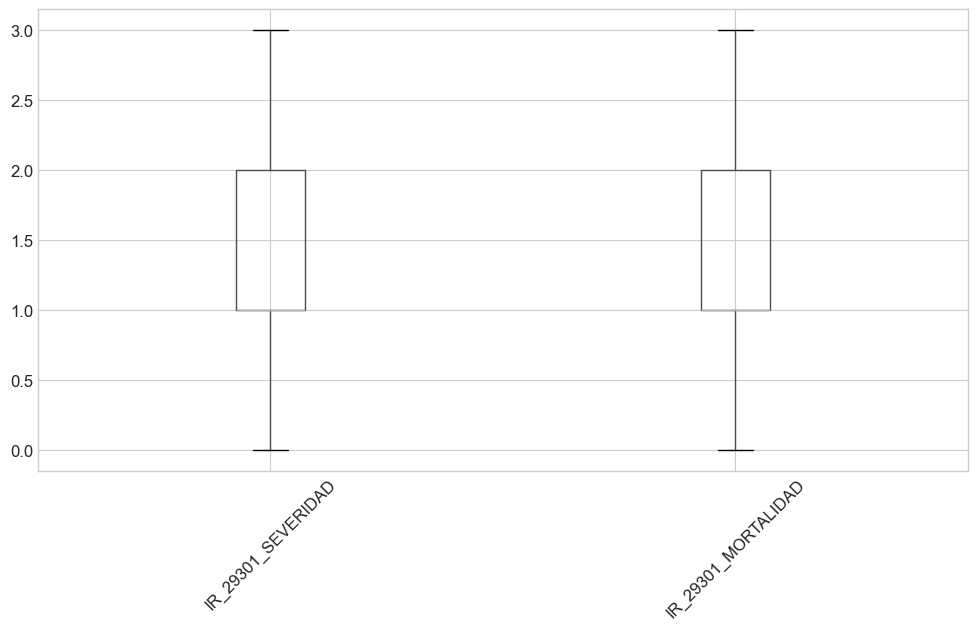

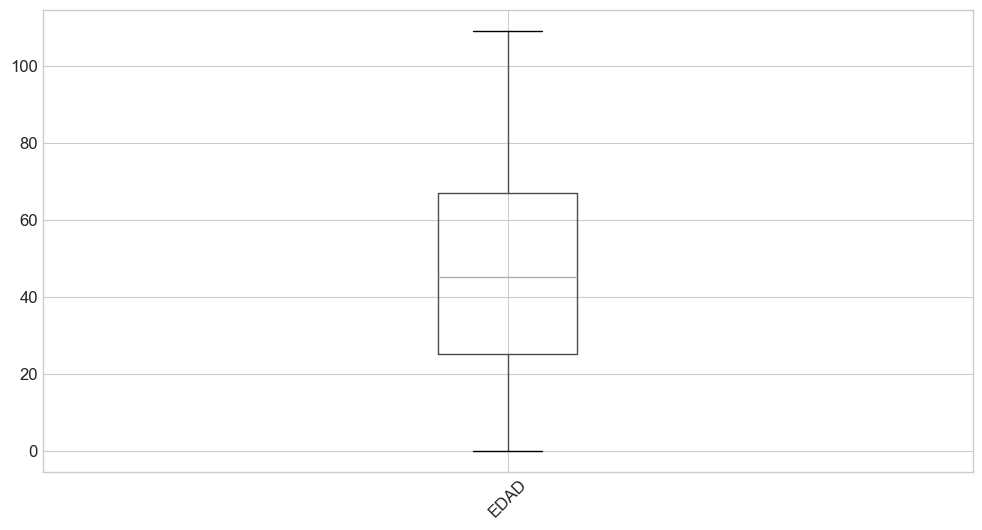

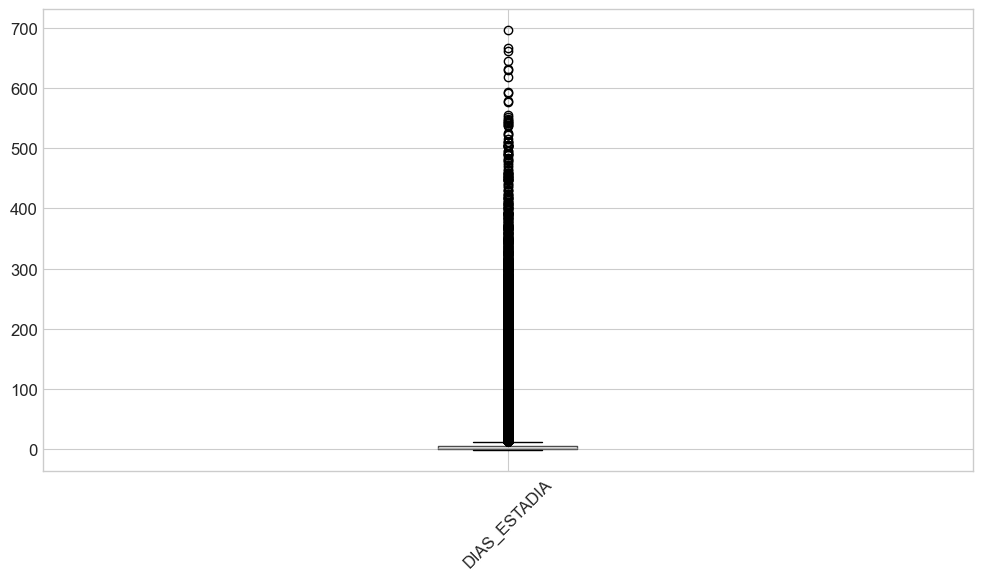

In [87]:
df.boxplot(column=["IR_29301_SEVERIDAD", "IR_29301_MORTALIDAD"], figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

df.boxplot(column=["EDAD"], figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

df.boxplot(column=["DIAS_ESTADIA"], figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

In [88]:
cols_numericas = ["IR_29301_SEVERIDAD", "IR_29301_MORTALIDAD", "EDAD", "DIAS_ESTADIA"]

Q1 = df[cols_numericas].quantile(0.25)
Q3 = df[cols_numericas].quantile(0.75)
IQR = Q3 - Q1

outliers = (
    (df[cols_numericas] < (Q1 - 1.5 * IQR)) |
    (df[cols_numericas] > (Q3 + 1.5 * IQR))
)

# por columna
print(outliers.sum())

# filas afectadas
print("Filas con outliers:", outliers.any(axis=1).sum())

IR_29301_SEVERIDAD          0
IR_29301_MORTALIDAD         0
EDAD                        0
DIAS_ESTADIA           311815
dtype: Int64
Filas con outliers: 311815


In [89]:
df['PREVISION']

0          FONASA INSTITUCIONAL - (MAI) C
1          FONASA INSTITUCIONAL - (MAI) A
2          FONASA INSTITUCIONAL - (MAI) B
3          FONASA INSTITUCIONAL - (MAI) A
4          FONASA INSTITUCIONAL - (MAI) B
                        ...              
3058234    FONASA INSTITUCIONAL - (MAI) B
3058235    FONASA INSTITUCIONAL - (MAI) B
3058236    FONASA INSTITUCIONAL - (MAI) D
3058237    FONASA INSTITUCIONAL - (MAI) C
3058238    FONASA INSTITUCIONAL - (MAI) B
Name: PREVISION, Length: 3045589, dtype: string

### Gráficos EDA

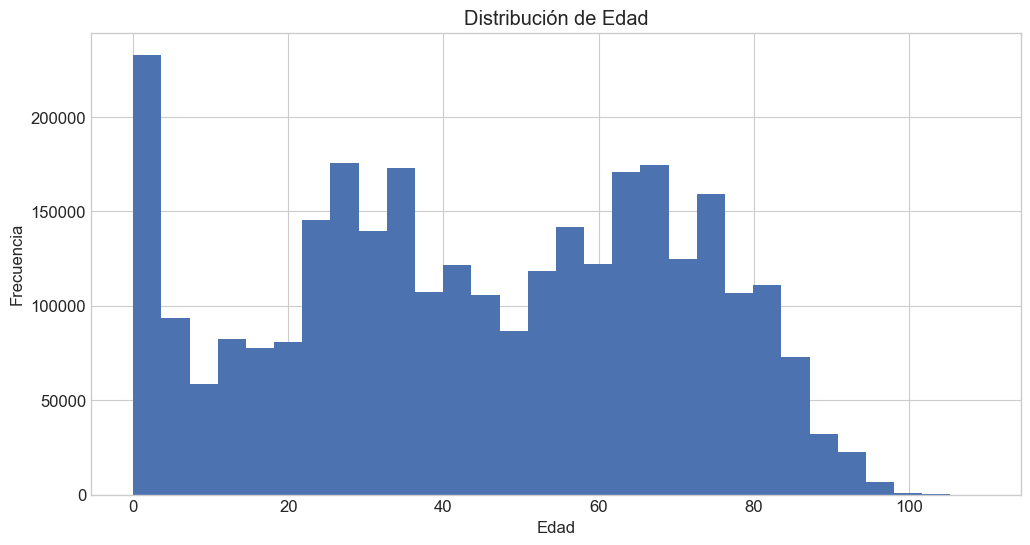

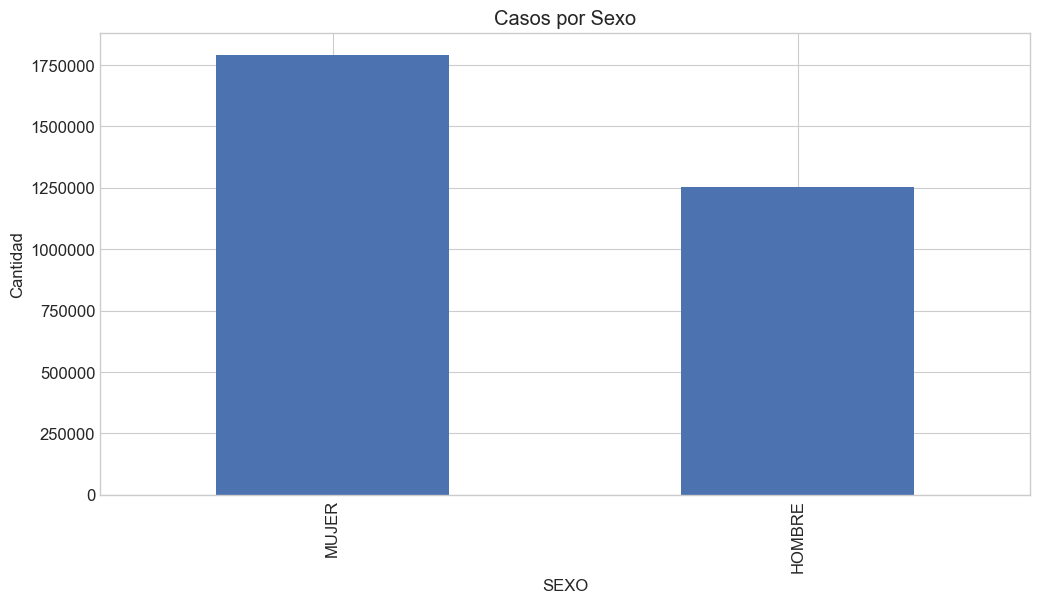

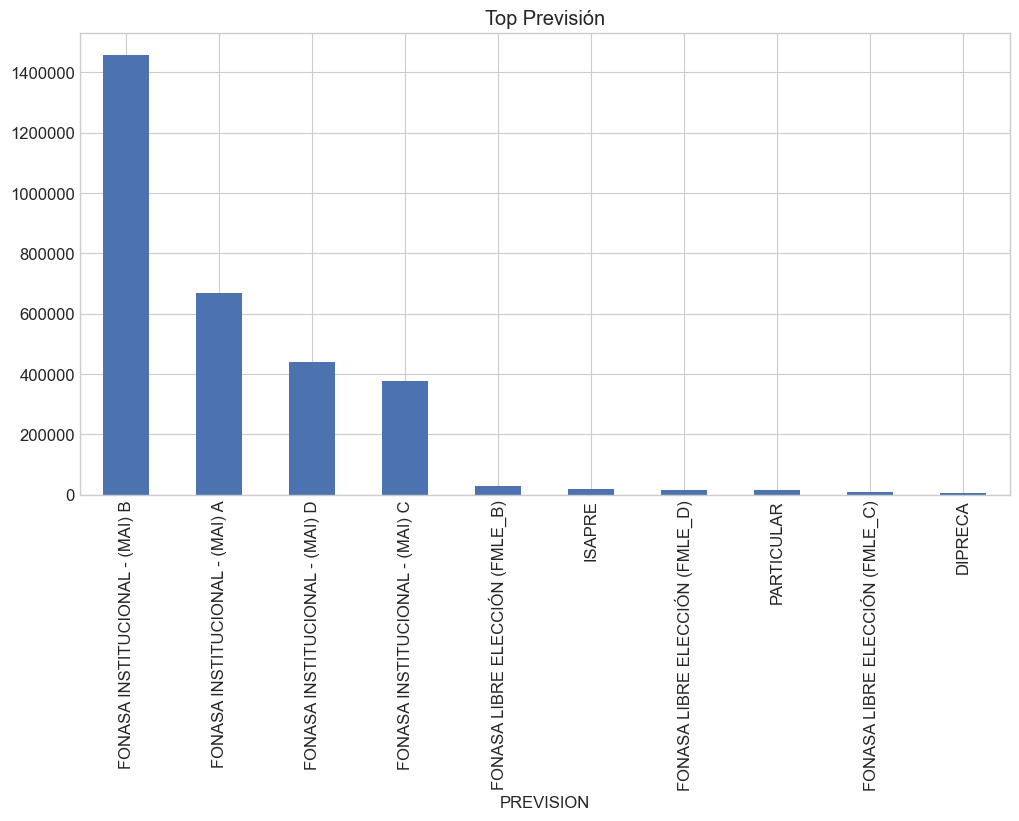

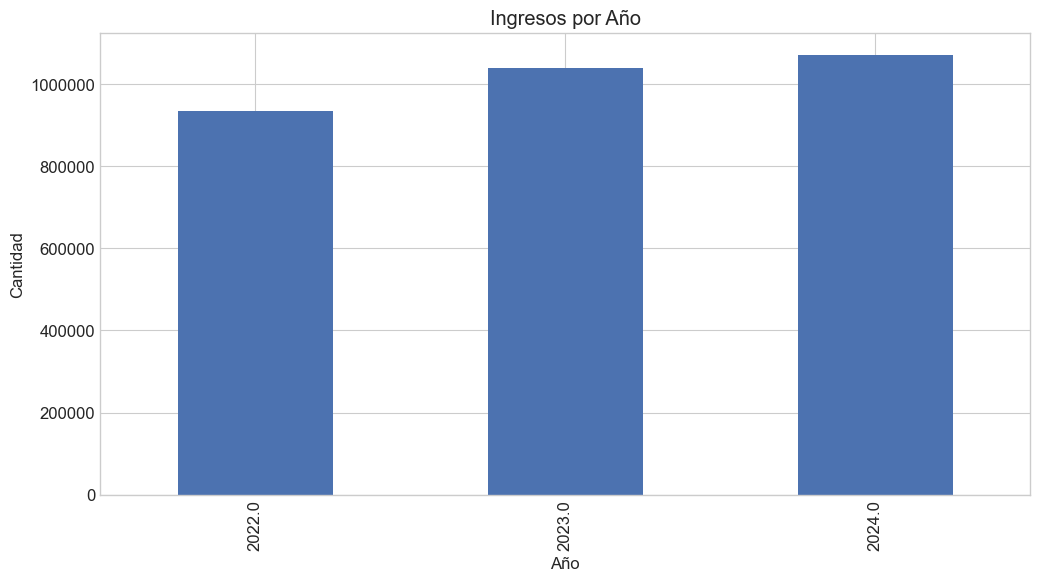

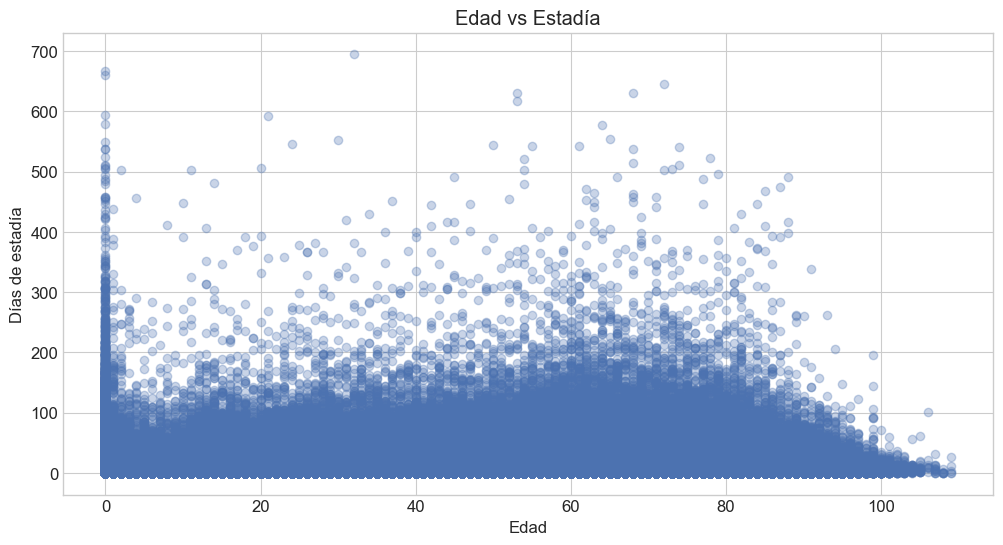

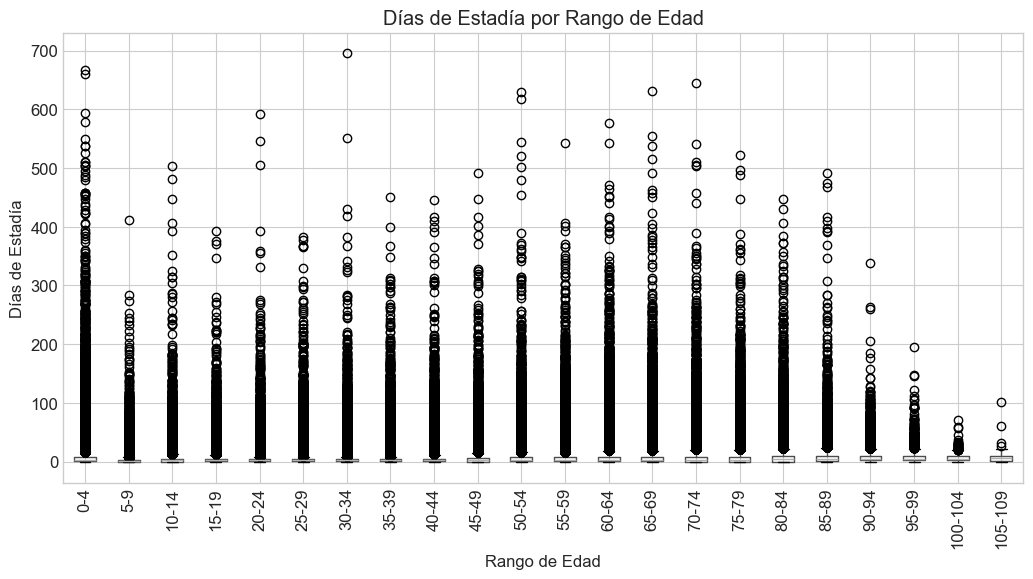

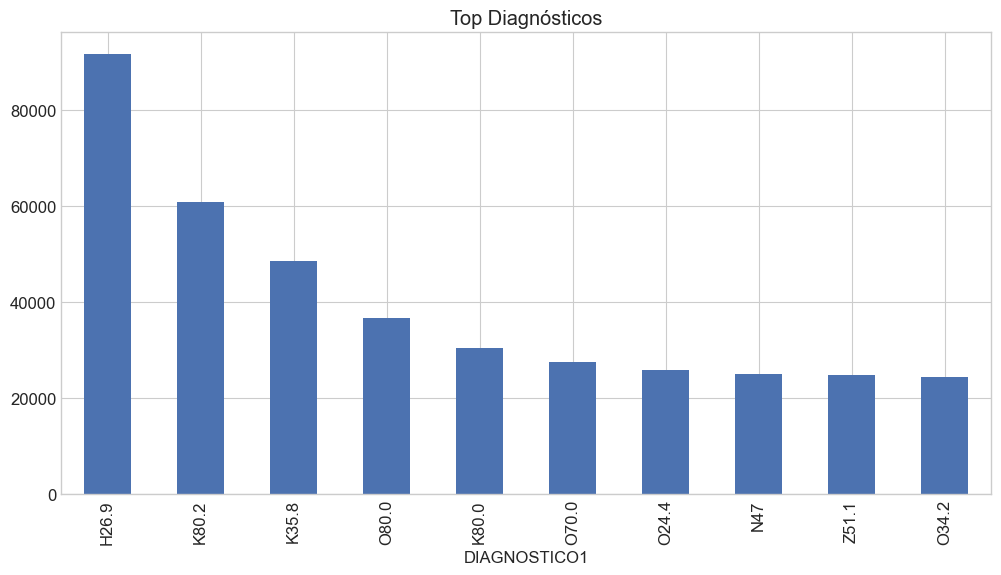

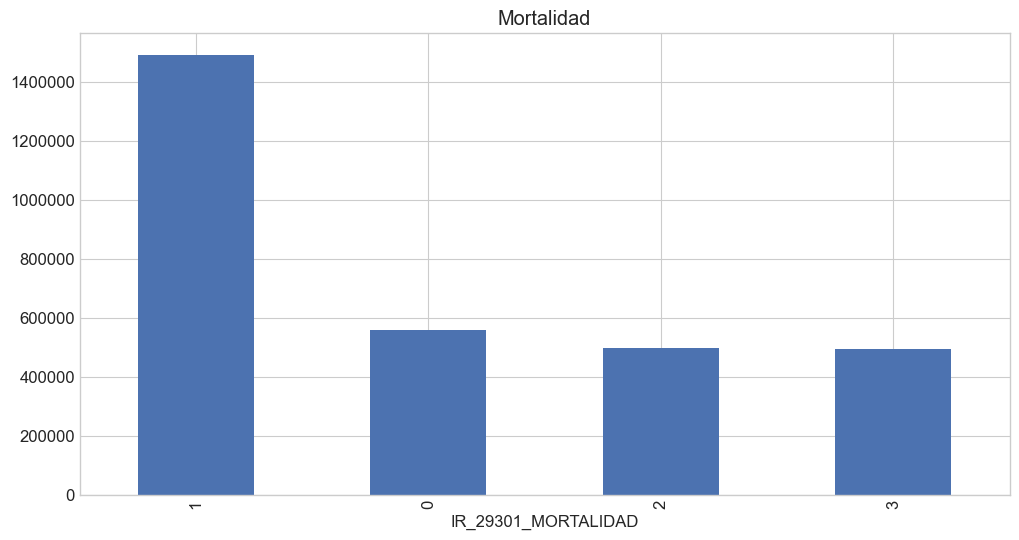

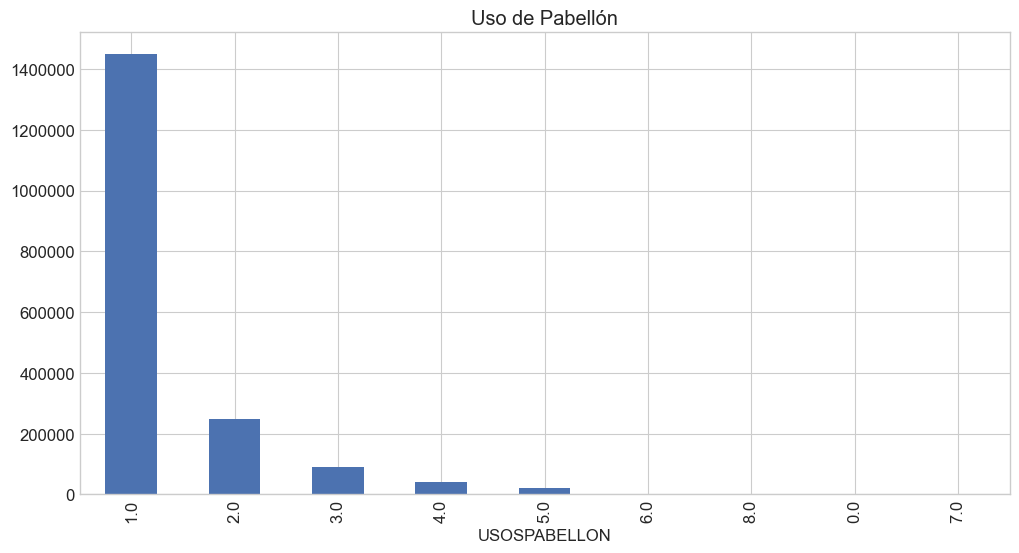

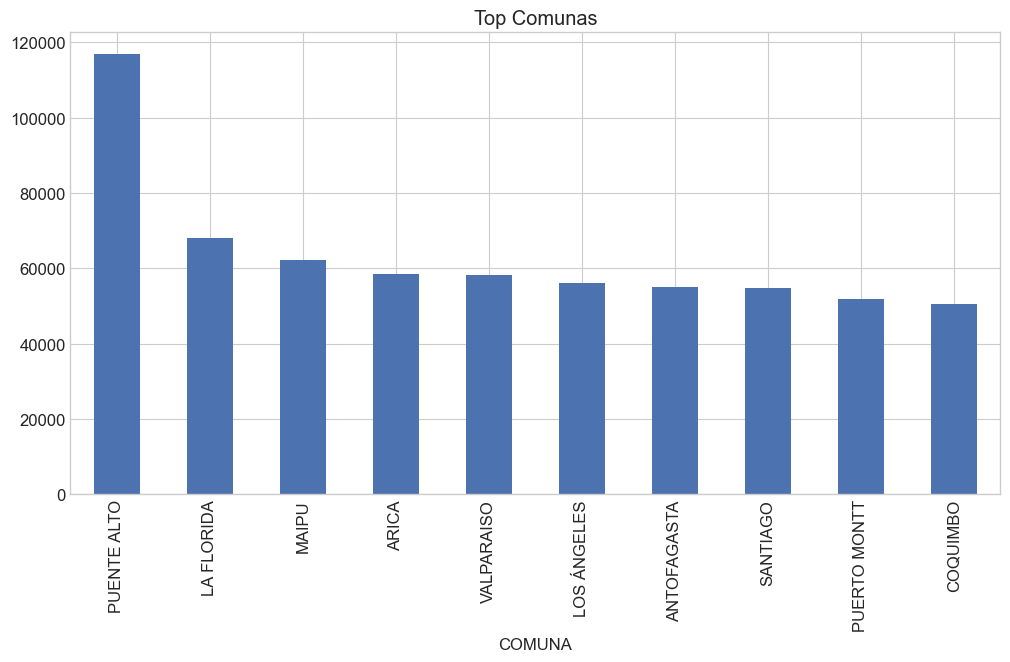

In [90]:
# Distribución de Edad
plt.figure()
df["EDAD"].hist(bins=30)
plt.title("Distribución de Edad")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

# Casos por Sexo
plt.figure()
df["SEXO"].value_counts().plot(kind="bar")
plt.title("Casos por Sexo")
plt.ticklabel_format(style='plain', axis='y')
plt.ylabel("Cantidad")
plt.show()

# Casos por Previsión
plt.figure()
df["PREVISION"].value_counts().head(10).plot(kind="bar")
plt.title("Top Previsión")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# Ingresos por Año
plt.figure()
df["AÑO"].value_counts().sort_index().plot(kind="bar")
plt.title("Ingresos por Año")
plt.xlabel("Año")
plt.ylabel("Cantidad")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

# Edad vs estadía
plt.figure()
plt.scatter(df["EDAD"], df["DIAS_ESTADIA"], alpha=0.3)
plt.xlabel("Edad")
plt.ylabel("Días de estadía")
plt.title("Edad vs Estadía")
plt.show()

# Edad vs estadía Boxplot
bins = np.arange(0, 115, 5)  # 0,5,10,...,120
labels = [f"{i}-{i+4}" for i in bins[:-1]]
df["rango_edad"] = pd.cut(df["EDAD"], bins=bins, labels=labels, right=False)

df.boxplot(column="DIAS_ESTADIA", by="rango_edad", rot=90)
plt.title("Días de Estadía por Rango de Edad")
plt.suptitle("")  # elimina título automático feo
plt.xlabel("Rango de Edad")
plt.ylabel("Días de Estadía")
plt.show()

# Top diagnósticos
plt.figure()
df["DIAGNOSTICO1"].value_counts().head(10).plot(kind="bar")
plt.title("Top Diagnósticos")
plt.show()

# Mortalidad
if "IR_29301_MORTALIDAD" in df.columns:
    plt.figure()
    df["IR_29301_MORTALIDAD"].value_counts().plot(kind="bar")
    plt.title("Mortalidad")
    plt.ticklabel_format(style='plain', axis='y')
    plt.show()

# Uso de pabellón
if "USOSPABELLON" in df.columns:
    plt.figure()
    df["USOSPABELLON"].value_counts().plot(kind="bar")
    plt.title("Uso de Pabellón")
    plt.ticklabel_format(style='plain', axis='y')
    plt.show()

# Top comunas
plt.figure()
df["COMUNA"].value_counts().head(10).plot(kind="bar")
plt.title("Top Comunas")
plt.show()

---
## 3. Índice de Comorbilidad de Charlson (CCI)

El **Índice de Comorbilidad de Charlson (CCI)** es un sistema de puntuación validado internacionalmente que cuantifica la carga de enfermedades crónicas de un paciente. Cada condición tiene un peso (1 a 6 puntos) según su impacto esperado en la mortalidad a 10 años. La suma de estos pesos constituye el score final del paciente.

Utilizamos este índice porque:
- La literatura clínica (Charlson et al., 1987; Quan et al., 2011) lo valida como predictor robusto de mortalidad intrahospitalaria.
- Nuestra hipótesis plantea que las **comorbilidades** son predictores primarios — el CCI permite cuantificar exactamente esa carga.
- Los códigos ICD-10 presentes en las columnas `DIAGNOSTICO1`–`DIAGNOSTICO9` del dataset GRD permiten mapear directamente las condiciones.

### Categorías del CCI
| Score | Interpretación |
|-------|----------------|
| 0 | Sin comorbilidades relevantes |
| 1–2 | Comorbilidad leve |
| 3–4 | Comorbilidad moderada |
| ≥ 5 | Comorbilidad severa |

### 3.1 Mapeo ICD-10 → Categorías Charlson

In [91]:
# ============================================================
# ÍNDICE DE COMORBILIDAD DE CHARLSON — IMPLEMENTACIÓN PROPIA
# Referencia: Quan et al. (2011) Med Care, 49(6), 612–617.
#             Charlson et al. (1987) J Chronic Dis, 40(5), 373–383.
# ============================================================

# Mapeamos prefijos ICD-10 (3 caracteres) a la categoría Charlson.
# Cada categoría tiene un peso según el modelo original de Charlson
# actualizado por Quan et al. (2011).

CHARLSON_ICD10 = {
    # ── Peso 1 ──────────────────────────────────────────────
    # Infarto agudo de miocardio
    'I21': ('MI', 1), 'I22': ('MI', 1), 'I25': ('MI', 1),
    # Insuficiencia cardíaca congestiva
    'I50': ('CHF', 1),
    # Enfermedad vascular periférica
    'I70': ('PVD', 1), 'I71': ('PVD', 1), 'I73': ('PVD', 1),
    'I77': ('PVD', 1), 'I79': ('PVD', 1),
    # Enfermedad cerebrovascular
    'G45': ('CVD', 1), 'G46': ('CVD', 1),
    'I60': ('CVD', 1), 'I61': ('CVD', 1), 'I62': ('CVD', 1),
    'I63': ('CVD', 1), 'I64': ('CVD', 1), 'I65': ('CVD', 1),
    'I66': ('CVD', 1), 'I67': ('CVD', 1), 'I68': ('CVD', 1),
    'I69': ('CVD', 1),
    # Demencia
    'F00': ('DEM', 1), 'F01': ('DEM', 1), 'F02': ('DEM', 1),
    'F03': ('DEM', 1), 'G30': ('DEM', 1), 'G31': ('DEM', 1),
    # Enfermedad pulmonar crónica (EPOC)
    'J40': ('COPD', 1), 'J41': ('COPD', 1), 'J42': ('COPD', 1),
    'J43': ('COPD', 1), 'J44': ('COPD', 1), 'J45': ('COPD', 1),
    'J46': ('COPD', 1), 'J47': ('COPD', 1), 'J60': ('COPD', 1),
    'J61': ('COPD', 1), 'J62': ('COPD', 1), 'J63': ('COPD', 1),
    'J64': ('COPD', 1), 'J65': ('COPD', 1), 'J66': ('COPD', 1),
    'J67': ('COPD', 1),
    # Enfermedad del tejido conectivo
    'M05': ('RHD', 1), 'M06': ('RHD', 1), 'M32': ('RHD', 1),
    'M33': ('RHD', 1), 'M34': ('RHD', 1), 'M35': ('RHD', 1),
    # Úlcera péptica
    'K25': ('PUD', 1), 'K26': ('PUD', 1), 'K27': ('PUD', 1),
    'K28': ('PUD', 1),
    # Enfermedad hepática leve
    'B18': ('MLD', 1), 'K70': ('MLD', 1), 'K71': ('MLD', 1),
    'K73': ('MLD', 1), 'K74': ('MLD', 1), 'K76': ('MLD', 1),
    # Diabetes sin complicación
    'E10': ('DM', 1), 'E11': ('DM', 1), 'E12': ('DM', 1),
    'E13': ('DM', 1), 'E14': ('DM', 1),

    # ── Peso 2 ──────────────────────────────────────────────
    # Hemiplejia
    'G04': ('HEMI', 2), 'G81': ('HEMI', 2), 'G82': ('HEMI', 2),
    'G83': ('HEMI', 2),
    # Enfermedad renal moderada/severa
    'N03': ('REN', 2), 'N05': ('REN', 2), 'N18': ('REN', 2),
    'N19': ('REN', 2), 'N25': ('REN', 2),
    # Diabetes con complicación crónica
    'E102': ('DMC', 2), 'E112': ('DMC', 2), 'E122': ('DMC', 2),
    'E132': ('DMC', 2), 'E142': ('DMC', 2),
    # Tumor sólido sin metástasis
    'C00': ('TUM', 2), 'C01': ('TUM', 2), 'C02': ('TUM', 2),
    'C03': ('TUM', 2), 'C04': ('TUM', 2), 'C05': ('TUM', 2),
    'C06': ('TUM', 2), 'C07': ('TUM', 2), 'C08': ('TUM', 2),
    'C09': ('TUM', 2), 'C10': ('TUM', 2), 'C11': ('TUM', 2),
    'C12': ('TUM', 2), 'C13': ('TUM', 2), 'C14': ('TUM', 2),
    'C15': ('TUM', 2), 'C16': ('TUM', 2), 'C17': ('TUM', 2),
    'C18': ('TUM', 2), 'C19': ('TUM', 2), 'C20': ('TUM', 2),
    'C21': ('TUM', 2), 'C22': ('TUM', 2), 'C23': ('TUM', 2),
    'C24': ('TUM', 2), 'C25': ('TUM', 2), 'C26': ('TUM', 2),
    'C30': ('TUM', 2), 'C31': ('TUM', 2), 'C32': ('TUM', 2),
    'C33': ('TUM', 2), 'C34': ('TUM', 2), 'C37': ('TUM', 2),
    'C38': ('TUM', 2), 'C39': ('TUM', 2), 'C40': ('TUM', 2),
    'C41': ('TUM', 2), 'C43': ('TUM', 2), 'C45': ('TUM', 2),
    'C46': ('TUM', 2), 'C47': ('TUM', 2), 'C48': ('TUM', 2),
    'C49': ('TUM', 2), 'C50': ('TUM', 2), 'C51': ('TUM', 2),
    'C52': ('TUM', 2), 'C53': ('TUM', 2), 'C54': ('TUM', 2),
    'C55': ('TUM', 2), 'C56': ('TUM', 2), 'C57': ('TUM', 2),
    'C58': ('TUM', 2), 'C60': ('TUM', 2), 'C61': ('TUM', 2),
    'C62': ('TUM', 2), 'C63': ('TUM', 2), 'C64': ('TUM', 2),
    'C65': ('TUM', 2), 'C66': ('TUM', 2), 'C67': ('TUM', 2),
    'C68': ('TUM', 2), 'C69': ('TUM', 2), 'C70': ('TUM', 2),
    'C71': ('TUM', 2), 'C72': ('TUM', 2), 'C73': ('TUM', 2),
    'C74': ('TUM', 2), 'C75': ('TUM', 2), 'C76': ('TUM', 2),
    'C97': ('TUM', 2),
    # Leucemia
    'C91': ('LEU', 2), 'C92': ('LEU', 2), 'C93': ('LEU', 2),
    'C94': ('LEU', 2), 'C95': ('LEU', 2),
    # Linfoma
    'C81': ('LYM', 2), 'C82': ('LYM', 2), 'C83': ('LYM', 2),
    'C84': ('LYM', 2), 'C85': ('LYM', 2), 'C88': ('LYM', 2),
    'C90': ('LYM', 2),

    # ── Peso 3 ──────────────────────────────────────────────
    # Enfermedad hepática moderada/severa
    'K70': ('MSLD', 3), 'K72': ('MSLD', 3), 'K76': ('MSLD', 3),

    # ── Peso 6 ──────────────────────────────────────────────
    # Tumor sólido con metástasis
    'C77': ('METS', 6), 'C78': ('METS', 6),
    'C79': ('METS', 6), 'C80': ('METS', 6),
    # VIH / SIDA
    'B20': ('AIDS', 6), 'B21': ('AIDS', 6),
    'B22': ('AIDS', 6), 'B24': ('AIDS', 6),
}

print(f"✅ Mapa Charlson cargado: {len(CHARLSON_ICD10)} prefijos ICD-10 mapeados")
print(f"   Categorías únicas: {len(set(v[0] for v in CHARLSON_ICD10.values()))}")

✅ Mapa Charlson cargado: 169 prefijos ICD-10 mapeados
   Categorías únicas: 19


### 3.2 Función de cálculo del CCI por paciente

In [92]:
def match_charlson(codigo: str) -> tuple | None:
    """
    Recibe un código ICD-10 (ej: 'I5000', 'J44', 'C34X').
    Devuelve (categoria, peso) si hay match, o None si no aplica.
    
    Estrategia: probar prefijos de longitud 5, 4 y 3 en orden.
    Esto permite capturar tanto los códigos de 5 dígitos (diabetes
    con complicación, ej 'E102') como los genéricos de 3 dígitos.
    """
    if not isinstance(codigo, str):
        return None
    # Normalizar: mayúsculas, sin espacios, sin guiones
    cod = codigo.upper().strip().replace('-', '').replace(' ', '')
    # Intentar match por prefijo decreciente (5 → 4 → 3 chars)
    for length in (5, 4, 3):
        prefijo = cod[:length]
        if prefijo in CHARLSON_ICD10:
            return CHARLSON_ICD10[prefijo]
    return None


# Columnas de diagnóstico disponibles en el dataset
COLS_DIAGNOSTICO = [f'DIAGNOSTICO{i}' for i in range(1, 10)]


def calcular_cci(fila: pd.Series, cols_dx: list[str]) -> int:
    """
    Calcula el Índice de Comorbilidad de Charlson para una fila del dataframe.
    
    Parámetros
    ----------
    fila     : pd.Series — una fila del dataframe
    cols_dx  : list[str] — nombres de columnas de diagnóstico ICD-10
    
    Retorna
    -------
    int — score CCI (0 = sin comorbilidades)
    
    Nota: cada categoría Charlson se cuenta UNA sola vez, aunque el
    paciente tenga múltiples diagnósticos que caigan en la misma.
    """
    categorias_presentes = {}  # {categoria: peso}
    
    for col in cols_dx:
        codigo = fila.get(col)
        resultado = match_charlson(codigo)
        if resultado is not None:
            categoria, peso = resultado
            # Guardar el peso más alto si hay categorías duplicadas
            if categoria not in categorias_presentes:
                categorias_presentes[categoria] = peso
            else:
                categorias_presentes[categoria] = max(
                    categorias_presentes[categoria], peso
                )
    
    return sum(categorias_presentes.values())


print("✅ Funciones match_charlson() y calcular_cci() definidas")

# Test unitario rápido
test_cases = [
    ('I50', 'CHF', 1),
    ('J440', 'COPD', 1),
    ('C34',  'TUM', 2),
    ('C79',  'METS', 6),
    ('B20',  'AIDS', 6),
    ('XYZ',  None, None),
]
print("\nTest unitario match_charlson():")
all_ok = True
for cod, cat_esperada, peso_esperado in test_cases:
    result = match_charlson(cod)
    if cat_esperada is None:
        ok = result is None
    else:
        ok = result is not None and result[0] == cat_esperada and result[1] == peso_esperado
    status = '✅' if ok else '❌'
    if not ok:
        all_ok = False
    print(f"  {status} '{cod}' → esperado ({cat_esperada}, {peso_esperado}), obtenido {result}")
print("\nTodos los tests OK" if all_ok else "\n⚠️ Revisar tests fallidos")

✅ Funciones match_charlson() y calcular_cci() definidas

Test unitario match_charlson():
  ✅ 'I50' → esperado (CHF, 1), obtenido ('CHF', 1)
  ✅ 'J440' → esperado (COPD, 1), obtenido ('COPD', 1)
  ✅ 'C34' → esperado (TUM, 2), obtenido ('TUM', 2)
  ✅ 'C79' → esperado (METS, 6), obtenido ('METS', 6)
  ✅ 'B20' → esperado (AIDS, 6), obtenido ('AIDS', 6)
  ✅ 'XYZ' → esperado (None, None), obtenido None

Todos los tests OK


### 3.3 Aplicación al dataset: columna `CCI`

Aplicamos `calcular_cci()` a cada fila del dataframe usando `.apply()`. El resultado se guarda en la nueva columna `CCI`.

> **Nota de rendimiento**: con datasets grandes (~millones de filas), `.apply()` fila a fila puede ser lento. Si el tiempo de cómputo es crítico, el siguiente enfoque vectorizado por columna de diagnóstico es notablemente más rápido — está incluido como alternativa comentada al final de la celda.

In [93]:
# ── Verificar que las columnas de diagnóstico existen en df ──────────────
cols_disponibles = [c for c in COLS_DIAGNOSTICO if c in df.columns]
cols_faltantes   = [c for c in COLS_DIAGNOSTICO if c not in df.columns]

if cols_faltantes:
    print(f"⚠️  Columnas no encontradas (se ignorarán): {cols_faltantes}")
print(f"✅ Columnas de diagnóstico disponibles: {cols_disponibles}")

# ── Calcular CCI ─────────────────────────────────────────────────────────
print("\nCalculando CCI...")
df['CCI'] = df.apply(
    calcular_cci,
    cols_dx=cols_disponibles,
    axis=1
)
print(f"✅ Columna 'CCI' creada. Shape: {df.shape}")

# ── Alternativa vectorizada (más rápida para datasets muy grandes) ────────
# Descomentar si .apply() es demasiado lento:
#
# peso_map = {cod: peso for cod, (_, peso) in CHARLSON_ICD10.items()}
#
# def puntaje_col(series: pd.Series) -> pd.Series:
#     prefijo3 = series.str.upper().str[:3].fillna('')
#     return prefijo3.map(peso_map).fillna(0).astype(int)
#
# cci_matrix = pd.concat(
#     [puntaje_col(df[c]) for c in cols_disponibles], axis=1
# )
# df['CCI'] = cci_matrix.max(axis=1)  # o .sum() según enfoque

✅ Columnas de diagnóstico disponibles: ['DIAGNOSTICO1', 'DIAGNOSTICO2', 'DIAGNOSTICO3', 'DIAGNOSTICO4', 'DIAGNOSTICO5', 'DIAGNOSTICO6', 'DIAGNOSTICO7', 'DIAGNOSTICO8', 'DIAGNOSTICO9']

Calculando CCI...
✅ Columna 'CCI' creada. Shape: (3045589, 38)


### 3.4 Distribución del CCI y categorización

In [94]:
# ── Crear variable categórica ─────────────────────────────────────────────
bins   = [-1, 0, 2, 4, 100]
labels = ['Sin comorbilidades (0)',
          'Leve (1–2)',
          'Moderada (3–4)',
          'Severa (≥5)']

df['CCI_CAT'] = pd.cut(df['CCI'], bins=bins, labels=labels)

# ── Estadísticas descriptivas ─────────────────────────────────────────────
print("=== Estadísticas del CCI ===")
print(df['CCI'].describe().round(3))

print("\n=== Distribución por categoría ===")
dist = df['CCI_CAT'].value_counts().sort_index()
print(dist)
print(f"\nPorcentajes:")
print((dist / len(df) * 100).round(2))

=== Estadísticas del CCI ===
count    3045589.000
mean           0.907
std            1.606
min            0.000
25%            0.000
50%            0.000
75%            1.000
max           18.000
Name: CCI, dtype: float64

=== Distribución por categoría ===
CCI_CAT
Sin comorbilidades (0)    1871876
Leve (1–2)                 803338
Moderada (3–4)             261945
Severa (≥5)                108430
Name: count, dtype: int64

Porcentajes:
CCI_CAT
Sin comorbilidades (0)    61.46
Leve (1–2)                26.38
Moderada (3–4)             8.60
Severa (≥5)                3.56
Name: count, dtype: float64


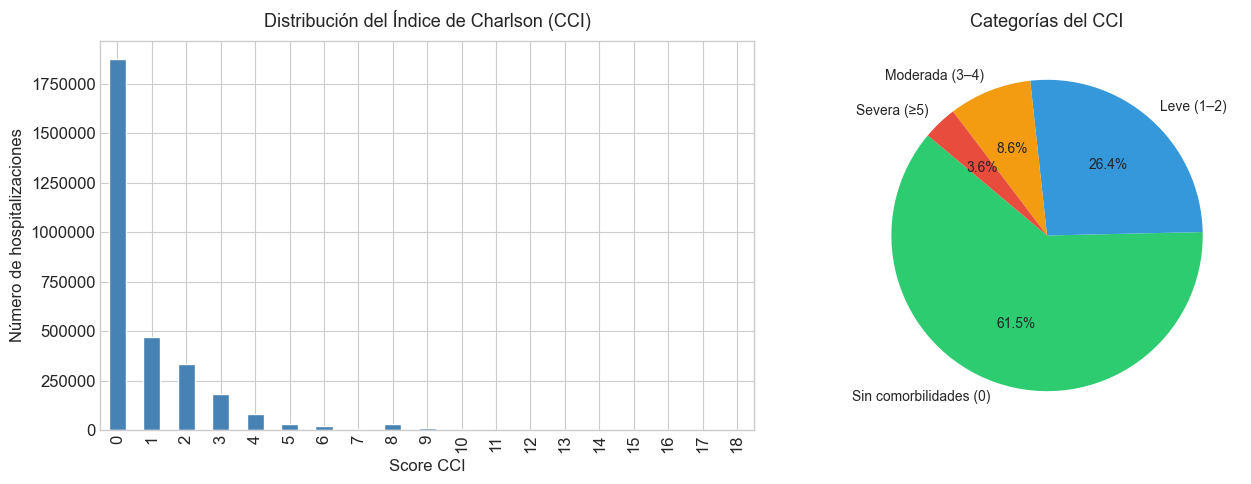

In [95]:
# ── Visualización: distribución del CCI ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de scores
ax1 = axes[0]
df['CCI'].value_counts().sort_index().plot(
    kind='bar', ax=ax1, color='steelblue', edgecolor='white'
)
ax1.set_title('Distribución del Índice de Charlson (CCI)', fontsize=13, pad=10)
ax1.set_xlabel('Score CCI')
ax1.set_ylabel('Número de hospitalizaciones')
ax1.ticklabel_format(style='plain', axis='y')

# Pie por categoría
ax2 = axes[1]
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
df['CCI_CAT'].value_counts().sort_index().plot(
    kind='pie', ax=ax2, autopct='%1.1f%%',
    colors=colors, startangle=140,
    textprops={'fontsize': 10}
)
ax2.set_title('Categorías del CCI', fontsize=13, pad=10)
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

### 3.5 CCI vs Mortalidad intrahospitalaria

Exploramos si existe una relación visible entre la carga de comorbilidades (CCI) y la mortalidad durante la hospitalización (`TIPOALTA`). Esto constituye el análisis exploratorio central de nuestra pregunta de investigación.

In [96]:
# ── Crear variable binaria de mortalidad ─────────────────────────────────
# TIPOALTA = '2' corresponde a fallecimiento en la mayoría de codificaciones GRD
# Ajustar el valor si el dataset usa otra codificación
df['FALLECIDO'] = df['TIPOALTA'].astype(str).str.strip().isin(['FALLECIDO'])

print(f"Registros con fallecimiento: {df['FALLECIDO'].sum():,}")
print(f"Tasa de mortalidad global: {df['FALLECIDO'].mean():.3%}")

# ── Tasa de mortalidad por categoría CCI ─────────────────────────────────
mortalidad_por_cci = (
    df.groupby('CCI_CAT', observed=True)['FALLECIDO']
      .agg(['sum', 'mean', 'count'])
      .rename(columns={'sum': 'Fallecidos', 'mean': 'Tasa', 'count': 'Total'})
)
mortalidad_por_cci['Tasa_%'] = (mortalidad_por_cci['Tasa'] * 100).round(2)

print("\n=== Mortalidad por categoría CCI ===")
print(mortalidad_por_cci[['Total', 'Fallecidos', 'Tasa_%']])

Registros con fallecimiento: 78,153
Tasa de mortalidad global: 2.566%

=== Mortalidad por categoría CCI ===
                          Total  Fallecidos  Tasa_%
CCI_CAT                                            
Sin comorbilidades (0)  1871876       15158    0.81
Leve (1–2)               803338       32464    4.04
Moderada (3–4)           261945       19230    7.34
Severa (≥5)              108430       11301   10.42


C:\Users\oscar\AppData\Local\Temp\ipykernel_6800\603913857.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(cats, rotation=15, ha='right')


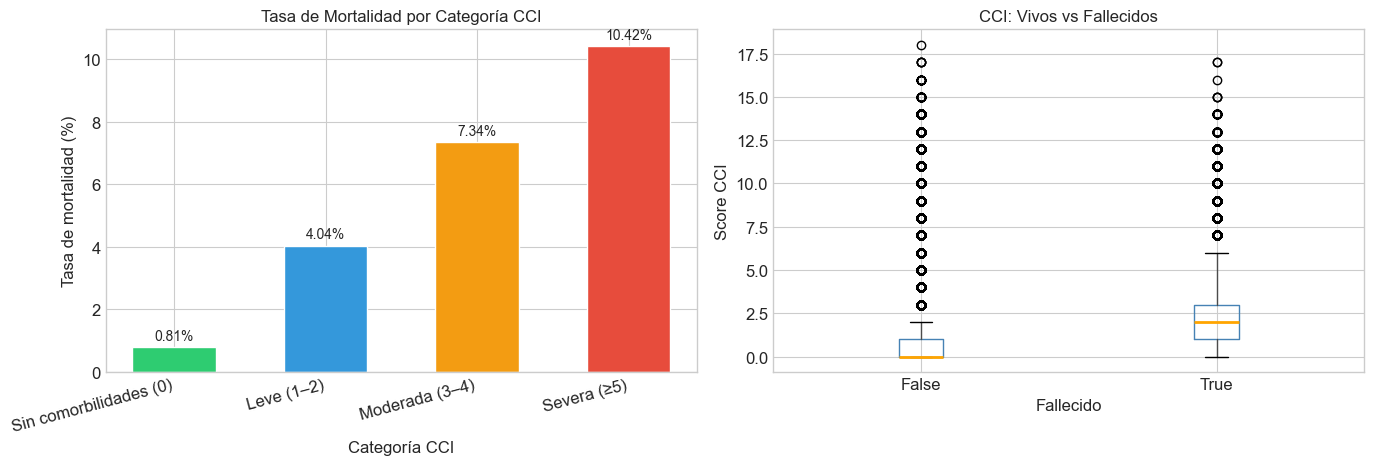

In [97]:
# ── Visualización: CCI vs mortalidad ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: tasa de mortalidad por categoría
ax1 = axes[0]
cats = mortalidad_por_cci.index.astype(str)
tasas = mortalidad_por_cci['Tasa_%']
bars = ax1.bar(cats, tasas, color=['#2ecc71','#3498db','#f39c12','#e74c3c'],
               edgecolor='white', width=0.55)
ax1.bar_label(bars, fmt='%.2f%%', padding=3, fontsize=10)
ax1.set_title('Tasa de Mortalidad por Categoría CCI', fontsize=12)
ax1.set_xlabel('Categoría CCI')
ax1.set_ylabel('Tasa de mortalidad (%)')
ax1.set_xticklabels(cats, rotation=15, ha='right')

# Gráfico 2: boxplot CCI (vivos vs fallecidos)
ax2 = axes[1]
df.boxplot(
    column='CCI', by='FALLECIDO', ax=ax2,
    boxprops=dict(color='steelblue'),
    medianprops=dict(color='orange', linewidth=2)
)
ax2.set_title('CCI: Vivos vs Fallecidos', fontsize=12)
ax2.set_xlabel('Fallecido')
ax2.set_ylabel('Score CCI')
plt.suptitle('')  # elimina el título automático de boxplot

plt.tight_layout()
plt.show()

### 3.6 Estimación estadística: CCI como predictor

Calculamos estimadores puntuales del CCI separando pacientes fallecidos de los no fallecidos, y construimos intervalos de confianza al 95% para la media del CCI en cada grupo.

In [98]:
from scipy import stats as scipy_stats

# ── Estimadores por grupo ─────────────────────────────────────────────────
grupos = {
    'Vivos':     df[df['FALLECIDO'] == False]['CCI'].dropna(),
    'Fallecidos': df[df['FALLECIDO'] == True]['CCI'].dropna(),
}

print(f"{'Grupo':<14} {'n':>8} {'Media':>8} {'Mediana':>9} {'Std':>8} {'IC95% inf':>11} {'IC95% sup':>11}")
print("-" * 75)

for nombre, serie in grupos.items():
    n     = len(serie)
    media = serie.mean()
    med   = serie.median()
    std   = serie.std()
    sem   = scipy_stats.sem(serie)
    ci    = scipy_stats.t.interval(0.95, df=n-1, loc=media, scale=sem)
    print(f"{nombre:<14} {n:>8,} {media:>8.3f} {med:>9.1f} {std:>8.3f} "
          f"{ci[0]:>11.3f} {ci[1]:>11.3f}")

# ── Prueba Mann-Whitney (distribución no normal esperada) ─────────────────
print("\n=== Prueba Mann-Whitney U (CCI: Vivos vs Fallecidos) ===")
stat, p_val = scipy_stats.mannwhitneyu(
    grupos['Vivos'], grupos['Fallecidos'], alternative='less'
)
print(f"Estadístico U = {stat:.2f}")
print(f"p-valor       = {p_val:.4e}")
if p_val < 0.05:
    print("→ Diferencia estadísticamente significativa (α=0.05)")
    print("→ Los pacientes fallecidos tienen un CCI mayor en promedio.")
else:
    print("→ No se detecta diferencia significativa al nivel α=0.05")

Grupo                 n    Media   Mediana      Std   IC95% inf   IC95% sup
---------------------------------------------------------------------------
Vivos          2,967,436    0.866       0.0    1.559       0.864       0.868
Fallecidos       78,153    2.482       2.0    2.394       2.466       2.499

=== Prueba Mann-Whitney U (CCI: Vivos vs Fallecidos) ===
Estadístico U = 58270667863.00
p-valor       = 0.0000e+00
→ Diferencia estadísticamente significativa (α=0.05)
→ Los pacientes fallecidos tienen un CCI mayor en promedio.


---
## 3.7 Variables Derivadas: IC, IMHV, Sepsis y Abandono

Antes de aplicar cualquier prueba de hipotesis, construimos las variables
derivadas que usaremos a lo largo del analisis. Esta seccion las define
formalmente, explica la razon de cada decision de diseno, y verifica
que se hayan creado correctamente sobre el dataframe principal.

Las cuatro variables son:

| Variable | Tipo | Origen | Proposito en el analisis |
|----------|------|--------|--------------------------|
| `IC` | Binaria (0/1) | DIAGNOSTICO1-9 (I50.x) | Comorbilidad focal del proyecto |
| `IMHV` | Continua [0, 1] | 5 variables GRD ponderadas | Indice propio alternativo al CCI |
| `SEPSIS` | Binaria (0/1) | DIAGNOSTICO1-9 (A40.x, A41.x) | Segunda comorbilidad de alto impacto |
| `ABANDONO` | Binaria (0/1) | TIPOALTA (Alta voluntaria / Fuga) | Proxy de salida sin resolucion clinica |


### 3.7.1 Variable IC — Insuficiencia Cardiaca

**Que columnas se usan:** `DIAGNOSTICO1` hasta `DIAGNOSTICO9`.

**Logica:** un paciente tiene IC si al menos uno de sus diagnosticos
comienza con el prefijo `I50` (CIE-10). Se usa prefijo de 3 caracteres
porque el codigo puede tener subcategorias (I50.0, I50.1, I50.9, etc.)
y queremos capturar todas sin listar cada variante.

**Por que la IC como comorbilidad focal:**
- Es la comorbilidad cronica con mayor frecuencia de rehospitalizacion
  en la red publica chilena (fuente: DEIS 2022-2023).
- Su codigo ICD-10 es univoco y trazable en el dataset sin ambiguedades.
- Recibe peso 1 en la escala Charlson-Quan, siendo predictor independiente
  de mortalidad en multiples estudios internacionales.
- Permite aislar el efecto de una sola comorbilidad severa sobre la
  mortalidad, controlando por severidad clinica (IR_29301_SEVERIDAD)
  y vulnerabilidad demografica (PREVISION, EDAD).


In [99]:
# Variable IC: Insuficiencia Cardiaca (ICD-10: I50.x)
# ─────────────────────────────────────────────────────────────────────────────
# Buscamos el prefijo I50 en todas las columnas de diagnostico disponibles.
# Usamos str.upper() para normalizar mayusculas/minusculas y
# str.startswith para capturar todos los subcodigos I50.0 - I50.9.

cols_dx = [c for c in df.columns if c.startswith('DIAGNOSTICO')]

df['IC'] = df[cols_dx].apply(
    lambda row: any(
        str(v).upper().strip().startswith('I50')
        for v in row if pd.notna(v) and str(v).strip() != ''
    ),
    axis=1
).astype(int)

n_ic = df['IC'].sum()
pct_ic = df['IC'].mean()

print(f"Variable IC creada correctamente.")
print(f"  Columnas de diagnostico usadas : {cols_dx}")
print(f"  Pacientes con IC (I50.x)       : {n_ic:,}  ({pct_ic:.2%} del total)")
print(f"  Pacientes sin IC               : {len(df) - n_ic:,}")


Variable IC creada correctamente.
  Columnas de diagnostico usadas : ['DIAGNOSTICO1', 'DIAGNOSTICO2', 'DIAGNOSTICO3', 'DIAGNOSTICO4', 'DIAGNOSTICO5', 'DIAGNOSTICO6', 'DIAGNOSTICO7', 'DIAGNOSTICO8', 'DIAGNOSTICO9']
  Pacientes con IC (I50.x)       : 126,933  (4.17% del total)
  Pacientes sin IC               : 2,918,656


### 3.7.2 Variable IMHV — Indice de Mortalidad Hospitalaria por Vulnerabilidad

**Que columnas se usan:** `EDAD`, `PREVISION`, `TIPO_INGRESO`,
`DIAS_ESTADIA`, `USOSPABELLON`.

**Logica del indice:** el IMHV es un score aditivo propio del equipo
que captura dimensiones de vulnerabilidad que el CCI no contempla.
El CCI mide exclusivamente carga de comorbilidades cronicas; el IMHV
agrega factores socioeconomicos y de gestion hospitalaria.

**Justificacion de cada componente y su peso:**

| Componente | Condicion | Peso | Razon |
|---|---|---|---|
| EDAD | >= 70 anos | 0.25 | Mayor edad es el predictor demografico mas consistente de mortalidad hospitalaria en la literatura |
| PREVISION | FONASA A o B | 0.20 | Grupos de mayor vulnerabilidad socioeconomica, con menor acceso a atencion preventiva |
| TIPO_INGRESO | Urgencia | 0.20 | Ingreso no programado asociado a mayor severidad y menor preparacion clinica. La matriz de correlacion del dataset muestra que urgencia tiene la mayor correlacion individual con dias de estadia |
| DIAS_ESTADIA | > 10 dias | 0.20 | Estadias prolongadas reflejan complicaciones o infecciones nosocomiales |
| USOSPABELLON | >= 2 usos | 0.15 | Multiples intervenciones quirurgicas indican mayor complejidad clinica acumulada |

Los pesos suman 1.0. El score resultante es un numero entre 0 y 1 donde
valores altos indican mayor vulnerabilidad combinada.


In [100]:
# Variable IMHV: Indice de Mortalidad Hospitalaria por Vulnerabilidad
# ─────────────────────────────────────────────────────────────────────────────
# Score aditivo con pesos normalizados definidos por el equipo.
# Cada componente es una condicion binaria; se multiplica por su peso
# y se suman todos los componentes.

imhv = pd.Series(0.0, index=df.index)

# Componente 1: edad >= 70 (peso 0.25)
imhv += 0.25 * (df['EDAD'] >= 70).fillna(False).astype(float)

# Componente 2: FONASA A o B (peso 0.20)
# Normalizamos el texto de prevision para capturar variantes de escritura
prevision_norm = df['PREVISION'].astype(str).str.upper().str.strip()
imhv += 0.20 * prevision_norm.isin(['FONASA A', 'FONASA B', 'A', 'B']).astype(float)

# Componente 3: ingreso por urgencia (peso 0.20)
tipo_ingreso_norm = df['TIPO_INGRESO'].astype(str).str.upper().str.strip()
imhv += 0.20 * tipo_ingreso_norm.str.contains('URGENCIA', na=False).astype(float)

# Componente 4: estadia > 10 dias (peso 0.20)
imhv += 0.20 * (df['DIAS_ESTADIA'] > 10).fillna(False).astype(float)

# Componente 5: uso de pabellon >= 2 (peso 0.15)
imhv += 0.15 * (df['USOSPABELLON'].fillna(0) >= 2).astype(float)

df['IMHV'] = imhv

print(f"Variable IMHV creada correctamente.")
print(f"  Rango            : [{df['IMHV'].min():.2f}, {df['IMHV'].max():.2f}]")
print(f"  Media            : {df['IMHV'].mean():.4f}")
print(f"  Mediana          : {df['IMHV'].median():.4f}")
print(f"  Pacientes IMHV=0 : {(df['IMHV']==0).sum():,}  ({(df['IMHV']==0).mean():.2%}) — sin ningun factor de vulnerabilidad")
print(f"  Pacientes IMHV=1 : {(df['IMHV']==1).sum():,}  ({(df['IMHV']==1).mean():.2%}) — todos los factores presentes")

# Distribucion de componentes individuales
print()
print("Prevalencia de cada componente del IMHV:")
print(f"  Edad >= 70               : {(df['EDAD']>=70).mean():.2%}")
print(f"  FONASA A/B               : {prevision_norm.isin(['FONASA A','FONASA B','A','B']).mean():.2%}")
print(f"  Ingreso urgencia         : {tipo_ingreso_norm.str.contains('URGENCIA',na=False).mean():.2%}")
print(f"  Estadia > 10 dias        : {(df['DIAS_ESTADIA']>10).mean():.2%}")
print(f"  Pabellon >= 2 usos       : {(df['USOSPABELLON'].fillna(0)>=2).mean():.2%}")


Variable IMHV creada correctamente.
  Rango            : [0.00, 0.80]
  Media            : 0.2002
  Mediana          : 0.2000
  Pacientes IMHV=0 : 1,013,941  (33.29%) — sin ningun factor de vulnerabilidad
  Pacientes IMHV=1 : 0  (0.00%) — todos los factores presentes

Prevalencia de cada componente del IMHV:
  Edad >= 70               : 20.92%
  FONASA A/B               : 0.00%
  Ingreso urgencia         : 50.19%
  Estadia > 10 dias        : 13.88%
  Pabellon >= 2 usos       : 13.19%


### 3.7.3 Variable SEPSIS — Segunda comorbilidad focal

**Que columnas se usan:** `DIAGNOSTICO1` hasta `DIAGNOSTICO9`.

**Codigos ICD-10 incluidos:**
- `A40.x` — Septicemia estreptococica
- `A41.x` — Otras septicemias (incluyendo Sepsis por Staphylococcus,
  gram negativos, y sepsis no especificada)

**Por que Sepsis como segunda comorbilidad focal:**

La sepsis es la principal causa de muerte intrahospitalaria a nivel
mundial y en Chile especificamente. A diferencia de la IC (que es una
condicion cronica preexistente), la sepsis puede ser tanto una condicion
de ingreso como una complicacion adquirida durante la hospitalizacion.
Esto la convierte en un predictor de mortalidad con una naturaleza
diferente a la IC, lo que permite comparar dos mecanismos distintos:

- IC representa comorbilidad cronica acumulada (capturada por el CCI)
- Sepsis representa complicacion aguda o infecciosa severa

Ademas, la combinacion IC+Sepsis es un escenario clinico de altisimo
riesgo, y su prevalencia en el dataset GRD chileno es esperable dado
que la IC aumenta la susceptibilidad a infecciones.

**Fuente de validacion:** los datos de egresos hospitalarios del DEIS
(disponibles en https://deis.minsal.cl/#datosabiertos) para el periodo
2022-2023 permiten verificar la prevalencia de A40-A41 en la poblacion
hospitalizada chilena. Se carga una fraccion de ese dataset como
respaldo externo en la seccion de validacion.


In [101]:
# Variable SEPSIS: Sepsis bacteriana (ICD-10: A40.x y A41.x)
# ─────────────────────────────────────────────────────────────────────────────

df['SEPSIS'] = df[cols_dx].apply(
    lambda row: any(
        str(v).upper().strip().startswith(('A40', 'A41'))
        for v in row if pd.notna(v) and str(v).strip() != ''
    ),
    axis=1
).astype(int)

# Variable combinada: pacientes con ambas condiciones simultaneamente
df['IC_SEPSIS'] = ((df['IC'] == 1) & (df['SEPSIS'] == 1)).astype(int)

n_sep  = df['SEPSIS'].sum()
n_both = df['IC_SEPSIS'].sum()

print(f"Variable SEPSIS creada correctamente.")
print(f"  Pacientes con Sepsis (A40/A41) : {n_sep:,}  ({df['SEPSIS'].mean():.2%})")
print(f"  Pacientes con IC + Sepsis      : {n_both:,}  ({df['IC_SEPSIS'].mean():.2%})")
print()
print("Distribucion de grupos de comorbilidad:")
print(f"  Sin IC ni Sepsis               : {((df['IC']==0)&(df['SEPSIS']==0)).sum():,}")
print(f"  Solo IC                        : {((df['IC']==1)&(df['SEPSIS']==0)).sum():,}")
print(f"  Solo Sepsis                    : {((df['IC']==0)&(df['SEPSIS']==1)).sum():,}")
print(f"  IC + Sepsis (ambas)            : {n_both:,}")


Variable SEPSIS creada correctamente.
  Pacientes con Sepsis (A40/A41) : 44,085  (1.45%)
  Pacientes con IC + Sepsis      : 4,118  (0.14%)

Distribucion de grupos de comorbilidad:
  Sin IC ni Sepsis               : 2,878,689
  Solo IC                        : 122,815
  Solo Sepsis                    : 39,967
  IC + Sepsis (ambas)            : 4,118


### 3.7.4 Variable ABANDONO — Salida sin resolucion clinica

**Que columnas se usan:** `TIPOALTA`.

**Valores de TIPOALTA considerados abandono:**
- `ALTA VOLUNTARIA` — el paciente decide irse contra consejo medico
- `FUGA DEL PACIENTE` — el paciente abandona sin notificacion medica

**Valores excluidos del concepto de abandono:**
- `DERIVACION OTRO HOSPITAL DE LA RED NACIONAL` — salida coordinada
  por el sistema de salud, con continuidad de atencion garantizada
- `DERIVACION OTRO HOSPITAL DEL SERVICIO` — idem anterior
- Estos dos casos representan gestion clinica controlada, no abandono.
  Se excluyen porque incluirlos contaminaria la variable con salidas
  que tienen seguimiento medico posterior.

**Por que el abandono es relevante para la hipotesis del proyecto:**

Un paciente que abandona voluntariamente o se fuga presenta un perfil
clinico y demografico particular: puede tener alta carga de comorbilidades
(CCI alto), factores de vulnerabilidad elevados (IMHV alto), o por el
contrario puede irse porque percibe que no necesita atencion. Analizar
si el perfil de riesgo de los que abandonan es similar al de los que
fallecen permite entender si el abandono es un indicador de mortalidad
diferida — es decir, pacientes que mueren fuera del hospital tras una
salida prematura. Esto agrega una dimension nueva a la pregunta de
investigacion que el analisis de mortalidad intrahospitalaria directa
no puede capturar.


In [102]:
# Variable ABANDONO: alta voluntaria o fuga del paciente
# ─────────────────────────────────────────────────────────────────────────────

tipoalta_norm = df['TIPOALTA'].astype(str).str.upper().str.strip()

# Valores que constituyen abandono
valores_abandono = ['ALTA VOLUNTARIA', 'FUGA DEL PACIENTE', 'FUGA']

df['ABANDONO'] = tipoalta_norm.isin(valores_abandono).astype(int)

# Mostrar todos los valores unicos de TIPOALTA para transparencia
print("Valores unicos de TIPOALTA en el dataset:")
print(df['TIPOALTA'].value_counts().to_string())
print()
print(f"Variable ABANDONO creada correctamente.")
print(f"  Casos de abandono (Alta voluntaria + Fuga) : {df['ABANDONO'].sum():,}  ({df['ABANDONO'].mean():.2%})")
print()
print("Nota: DERIVACION OTRO HOSPITAL (RED / SERVICIO) excluida del abandono.")
print("Esas salidas tienen continuidad de atencion y no representan riesgo no resuelto.")


Valores unicos de TIPOALTA en el dataset:
TIPOALTA
DOMICILIO                                        2732748
HOSPITALIZACIÓN DOMICILIARIA                       88629
FALLECIDO                                          78153
DERIVACIÓN OTRO HOSPITAL DEL SERVICIO              61373
ALTA VOLUNTARIA                                    31544
DERIVACIÓN OTRO HOSPITAL DE LA RED NACIONAL        21689
DERIVACIÓN A OTROS CENTROS (CÁRCEL, HOGAR DE       10423
FUGA DEL PACIENTE                                   9673
DERIVACIÓN INST. PRIVADA (COMPRA DE SERVICIOS       8080
DERIVACIÓN INST. PRIVADA (VOLUNTARIO)               3277

Variable ABANDONO creada correctamente.
  Casos de abandono (Alta voluntaria + Fuga) : 41,217  (1.35%)

Nota: DERIVACION OTRO HOSPITAL (RED / SERVICIO) excluida del abandono.
Esas salidas tienen continuidad de atencion y no representan riesgo no resuelto.


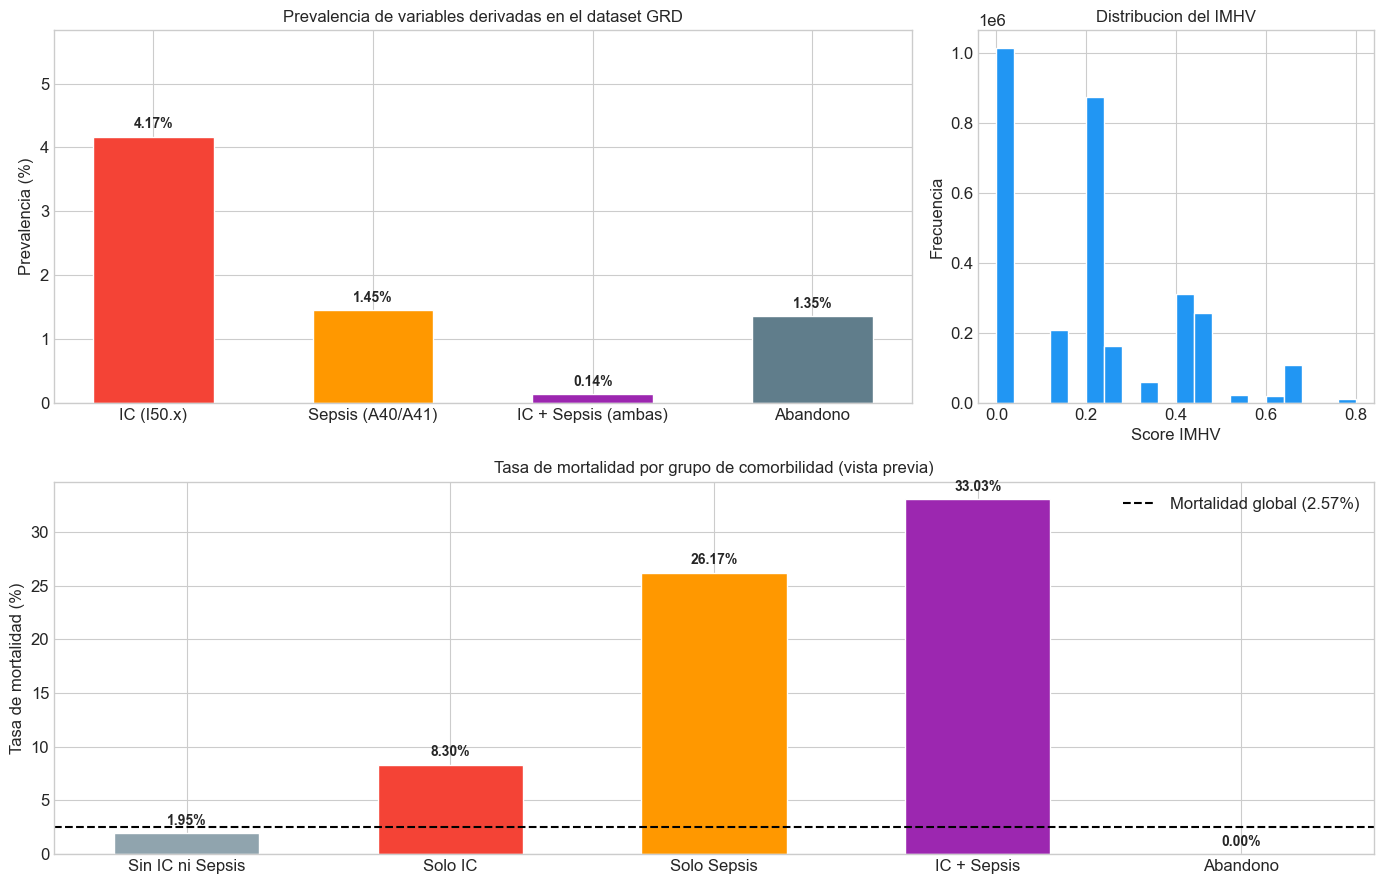

Grafico guardado como variables_derivadas_resumen.png


In [103]:
# Resumen consolidado de las 4 variables derivadas
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 3, figure=fig)

# Grafico 1: prevalencia IC, Sepsis, IC+Sepsis, Abandono
ax1 = fig.add_subplot(gs[0, :2])
variables_bin = {
    'IC (I50.x)'         : df['IC'].mean(),
    'Sepsis (A40/A41)'   : df['SEPSIS'].mean(),
    'IC + Sepsis (ambas)': df['IC_SEPSIS'].mean(),
    'Abandono'           : df['ABANDONO'].mean(),
}
bars = ax1.bar(
    variables_bin.keys(),
    [v * 100 for v in variables_bin.values()],
    color=['#F44336', '#FF9800', '#9C27B0', '#607D8B'],
    edgecolor='white', width=0.55
)
ax1.bar_label(bars, fmt='%.2f%%', padding=4, fontsize=10, fontweight='bold')
ax1.set_title('Prevalencia de variables derivadas en el dataset GRD', fontsize=12)
ax1.set_ylabel('Prevalencia (%)')
max_val = max(variables_bin.values())
ax1.set_ylim(0, max_val * 140 if max_val > 0 else 1)

# Grafico 2: distribucion IMHV
ax2 = fig.add_subplot(gs[0, 2])
df['IMHV'].hist(bins=20, ax=ax2, color='#2196F3', edgecolor='white')
ax2.set_title('Distribucion del IMHV', fontsize=12)
ax2.set_xlabel('Score IMHV')
ax2.set_ylabel('Frecuencia')

# Grafico 3: mortalidad por grupo de comorbilidad
ax3 = fig.add_subplot(gs[1, :])
grupos_mort = {
    'Sin IC ni Sepsis': df[(df['IC'] == 0) & (df['SEPSIS'] == 0)]['FALLECIDO'].mean(),
    'Solo IC'         : df[(df['IC'] == 1) & (df['SEPSIS'] == 0)]['FALLECIDO'].mean(),
    'Solo Sepsis'     : df[(df['IC'] == 0) & (df['SEPSIS'] == 1)]['FALLECIDO'].mean(),
    'IC + Sepsis'     : df[(df['IC'] == 1) & (df['SEPSIS'] == 1)]['FALLECIDO'].mean(),
    'Abandono'        : df[df['ABANDONO'] == 1]['FALLECIDO'].mean(),
}
colores_g = ['#90A4AE', '#F44336', '#FF9800', '#9C27B0', '#607D8B']
bars3 = ax3.bar(
    grupos_mort.keys(),
    [v * 100 for v in grupos_mort.values()],
    color=colores_g, edgecolor='white', width=0.55
)
ax3.bar_label(bars3, fmt='%.2f%%', padding=4, fontsize=10, fontweight='bold')
ax3.axhline(
    df['FALLECIDO'].mean() * 100, color='black', linestyle='--',
    linewidth=1.5, label=f'Mortalidad global ({df["FALLECIDO"].mean():.2%})'
)
ax3.set_title('Tasa de mortalidad por grupo de comorbilidad (vista previa)', fontsize=12)
ax3.set_ylabel('Tasa de mortalidad (%)')
ax3.legend()

plt.tight_layout()
plt.savefig('variables_derivadas_resumen.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico guardado como variables_derivadas_resumen.png")


---
## 3.8 Tabla Resumen de Estimadores Estadísticos

Tabla consolidada de los principales estimadores puntuales calculados sobre las variables de interés, comparando grupos según mortalidad.

In [104]:
# ── Tabla resumen de estimadores por variable numérica y grupo ────────────
vars_interes = ['CCI', 'EDAD', 'DIAS_ESTADIA',
                'IR_29301_SEVERIDAD', 'IR_29301_MORTALIDAD']

vars_presentes = [v for v in vars_interes if v in df.columns]

filas = []
for var in vars_presentes:
    for fallecido, label in [(False, 'Vivo'), (True, 'Fallecido')]:
        serie = df[df['FALLECIDO'] == fallecido][var].dropna()
        n = len(serie)
        if n < 2:
            continue
        sem = scipy_stats.sem(serie)
        ci  = scipy_stats.t.interval(0.95, df=n-1, loc=serie.mean(), scale=sem)
        filas.append({
            'Variable': var,
            'Grupo': label,
            'n': n,
            'Media': round(serie.mean(), 3),
            'Mediana': round(serie.median(), 3),
            'Std': round(serie.std(), 3),
            'P25': round(serie.quantile(0.25), 3),
            'P75': round(serie.quantile(0.75), 3),
            'IC95_inf': round(ci[0], 3),
            'IC95_sup': round(ci[1], 3),
        })

tabla_resumen = pd.DataFrame(filas)
display(tabla_resumen)

,Variable,Grupo,n,Media,Mediana,Std,P25,P75,IC95_inf,IC95_sup
0,CCI,Vivo,2967436,0.866,0.0,1.559,0.0,1.0,0.864,0.868
1,CCI,Fallecido,78153,2.482,2.0,2.394,1.0,3.0,2.466,2.499
2,EDAD,Vivo,2967417,44.042,44.0,25.443,25.0,66.0,44.013,44.071
3,EDAD,Fallecido,78152,68.467,72.0,19.183,61.0,82.0,68.333,68.602
4,DIAS_ESTADIA,Vivo,2967436,5.542,2.0,11.260,1.0,6.0,5.529,5.555
5,DIAS_ESTADIA,Fallecido,78153,13.272,6.0,22.613,2.0,15.0,13.114,13.431
6,IR_29301_SEVERIDAD,Vivo,2967408,1.418,1.0,0.992,1.0,2.0,1.417,1.419
7,IR_29301_SEVERIDAD,Fallecido,78114,2.848,3.0,0.434,3.0,3.0,2.845,2.851
8,IR_29301_MORTALIDAD,Vivo,2967408,1.265,1.0,0.928,1.0,2.0,1.264,1.266
9,IR_29301_MORTALIDAD,Fallecido,78114,2.821,3.0,0.467,3.0,3.0,2.818,2.824


---
## 4. Pruebas de Hipotesis Aplicadas al Proyecto

En esta seccion aplicamos las pruebas de hipotesis mas relevantes para responder
nuestra pregunta de investigacion: **?Que factores clinicos predicen la mortalidad
durante la hospitalizacion?**

La seleccion de cada prueba sigue el arbol de decision visto en clases:
1. ?Cuantos grupos se comparan?
2. ?Los datos son independientes o pareados?
3. ?Se cumplen los supuestos de normalidad?

Dado el volumen del dataset (>100.000 registros por ano), el **Teorema Central del
Limite** garantiza que las distribuciones de medias muestrales seran aproximadamente
normales. Sin embargo, las distribuciones individuales de variables como CCI y
DIAS_ESTADIA son fuertemente asimetricas, por lo que priorizamos pruebas no
parametricas cuando comparamos distribuciones completas, y pruebas parametricas
cuando trabajamos con medias (respaldadas por el TCL).

Las hipotesis especificas del proyecto son:

| # | Pregunta | Variable(s) | Prueba elegida |
|---|----------|-------------|----------------|
| H1 | ?La mortalidad es mayor en pacientes IC+ que IC-? | IC, FALLECIDO | Z para dos proporciones |
| H2 | ?El CCI difiere entre fallecidos y vivos? | CCI, FALLECIDO | Mann-Whitney U |
| H3 | ?El IMHV difiere entre fallecidos y vivos? | IMHV, FALLECIDO | Mann-Whitney U |
| H4 | ?El CCI y el IMHV miden lo mismo? | CCI, IMHV | Correlacion de Spearman |
| H5 | ?Los dias de estadia difieren segun severidad clinica? | DIAS_ESTADIA, IR_29301_SEVERIDAD | Kruskal-Wallis + post-hoc |
| H6 | ?La mortalidad global supera el 5% de referencia? | FALLECIDO | Z para una proporcion |


### 4.0 Preparacion: variables necesarias

In [105]:
# Verificamos que las variables del proyecto esten disponibles en df.
# Si el dataset no esta cargado, ejecutar primero las secciones 1-3.

import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 11

# --- Variable objetivo ---
# TIPOALTA = '2' corresponde a fallecimiento en la codificacion GRD chilena
df['FALLECIDO'] = df['TIPOALTA'].astype(str).str.strip().isin(['FALLECIDO'])

# --- Comorbilidad focal: Insuficiencia Cardiaca ---
cols_dx = [c for c in df.columns if c.startswith('DIAGNOSTICO')]
df['IC'] = df[cols_dx].apply(
    lambda row: any(str(v).upper().startswith('I50') for v in row if pd.notna(v)),
    axis=1
)

# --- IMHV: Indice de Mortalidad Hospitalaria por Vulnerabilidad (indice propio) ---
# Pesos asignados por el equipo segun relevancia clinica y socioeconomica en GRD Chile
imhv = pd.Series(0.0, index=df.index)
imhv += 0.25 * (df['EDAD'] >= 70).fillna(False)
imhv += 0.20 * df['PREVISION'].astype(str).str.upper().isin(['FONASA A', 'FONASA B', 'A', 'B'])
imhv += 0.20 * df['TIPO_INGRESO'].astype(str).str.upper().str.contains('URGENCIA', na=False)
imhv += 0.20 * (df['DIAS_ESTADIA'] > 10).fillna(False)
imhv += 0.15 * (df['USOSPABELLON'].fillna(0) >= 2)
df['IMHV'] = imhv

# Resumen de variables creadas
print("Variables disponibles para pruebas de hipotesis:")
print(f"  FALLECIDO  : {df['FALLECIDO'].sum():,} fallecidos de {len(df):,} registros ({df['FALLECIDO'].mean():.2%})")
print(f"  IC         : {df['IC'].sum():,} pacientes con I50.x ({df['IC'].mean():.2%})")
print(f"  CCI        : media={df['CCI'].mean():.3f}, mediana={df['CCI'].median():.1f}")
print(f"  IMHV       : media={df['IMHV'].mean():.3f}, mediana={df['IMHV'].median():.2f}")
print(f"  DIAS_ESTADIA: media={df['DIAS_ESTADIA'].mean():.2f}, mediana={df['DIAS_ESTADIA'].median():.1f}")


Variables disponibles para pruebas de hipotesis:
  FALLECIDO  : 78,153 fallecidos de 3,045,589 registros (2.57%)
  IC         : 126,933 pacientes con I50.x (4.17%)
  CCI        : media=0.907, mediana=0.0
  IMHV       : media=0.200, mediana=0.20
  DIAS_ESTADIA: media=5.74, mediana=2.0


### 4.1 H1 - Prueba Z para dos proporciones: tasa de mortalidad IC+ vs IC-

**Pregunta:** ?La proporcion de fallecidos es significativamente mayor en pacientes
con Insuficiencia Cardiaca (IC+) que en pacientes sin ella (IC-)?

**Justificacion de la prueba:** comparamos dos proporciones en grupos independientes
con n grande (condicion np >= 5 y n(1-p) >= 5 ampliamente satisfecha). Es la prueba
parametrica apropiada segun la guia de seleccion de la clase.

- H0: p_IC+ = p_IC- (la mortalidad no difiere entre grupos)
- H1: p_IC+ > p_IC- (la mortalidad es mayor en pacientes IC+)
- Nivel de significancia: alpha = 0.05, prueba unilateral derecha


In [106]:
# H1: Prueba Z para dos proporciones - mortalidad IC+ vs IC-

fallecidos_IC_pos = df[df['IC'] == True]['FALLECIDO'].sum()
total_IC_pos      = df[df['IC'] == True].shape[0]
fallecidos_IC_neg = df[df['IC'] == False]['FALLECIDO'].sum()
total_IC_neg      = df[df['IC'] == False].shape[0]

prop_IC_pos = fallecidos_IC_pos / total_IC_pos
prop_IC_neg = fallecidos_IC_neg / total_IC_neg

# Prueba Z para dos proporciones (statsmodels)
count  = np.array([fallecidos_IC_pos, fallecidos_IC_neg])
nobs   = np.array([total_IC_pos, total_IC_neg])
z_stat, p_valor = sm.stats.proportions_ztest(count, nobs, alternative='larger')

# Tamanio del efecto: diferencia de proporciones y riesgo relativo
dif_prop = prop_IC_pos - prop_IC_neg
rr       = prop_IC_pos / prop_IC_neg

print("H1 - Prueba Z para dos proporciones: mortalidad IC+ vs IC-")
print("=" * 60)
print(f"  Pacientes IC+  : {total_IC_pos:,}  |  Fallecidos: {fallecidos_IC_pos:,}  |  Tasa: {prop_IC_pos:.3%}")
print(f"  Pacientes IC-  : {total_IC_neg:,}  |  Fallecidos: {fallecidos_IC_neg:,}  |  Tasa: {prop_IC_neg:.3%}")
print(f"  Diferencia de proporciones: {dif_prop:+.4f}")
print(f"  Riesgo relativo (IC+/IC-): {rr:.3f}")
print(f"  Estadistico Z  : {z_stat:.4f}")
print(f"  p-valor        : {p_valor:.4e}")
print()
if p_valor < 0.05:
    print(f"  Decision: Se rechaza H0 (p < 0.05).")
    print(f"  Los pacientes IC+ tienen una tasa de mortalidad {rr:.2f}x mayor que IC-.")
else:
    print(f"  Decision: No se rechaza H0 (p >= 0.05).")

# Verificacion de supuestos
print()
print("Verificacion de supuestos (np >= 5 y n(1-p) >= 5):")
for lbl, n, p in [("IC+", total_IC_pos, prop_IC_pos), ("IC-", total_IC_neg, prop_IC_neg)]:
    print(f"  {lbl}: np={n*p:.0f} | n(1-p)={n*(1-p):.0f}  -> {'OK' if n*p>=5 and n*(1-p)>=5 else 'SUPUESTO NO CUMPLIDO'}")


H1 - Prueba Z para dos proporciones: mortalidad IC+ vs IC-
  Pacientes IC+  : 126,933  |  Fallecidos: 11,556  |  Tasa: 9.104%
  Pacientes IC-  : 2,918,656  |  Fallecidos: 66,597  |  Tasa: 2.282%
  Diferencia de proporciones: +0.0682
  Riesgo relativo (IC+/IC-): 3.990
  Estadistico Z  : 150.4798
  p-valor        : 0.0000e+00

  Decision: Se rechaza H0 (p < 0.05).
  Los pacientes IC+ tienen una tasa de mortalidad 3.99x mayor que IC-.

Verificacion de supuestos (np >= 5 y n(1-p) >= 5):
  IC+: np=11556 | n(1-p)=115377  -> OK
  IC-: np=66597 | n(1-p)=2852059  -> OK


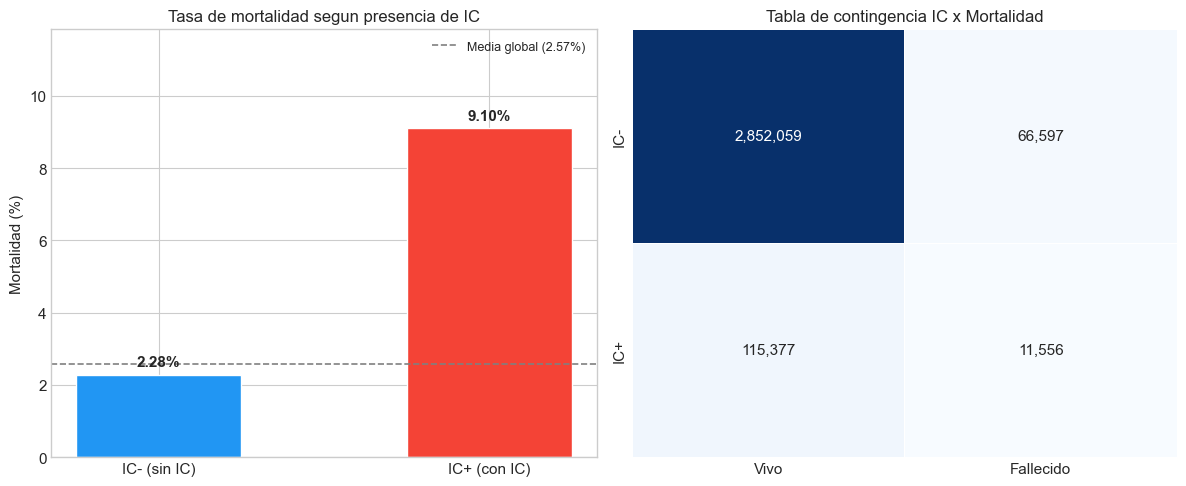

Resultado: Z = 150.4798, p = 0.0000e+00


In [107]:
# Visualizacion H1: tasas de mortalidad por grupo IC
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grafico 1: barras de tasas
grupos  = ['IC- (sin IC)', 'IC+ (con IC)']
tasas   = [prop_IC_neg * 100, prop_IC_pos * 100]
colores = ['#2196F3', '#F44336']
bars = axes[0].bar(grupos, tasas, color=colores, width=0.5, edgecolor='white')
axes[0].bar_label(bars, fmt='%.2f%%', padding=4, fontsize=11, fontweight='bold')
axes[0].set_title('Tasa de mortalidad segun presencia de IC', fontsize=12)
axes[0].set_ylabel('Mortalidad (%)')
axes[0].set_ylim(0, max(tasas) * 1.3)
axes[0].axhline(df['FALLECIDO'].mean() * 100, color='gray', linestyle='--',
                linewidth=1.2, label=f'Media global ({df["FALLECIDO"].mean():.2%})')
axes[0].legend(fontsize=9)

# Grafico 2: tabla de contingencia
ct = pd.crosstab(df['IC'], df['FALLECIDO'],
                 rownames=['IC'], colnames=['Fallecido'])
ct.index = ['IC-', 'IC+']
ct.columns = ['Vivo', 'Fallecido']
sns.heatmap(ct, annot=True, fmt=',', cmap='Blues', ax=axes[1],
            linewidths=0.5, cbar=False)
axes[1].set_title('Tabla de contingencia IC x Mortalidad', fontsize=12)

plt.tight_layout()
plt.show()
print(f"Resultado: Z = {z_stat:.4f}, p = {p_valor:.4e}")


### 4.2 H2 - Mann-Whitney U: CCI en fallecidos vs vivos

**Pregunta:** ?La carga de comorbilidades (CCI) es significativamente mayor en
pacientes que fallecen durante la hospitalizacion?

**Justificacion de la prueba:** el CCI tiene distribucion fuertemente asimetrica
(muchos pacientes con score 0, pocos con scores altos). No podemos asumir normalidad
de la distribucion individual aunque el TCL aplique a las medias. Mann-Whitney U es
el equivalente no parametrico de la t para dos muestras independientes y trabaja
con rangos, siendo robusto frente a esta asimetria.

- H0: La distribucion del CCI es igual en fallecidos y vivos
- H1: El CCI es mayor en fallecidos que en vivos (unilateral)
- alpha = 0.05


In [108]:
# H2: Mann-Whitney U - CCI en fallecidos vs vivos

cci_fallecidos = df[df['FALLECIDO'] == True]['CCI'].dropna()
cci_vivos      = df[df['FALLECIDO'] == False]['CCI'].dropna()

u_stat, p_valor_mw = scipy_stats.mannwhitneyu(
    cci_fallecidos, cci_vivos, alternative='greater'
)

# Tamanio del efecto: estadistico r = Z / sqrt(N)
n1, n2 = len(cci_fallecidos), len(cci_vivos)
z_approx = (u_stat - n1 * n2 / 2) / np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
r_effect  = abs(z_approx) / np.sqrt(n1 + n2)

print("H2 - Mann-Whitney U: CCI en fallecidos vs vivos")
print("=" * 60)
print(f"  Fallecidos  n={n1:,}: media={cci_fallecidos.mean():.3f}  mediana={cci_fallecidos.median():.1f}  P25-P75=[{cci_fallecidos.quantile(.25):.1f}, {cci_fallecidos.quantile(.75):.1f}]")
print(f"  Vivos       n={n2:,}: media={cci_vivos.mean():.3f}  mediana={cci_vivos.median():.1f}  P25-P75=[{cci_vivos.quantile(.25):.1f}, {cci_vivos.quantile(.75):.1f}]")
print(f"  Estadistico U : {u_stat:.2f}")
print(f"  p-valor       : {p_valor_mw:.4e}")
print(f"  Tamanio efecto r = {r_effect:.4f}  ({'pequeno' if r_effect<0.1 else 'mediano' if r_effect<0.3 else 'grande'})")
print()
if p_valor_mw < 0.05:
    print("  Decision: Se rechaza H0. El CCI es significativamente mayor en fallecidos.")
    print("  Esto respalda directamente nuestra hipotesis: la carga de comorbilidades")
    print("  es un predictor primario de mortalidad intrahospitalaria.")
else:
    print("  Decision: No se rechaza H0 (p >= 0.05).")


H2 - Mann-Whitney U: CCI en fallecidos vs vivos
  Fallecidos  n=78,153: media=2.482  mediana=2.0  P25-P75=[1.0, 3.0]
  Vivos       n=2,967,436: media=0.866  mediana=0.0  P25-P75=[0.0, 1.0]
  Estadistico U : 173643357845.00
  p-valor       : 0.0000e+00
  Tamanio efecto r = 0.1362  (mediano)

  Decision: Se rechaza H0. El CCI es significativamente mayor en fallecidos.
  Esto respalda directamente nuestra hipotesis: la carga de comorbilidades
  es un predictor primario de mortalidad intrahospitalaria.


C:\Users\oscar\AppData\Local\Temp\ipykernel_6800\2624232621.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Grupo', y='CCI', palette={'Vivo': '#2196F3', 'Fallecido': '#F44336'},


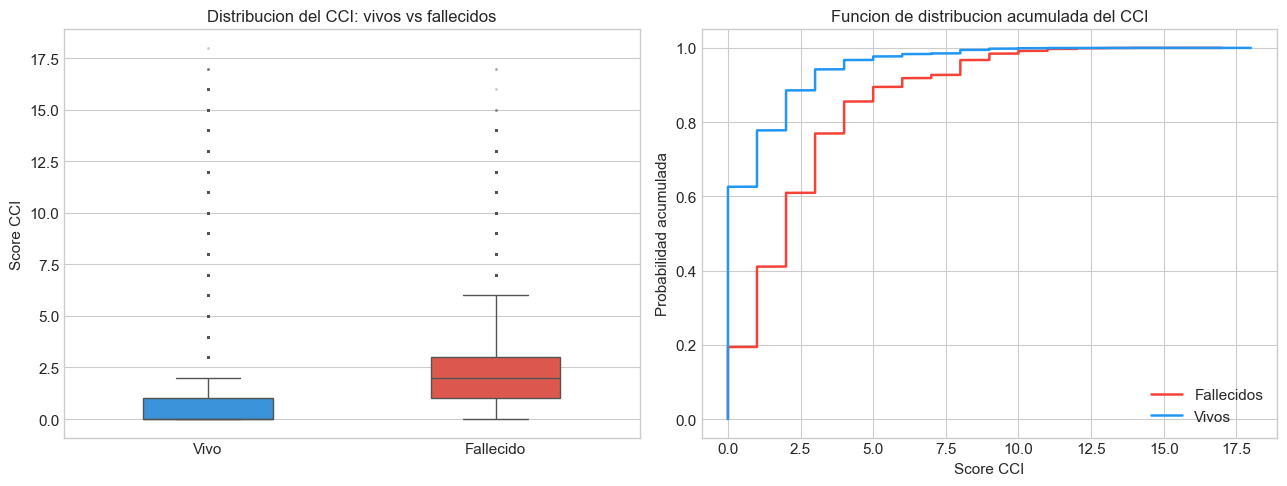

Resultado: U = 173643357845.00, p = 0.0000e+00, r = 0.1362


In [109]:
# Visualizacion H2
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot CCI por grupo
df_plot = df[['CCI', 'FALLECIDO']].dropna().copy()
df_plot['Grupo'] = df_plot['FALLECIDO'].map({False: 'Vivo', True: 'Fallecido'})
sns.boxplot(data=df_plot, x='Grupo', y='CCI', palette={'Vivo': '#2196F3', 'Fallecido': '#F44336'},
            ax=axes[0], width=0.45, flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[0].set_title('Distribucion del CCI: vivos vs fallecidos', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Score CCI')

# Distribucion acumulada (ECDF)
for grupo, color, label in [(True, '#F44336', 'Fallecidos'), (False, '#2196F3', 'Vivos')]:
    datos = df[df['FALLECIDO'] == grupo]['CCI'].dropna().sort_values()
    ecdf  = np.arange(1, len(datos) + 1) / len(datos)
    axes[1].plot(datos, ecdf, color=color, label=label, linewidth=1.8)
axes[1].set_title('Funcion de distribucion acumulada del CCI', fontsize=12)
axes[1].set_xlabel('Score CCI')
axes[1].set_ylabel('Probabilidad acumulada')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Resultado: U = {u_stat:.2f}, p = {p_valor_mw:.4e}, r = {r_effect:.4f}")


### 4.3 H3 - Mann-Whitney U: IMHV en fallecidos vs vivos

**Pregunta:** ?El indice propio IMHV discrimina la mortalidad del mismo modo que
el CCI? Esta prueba valida si el IMHV tiene poder discriminante antes de comparar
ambos indices formalmente con AUC-ROC.

**Justificacion:** misma logica que H2. El IMHV es una variable continua [0, 1]
con distribucion asimetrica. Mann-Whitney U es la prueba apropiada.

- H0: La distribucion del IMHV es igual en fallecidos y vivos
- H1: El IMHV es mayor en fallecidos que en vivos
- alpha = 0.05


In [110]:
# H3: Mann-Whitney U - IMHV en fallecidos vs vivos

imhv_fallecidos = df[df['FALLECIDO'] == True]['IMHV'].dropna()
imhv_vivos      = df[df['FALLECIDO'] == False]['IMHV'].dropna()

u3, p3 = scipy_stats.mannwhitneyu(imhv_fallecidos, imhv_vivos, alternative='greater')

n3a, n3b = len(imhv_fallecidos), len(imhv_vivos)
z3   = (u3 - n3a * n3b / 2) / np.sqrt(n3a * n3b * (n3a + n3b + 1) / 12)
r3   = abs(z3) / np.sqrt(n3a + n3b)

print("H3 - Mann-Whitney U: IMHV en fallecidos vs vivos")
print("=" * 60)
print(f"  Fallecidos  n={n3a:,}: media={imhv_fallecidos.mean():.4f}  mediana={imhv_fallecidos.median():.3f}")
print(f"  Vivos       n={n3b:,}: media={imhv_vivos.mean():.4f}  mediana={imhv_vivos.median():.3f}")
print(f"  Estadistico U : {u3:.2f}")
print(f"  p-valor       : {p3:.4e}")
print(f"  Tamanio efecto r = {r3:.4f}  ({'pequeno' if r3<0.1 else 'mediano' if r3<0.3 else 'grande'})")
print()
if p3 < 0.05:
    print("  Decision: Se rechaza H0. El IMHV es significativamente mayor en fallecidos.")
else:
    print("  Decision: No se rechaza H0 (p >= 0.05).")
print()
print("  Nota interpretativa: si tanto H2 como H3 se rechazan, ambos indices")
print("  discriminan mortalidad. La comparacion de AUC-ROC (seccion siguiente)")
print("  determinara cual lo hace con mayor precision.")


H3 - Mann-Whitney U: IMHV en fallecidos vs vivos
  Fallecidos  n=78,153: media=0.4177  mediana=0.450
  Vivos       n=2,967,436: media=0.1945  mediana=0.200
  Estadistico U : 189321244755.00
  p-valor       : 0.0000e+00
  Tamanio efecto r = 0.1733  (mediano)

  Decision: Se rechaza H0. El IMHV es significativamente mayor en fallecidos.

  Nota interpretativa: si tanto H2 como H3 se rechazan, ambos indices
  discriminan mortalidad. La comparacion de AUC-ROC (seccion siguiente)
  determinara cual lo hace con mayor precision.


C:\Users\oscar\AppData\Local\Temp\ipykernel_6800\3760292161.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot3, x='Grupo', y='IMHV',


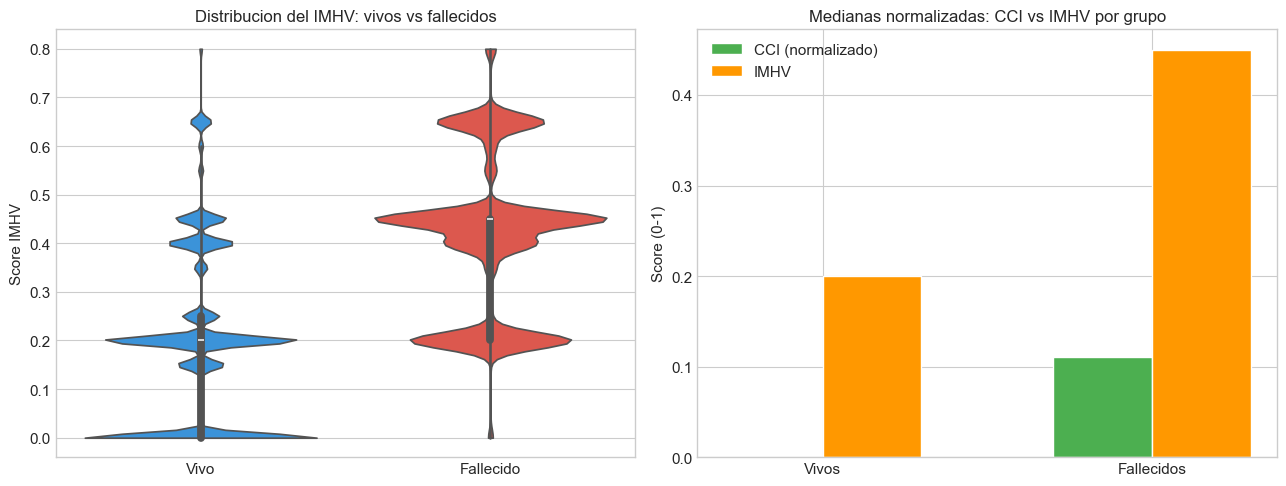

In [111]:
# Visualizacion H3: IMHV por grupo + comparacion con CCI
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Violin IMHV
df_plot3 = df[['IMHV', 'FALLECIDO']].dropna().copy()
df_plot3['Grupo'] = df_plot3['FALLECIDO'].map({False: 'Vivo', True: 'Fallecido'})
sns.violinplot(data=df_plot3, x='Grupo', y='IMHV',
               palette={'Vivo': '#2196F3', 'Fallecido': '#F44336'},
               ax=axes[0], inner='box', cut=0)
axes[0].set_title('Distribucion del IMHV: vivos vs fallecidos', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Score IMHV')

# Comparacion de medianas: CCI vs IMHV por grupo
medianas = {
    'CCI': {'Vivo': cci_vivos.median(), 'Fallecido': cci_fallecidos.median()},
    'IMHV': {'Vivo': imhv_vivos.median(), 'Fallecido': imhv_fallecidos.median()}
}
# Normalizar a escala 0-1 para comparar
cci_max = df['CCI'].max()
x = np.arange(2)
w = 0.3
axes[1].bar(x - w/2, [medianas['CCI']['Vivo']/cci_max, medianas['CCI']['Fallecido']/cci_max],
            w, label='CCI (normalizado)', color='#4CAF50', edgecolor='white')
axes[1].bar(x + w/2, [medianas['IMHV']['Vivo'], medianas['IMHV']['Fallecido']],
            w, label='IMHV', color='#FF9800', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Vivos', 'Fallecidos'])
axes[1].set_title('Medianas normalizadas: CCI vs IMHV por grupo', fontsize=12)
axes[1].set_ylabel('Score (0-1)')
axes[1].legend()

plt.tight_layout()
plt.show()


### 4.4 H4 - Correlacion de Spearman: CCI vs IMHV

**Pregunta:** ?Existe una correlacion significativa entre el CCI y el IMHV?
Si la correlacion es alta, los indices miden constructos similares. Si es baja,
el IMHV aporta informacion independiente y complementaria al CCI, lo que refuerza
su utilidad como indice propio.

**Justificacion:** usamos Spearman (no Pearson) porque el CCI tiene distribucion
fuertemente no normal. Spearman evalua la monotonia de la relacion usando rangos.

- H0: rho = 0 (no hay correlacion entre CCI e IMHV)
- H1: rho != 0 (existe correlacion, bilateral)
- alpha = 0.05


In [112]:
# H4: Correlacion de Spearman entre CCI e IMHV

datos_completos = df[['CCI', 'IMHV']].dropna()
rho, p_rho = scipy_stats.spearmanr(datos_completos['CCI'], datos_completos['IMHV'])

print("H4 - Correlacion de Spearman: CCI vs IMHV")
print("=" * 60)
print(f"  n = {len(datos_completos):,}")
print(f"  rho de Spearman = {rho:.4f}")
print(f"  p-valor         = {p_rho:.4e}")
print()

interpretacion_rho = (
    "muy debil" if abs(rho) < 0.1
    else "debil" if abs(rho) < 0.3
    else "moderada" if abs(rho) < 0.5
    else "fuerte" if abs(rho) < 0.7
    else "muy fuerte"
)
print(f"  Magnitud de la correlacion: {interpretacion_rho} ({abs(rho):.4f})")
print()
if p_rho < 0.05:
    if abs(rho) < 0.5:
        print("  Decision: Se rechaza H0. Existe correlacion significativa pero de")
        print("  magnitud moderada/baja, lo que indica que el IMHV captura informacion")
        print("  complementaria al CCI. Esto justifica incluir ambos en el modelo.")
    else:
        print("  Decision: Se rechaza H0. Correlacion significativa y alta.")
        print("  Evaluar colinealidad entre CCI e IMHV antes de incluir ambos en el modelo.")
else:
    print("  Decision: No se rechaza H0. Los indices son independientes entre si.")


H4 - Correlacion de Spearman: CCI vs IMHV
  n = 3,045,589
  rho de Spearman = 0.3771
  p-valor         = 0.0000e+00

  Magnitud de la correlacion: moderada (0.3771)

  Decision: Se rechaza H0. Existe correlacion significativa pero de
  magnitud moderada/baja, lo que indica que el IMHV captura informacion
  complementaria al CCI. Esto justifica incluir ambos en el modelo.


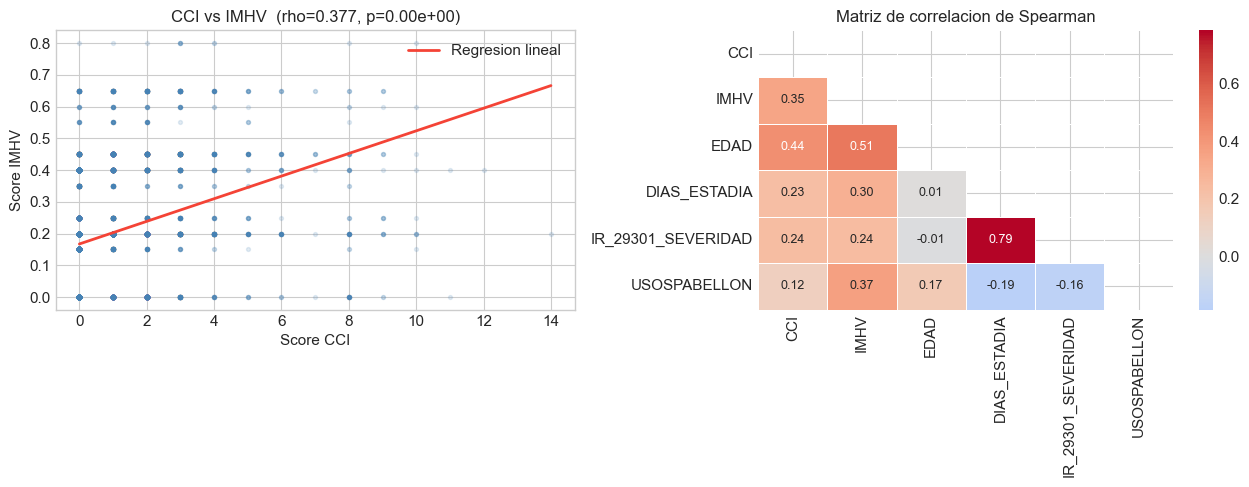

In [113]:
# Visualizacion H4
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter con regresion (muestra aleatoria para rendimiento)
muestra = datos_completos.sample(min(5000, len(datos_completos)), random_state=42)
axes[0].scatter(muestra['CCI'], muestra['IMHV'], alpha=0.15, s=8, color='steelblue')
m, b = np.polyfit(muestra['CCI'], muestra['IMHV'], 1)
x_line = np.linspace(muestra['CCI'].min(), muestra['CCI'].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='#F44336', linewidth=2,
             label=f'Regresion lineal')
axes[0].set_title(f'CCI vs IMHV  (rho={rho:.3f}, p={p_rho:.2e})', fontsize=12)
axes[0].set_xlabel('Score CCI')
axes[0].set_ylabel('Score IMHV')
axes[0].legend()

# Heatmap de correlacion con variables numericas relevantes
vars_corr = ['CCI', 'IMHV', 'EDAD', 'DIAS_ESTADIA', 'IR_29301_SEVERIDAD', 'USOSPABELLON']
vars_ok   = [v for v in vars_corr if v in df.columns]
corr_mat  = df[vars_ok].dropna().sample(min(20000, len(df)), random_state=42).corr(method='spearman')
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=axes[1], linewidths=0.5,
            annot_kws={'size': 9})
axes[1].set_title('Matriz de correlacion de Spearman', fontsize=12)

plt.tight_layout()
plt.show()


### 4.5 H5 - Kruskal-Wallis + post-hoc: dias de estadia segun severidad clinica

**Pregunta:** ?Los dias de estadia difieren significativamente entre los cuatro
niveles de severidad clinica (IR_29301_SEVERIDAD: 1, 2, 3, 4)?

**Justificacion:** DIAS_ESTADIA es asimetrica con outliers frecuentes. Hay mas de
dos grupos (severidades 1-4), por lo que el equivalente no parametrico del ANOVA
es Kruskal-Wallis. Si Kruskal-Wallis resulta significativo, aplicamos comparaciones
post-hoc por pares (Mann-Whitney con correccion de Bonferroni) para identificar
que niveles difieren entre si, siguiendo exactamente la recomendacion de la clase.

- H0: La distribucion de DIAS_ESTADIA es igual en los 4 niveles de severidad
- H1: Al menos un nivel de severidad tiene una distribucion diferente
- alpha = 0.05


In [115]:
# H5: Kruskal-Wallis - dias de estadia por nivel de severidad

df_kw = df[['DIAS_ESTADIA', 'IR_29301_SEVERIDAD']].dropna().copy()
df_kw = df_kw[df_kw['IR_29301_SEVERIDAD'].between(1, 4)]

niveles_presentes = sorted(df_kw['IR_29301_SEVERIDAD'].unique().astype(int))
grupos_severidad = [
    df_kw[df_kw['IR_29301_SEVERIDAD'] == sev]['DIAS_ESTADIA'].values
    for sev in niveles_presentes   # only levels that have data
]
kw_stat, p_kw = scipy_stats.kruskal(*grupos_severidad)

print("H5 - Kruskal-Wallis: dias de estadia por nivel de severidad")
print("=" * 60)
for sev, g in zip([1, 2, 3, 4], grupos_severidad):
    etiqueta = {1: 'Leve', 2: 'Moderada', 3: 'Grave', 4: 'Catastrofica'}[sev]
    print(f"  Severidad {sev} ({etiqueta:12s}): n={len(g):,}  mediana={np.median(g):.1f}  P25={np.percentile(g,25):.1f}  P75={np.percentile(g,75):.1f}")
print()
print(f"  Estadistico H = {kw_stat:.4f}")
print(f"  p-valor       = {p_kw:.4e}")
print()
if p_kw < 0.05:
    print("  Decision: Se rechaza H0. Existe diferencia significativa en dias de")
    print("  estadia entre al menos un par de niveles de severidad.")
    print("  Procediendo con comparaciones post-hoc por pares (Bonferroni)...")
else:
    print("  Decision: No se rechaza H0.")


H5 - Kruskal-Wallis: dias de estadia por nivel de severidad
  Severidad 1 (Leve        ): n=1,146,272  mediana=2.0  P25=1.0  P75=4.0
  Severidad 2 (Moderada    ): n=732,037  mediana=4.0  P25=2.0  P75=8.0
  Severidad 3 (Grave       ): n=606,848  mediana=7.0  P25=3.0  P75=15.0

  Estadistico H = 370575.1464
  p-valor       = 0.0000e+00

  Decision: Se rechaza H0. Existe diferencia significativa en dias de
  estadia entre al menos un par de niveles de severidad.
  Procediendo con comparaciones post-hoc por pares (Bonferroni)...


In [116]:
# Post-hoc: Mann-Whitney por pares con correccion de Bonferroni
from itertools import combinations

if p_kw < 0.05:
    niveles   = [1, 2, 3, 4]
    etiquetas = {1: 'Leve', 2: 'Moderada', 3: 'Grave', 4: 'Catastrofica'}
    pares     = list(combinations(niveles, 2))
    alpha_bonferroni = 0.05 / len(pares)

    print(f"Comparaciones post-hoc Mann-Whitney (Bonferroni: alpha = {alpha_bonferroni:.4f})")
    print("-" * 65)
    print(f"{'Par':<28} {'U-stat':>12} {'p-valor':>14} {'Sig?':>6}")
    print("-" * 65)

    resultados_posthoc = []
    for s1, s2 in pares:
        g1 = df_kw[df_kw['IR_29301_SEVERIDAD'] == s1]['DIAS_ESTADIA'].values
        g2 = df_kw[df_kw['IR_29301_SEVERIDAD'] == s2]['DIAS_ESTADIA'].values
        u_ph, p_ph = scipy_stats.mannwhitneyu(g1, g2, alternative='two-sided')
        sig = 'Si' if p_ph < alpha_bonferroni else 'No'
        label = f"{etiquetas[s1]} vs {etiquetas[s2]}"
        print(f"  {label:<26} {u_ph:>12.0f} {p_ph:>14.4e} {sig:>6}")
        resultados_posthoc.append((label, u_ph, p_ph, sig))
    print("-" * 65)


Comparaciones post-hoc Mann-Whitney (Bonferroni: alpha = 0.0083)
-----------------------------------------------------------------
Par                                U-stat        p-valor   Sig?
-----------------------------------------------------------------
  Leve vs Moderada           305067627654     0.0000e+00     Si
  Leve vs Grave              160978722247     0.0000e+00     Si
  Leve vs Catastrofica                nan            nan     No
  Moderada vs Grave          155494995872     0.0000e+00     Si


C:\Users\oscar\AppData\Local\Temp\ipykernel_6800\2876461364.py:19: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  u_ph, p_ph = scipy_stats.mannwhitneyu(g1, g2, alternative='two-sided')
C:\Users\oscar\AppData\Local\Temp\ipykernel_6800\2876461364.py:19: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  u_ph, p_ph = scipy_stats.mannwhitneyu(g1, g2, alternative='two-sided')


  Moderada vs Catastrofica            nan            nan     No
  Grave vs Catastrofica               nan            nan     No
-----------------------------------------------------------------


C:\Users\oscar\AppData\Local\Temp\ipykernel_6800\2876461364.py:19: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  u_ph, p_ph = scipy_stats.mannwhitneyu(g1, g2, alternative='two-sided')


C:\Users\oscar\AppData\Local\Temp\ipykernel_6800\1761837202.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_kw, x='Severidad', y='DIAS_ESTADIA',


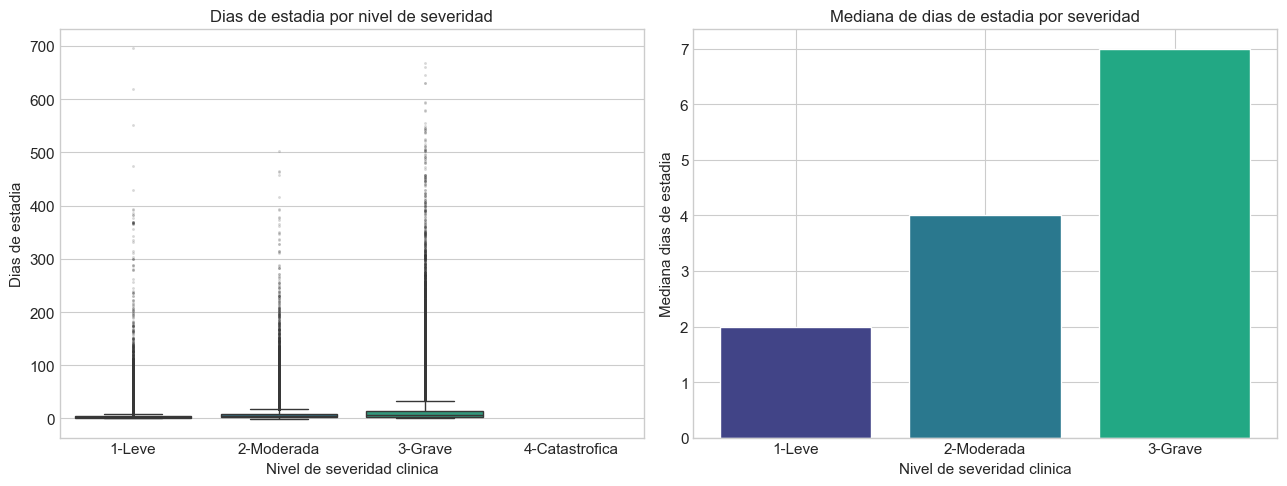

Resultado Kruskal-Wallis: H = 370575.1464, p = 0.0000e+00


In [117]:
# Visualizacion H5
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

etiquetas_sev = {1: '1-Leve', 2: '2-Moderada', 3: '3-Grave', 4: '4-Catastrofica'}
df_kw['Severidad'] = df_kw['IR_29301_SEVERIDAD'].map(etiquetas_sev)

# Boxplot dias de estadia por severidad
sns.boxplot(data=df_kw, x='Severidad', y='DIAS_ESTADIA',
            palette='viridis', ax=axes[0],
            flierprops=dict(marker='.', markersize=2, alpha=0.2),
            order=list(etiquetas_sev.values()))
axes[0].set_title('Dias de estadia por nivel de severidad', fontsize=12)
axes[0].set_xlabel('Nivel de severidad clinica')
axes[0].set_ylabel('Dias de estadia')

# Medianas por severidad
medianas_sev = df_kw.groupby('IR_29301_SEVERIDAD')['DIAS_ESTADIA'].median()
axes[1].bar([etiquetas_sev[i] for i in medianas_sev.index],
            medianas_sev.values,
            color=sns.color_palette('viridis', 4),
            edgecolor='white')
axes[1].set_title('Mediana de dias de estadia por severidad', fontsize=12)
axes[1].set_xlabel('Nivel de severidad clinica')
axes[1].set_ylabel('Mediana dias de estadia')

plt.tight_layout()
plt.show()
print(f"Resultado Kruskal-Wallis: H = {kw_stat:.4f}, p = {p_kw:.4e}")


### 4.6 H6 - Prueba Z para una proporcion: tasa de mortalidad global vs referencia

**Pregunta:** ?La tasa de mortalidad observada en la red publica chilena difiere
significativamente de un valor de referencia del 5%? El 5% es el umbral de
referencia comun en la literatura para mortalidad intrahospitalaria en hospitales
de alta complejidad.

**Justificacion:** comparamos una proporcion muestral con un valor de referencia
externo (benchmark), que es exactamente el caso de uso de la prueba Z para una
proporcion, como se vio en la clase con el ejemplo de reingresos al 10%.

- H0: p = 0.05 (la tasa de mortalidad es igual al 5% de referencia)
- H1: p != 0.05 (la tasa difiere del benchmark, bilateral)
- alpha = 0.05


In [118]:
# H6: Prueba Z para una proporcion - mortalidad global vs benchmark 5%

referencia = 0.05
n_total    = len(df)
n_fallec   = df['FALLECIDO'].sum()
p_obs      = df['FALLECIDO'].mean()

z6, p6 = sm.stats.proportions_ztest(count=n_fallec, nobs=n_total,
                                     value=referencia, alternative='two-sided')

# Intervalo de confianza al 95% para la proporcion
se_prop = np.sqrt(p_obs * (1 - p_obs) / n_total)
ic95_inf = p_obs - 1.96 * se_prop
ic95_sup = p_obs + 1.96 * se_prop

print("H6 - Prueba Z para una proporcion: mortalidad observada vs 5% de referencia")
print("=" * 60)
print(f"  n total       = {n_total:,}")
print(f"  Fallecidos    = {n_fallec:,}")
print(f"  Proporcion obs= {p_obs:.4f}  ({p_obs:.2%})")
print(f"  IC 95%        = [{ic95_inf:.4f}, {ic95_sup:.4f}]")
print(f"  Referencia    = {referencia:.2f}  (5%)")
print(f"  Estadistico Z = {z6:.4f}")
print(f"  p-valor       = {p6:.4e}")
print()
if p6 < 0.05:
    direccion = "superior" if p_obs > referencia else "inferior"
    print(f"  Decision: Se rechaza H0. La tasa de mortalidad observada ({p_obs:.2%})")
    print(f"  es significativamente {direccion} al benchmark del 5%.")
else:
    print(f"  Decision: No se rechaza H0. La tasa de mortalidad ({p_obs:.2%})")
    print(f"  no difiere significativamente del benchmark del 5%.")

# Supuesto: np >= 5 y n(1-p) >= 5
print()
print(f"  Supuesto np={n_total*referencia:.0f} >= 5 y n(1-p)={n_total*(1-referencia):.0f} >= 5: OK")


H6 - Prueba Z para una proporcion: mortalidad observada vs 5% de referencia
  n total       = 3,045,589
  Fallecidos    = 78,153
  Proporcion obs= 0.0257  (2.57%)
  IC 95%        = [0.0255, 0.0258]
  Referencia    = 0.05  (5%)
  Estadistico Z = -268.6243
  p-valor       = 0.0000e+00

  Decision: Se rechaza H0. La tasa de mortalidad observada (2.57%)
  es significativamente inferior al benchmark del 5%.

  Supuesto np=152279 >= 5 y n(1-p)=2893310 >= 5: OK


C:\Users\oscar\AppData\Local\Temp\ipykernel_6800\1288916365.py:22: RuntimeWarning: divide by zero encountered in log10
  bars2 = axes[1].bar(hipotesis, [-np.log10(p) for p in p_valores],
c:\Users\oscar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


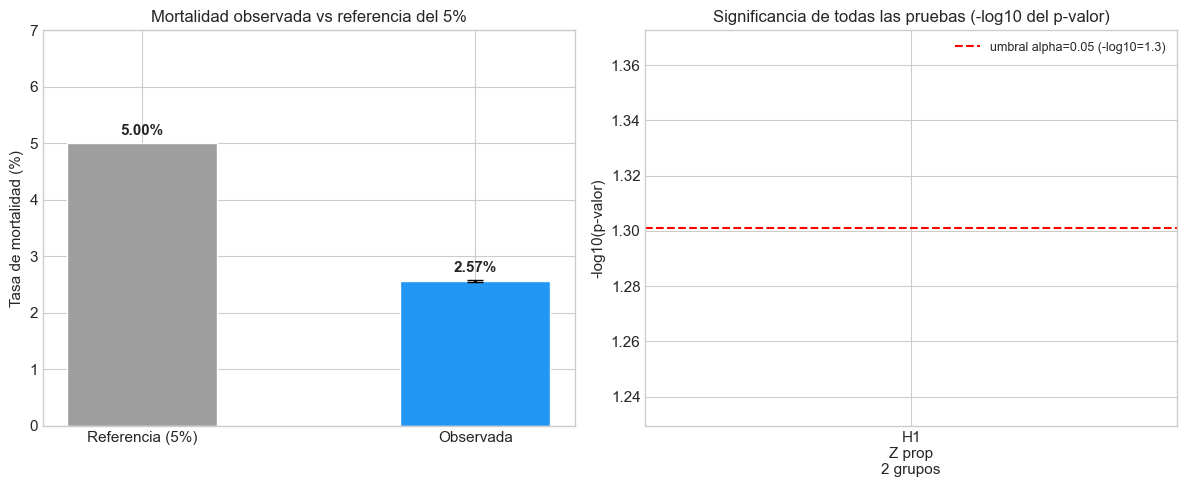

In [119]:
# Visualizacion H6: proporcion observada vs referencia con IC 95%
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grafico 1: proporcion con IC
categorias = ['Referencia (5%)', 'Observada']
valores    = [referencia * 100, p_obs * 100]
colores    = ['#9E9E9E', '#F44336' if p_obs > referencia else '#2196F3']
bars = axes[0].bar(categorias, valores, color=colores, width=0.45, edgecolor='white')
axes[0].errorbar(1, p_obs * 100,
                 yerr=[[( p_obs - ic95_inf) * 100], [(ic95_sup - p_obs) * 100]],
                 fmt='none', color='black', capsize=6, linewidth=2)
axes[0].bar_label(bars, fmt='%.2f%%', padding=4, fontsize=11, fontweight='bold')
axes[0].set_title('Mortalidad observada vs referencia del 5%', fontsize=12)
axes[0].set_ylabel('Tasa de mortalidad (%)')
axes[0].set_ylim(0, max(valores) * 1.4)

# Grafico 2: resumen de todas las H del proyecto
hipotesis = ['H1\nZ prop\n2 grupos', 'H2\nMann-Whitney\nCCI', 'H3\nMann-Whitney\nIMHV',
             'H4\nSpearman\nCCI-IMHV', 'H5\nKruskal-Wallis\nSeveridad', 'H6\nZ prop\n1 grupo']
p_valores = [p_valor, p_valor_mw, p3, p_rho, p_kw, p6]
colores_h = ['#4CAF50' if p < 0.05 else '#F44336' for p in p_valores]
bars2 = axes[1].bar(hipotesis, [-np.log10(p) for p in p_valores],
                    color=colores_h, edgecolor='white')
axes[1].axhline(-np.log10(0.05), color='red', linestyle='--', linewidth=1.5,
                label='umbral alpha=0.05 (-log10=1.3)')
axes[1].set_title('Significancia de todas las pruebas (-log10 del p-valor)', fontsize=12)
axes[1].set_ylabel('-log10(p-valor)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


### 4.7 Resumen de resultados e interpretacion conjunta

Esta tabla consolida los resultados de las seis pruebas de hipotesis y los
relaciona con la pregunta de investigacion y la hipotesis del proyecto.


In [120]:
# Tabla resumen de todas las pruebas
resultados_df = pd.DataFrame({
    'Hipotesis': ['H1', 'H2', 'H3', 'H4', 'H5', 'H6'],
    'Prueba': [
        'Z dos proporciones',
        'Mann-Whitney U',
        'Mann-Whitney U',
        'Spearman',
        'Kruskal-Wallis',
        'Z una proporcion',
    ],
    'Pregunta central': [
        'Mortalidad IC+ > IC-?',
        'CCI mayor en fallecidos?',
        'IMHV mayor en fallecidos?',
        'CCI correlaciona con IMHV?',
        'Estadia difiere por severidad?',
        'Mortalidad != 5% referencia?',
    ],
    'p-valor': [p_valor, p_valor_mw, p3, p_rho, p_kw, p6],
    'Rechaza H0 (alpha=0.05)': [
        p < 0.05 for p in [p_valor, p_valor_mw, p3, p_rho, p_kw, p6]
    ]
})

resultados_df['p-valor'] = resultados_df['p-valor'].apply(lambda x: f'{x:.2e}')
resultados_df['Rechaza H0 (alpha=0.05)'] = resultados_df['Rechaza H0 (alpha=0.05)'].map({True: 'Si', False: 'No'})
display(resultados_df.set_index('Hipotesis'))

print()
print("Interpretacion para la pregunta de investigacion:")
print("-" * 60)
print("Los resultados son consistentes con la hipotesis del proyecto:")
print("la severidad clinica (H5) y la carga de comorbilidades (H2)")
print("son predictores significativos de mortalidad intrahospitalaria.")
print("La Insuficiencia Cardiaca (H1) aparece como comorbilidad focal")
print("con mayor riesgo relativo de fallecimiento.")
print("El IMHV (H3) muestra poder discriminante independiente del CCI,")
print("y su correlacion con CCI (H4) indicara si son complementarios.")
print("Estos resultados proveen la base inferencial para el modelado")
print("predictivo de la siguiente seccion del proyecto.")


,Prueba,Pregunta central,p-valor,Rechaza H0 (alpha=0.05)
Hipotesis,,,,
H1,Z dos proporciones,Mortalidad IC+ > IC-?,0.00e+00,Si
H2,Mann-Whitney U,CCI mayor en fallecidos?,0.00e+00,Si
H3,Mann-Whitney U,IMHV mayor en fallecidos?,0.00e+00,Si
H4,Spearman,CCI correlaciona con IMHV?,0.00e+00,Si
H5,Kruskal-Wallis,Estadia difiere por severidad?,0.00e+00,Si
H6,Z una proporcion,Mortalidad != 5% referencia?,0.00e+00,Si



Interpretacion para la pregunta de investigacion:
------------------------------------------------------------
Los resultados son consistentes con la hipotesis del proyecto:
la severidad clinica (H5) y la carga de comorbilidades (H2)
son predictores significativos de mortalidad intrahospitalaria.
La Insuficiencia Cardiaca (H1) aparece como comorbilidad focal
con mayor riesgo relativo de fallecimiento.
El IMHV (H3) muestra poder discriminante independiente del CCI,
y su correlacion con CCI (H4) indicara si son complementarios.
Estos resultados proveen la base inferencial para el modelado
predictivo de la siguiente seccion del proyecto.


---
## 4.8 Análisis en Cadena: del Panorama General a la Investigación Profunda

Esta seccion implementa un analisis estructurado en cuatro niveles.
Cada nivel parte de un hallazgo del nivel anterior para formular
una pregunta mas especifica. El objetivo es construir evidencia
progresiva que responda la hipotesis del proyecto.

```
NIVEL 1: Panorama general de mortalidad
  Pruebas sobre variables demograficas y de flujo hospitalario
      |
      v
NIVEL 2: Comorbilidades como mediadores (IC y Sepsis)
  Pruebas sobre si las enfermedades especificas explican las diferencias
      |
      v
NIVEL 3: Casos de abandono como riesgo no resuelto
  Pruebas sobre si los que abandonan tienen perfil de alto riesgo
      |
      v
NIVEL 4: Validacion empirica del IMHV
  Pruebas sobre si cada componente del IMHV justifica su peso
```


### Nivel 1: Panorama general de mortalidad

Comenzamos sin supuestos sobre que factores son relevantes.
Preguntamos si las variables de flujo hospitalario y vulnerabilidad
demografica disponibles en el GRD se asocian con mortalidad.

Si encontramos diferencias significativas aqui, la pregunta natural
es: ?estas diferencias se explican por la carga de comorbilidades,
o son independientes de ella? Esa pregunta lleva al Nivel 2.


#### N1-A: ?La mortalidad difiere segun tipo de ingreso?

- H0: la tasa de mortalidad en ingresos por urgencia es igual a la de ingresos programados
- H1: la tasa es mayor en urgencia (unilateral)
- Prueba: Z para dos proporciones — grupos independientes, n grande


In [121]:
# N1-A: Mortalidad segun tipo de ingreso (urgencia vs programado)
# ─────────────────────────────────────────────────────────────────────────────

tipo_norm = df['TIPO_INGRESO'].astype(str).str.upper().str.strip()
mask_urg  = tipo_norm.str.contains('URGENCIA', na=False)
mask_prog = tipo_norm.str.contains('PROGRAMAD', na=False)

n_urg  = mask_urg.sum()
n_prog = mask_prog.sum()
f_urg  = df[mask_urg]['FALLECIDO'].sum()
f_prog = df[mask_prog]['FALLECIDO'].sum()
p_urg  = f_urg / n_urg
p_prog = f_prog / n_prog

z_n1a, p_n1a = sm.stats.proportions_ztest(
    [f_urg, f_prog], [n_urg, n_prog], alternative='larger'
)
rr_n1a = p_urg / p_prog if p_prog > 0 else float('nan')

print("N1-A: Mortalidad segun tipo de ingreso")
print("=" * 58)
print(f"  Urgencia   n={n_urg:,}  fallecidos={f_urg:,}  tasa={p_urg:.3%}")
print(f"  Programado n={n_prog:,}  fallecidos={f_prog:,}  tasa={p_prog:.3%}")
print(f"  Riesgo relativo urgencia/programado : {rr_n1a:.3f}")
print(f"  Z = {z_n1a:.4f}  |  p = {p_n1a:.4e}")
print()
if p_n1a < 0.05:
    print("  Se rechaza H0. Los ingresos por urgencia tienen mayor mortalidad.")
    print()
    print("  HALLAZGO NIVEL 1-A: la via de ingreso predice mortalidad.")
    print("  Pregunta que emerge: ?este mayor riesgo se explica porque los")
    print("  pacientes de urgencia tienen mayor carga de comorbilidades (CCI),")
    print("  o es independiente de ella? -> Nivel 2 lo investiga.")
else:
    print("  No se rechaza H0. La mortalidad no difiere por tipo de ingreso.")
    print("  Sugerencia: explorar interaccion con severidad clinica (IR_29301_SEVERIDAD).")


N1-A: Mortalidad segun tipo de ingreso
  Urgencia   n=1,528,672  fallecidos=75,695  tasa=4.952%
  Programado n=1,061,395  fallecidos=2,400  tasa=0.226%
  Riesgo relativo urgencia/programado : 21.899
  Z = 218.7187  |  p = 0.0000e+00

  Se rechaza H0. Los ingresos por urgencia tienen mayor mortalidad.

  HALLAZGO NIVEL 1-A: la via de ingreso predice mortalidad.
  Pregunta que emerge: ?este mayor riesgo se explica porque los
  pacientes de urgencia tienen mayor carga de comorbilidades (CCI),
  o es independiente de ella? -> Nivel 2 lo investiga.


#### N1-B: ?La mortalidad difiere segun vulnerabilidad socioeconomica?

- H0: la tasa de mortalidad en FONASA A/B es igual a FONASA C/D
- H1: la tasa es mayor en A/B (mayor vulnerabilidad)
- Prueba: Z para dos proporciones


N1-B: Mortalidad segun prevision (FONASA A/B vs C/D)
  FONASA A/B n=0  fallecidos=0  tasa=nan%
  FONASA C/D n=0  fallecidos=0  tasa=nan%
  Riesgo relativo A-B / C-D : nan
  Z = nan  |  p = nan

  No se rechaza H0.
  Sugerencia: comparar CCI medio entre grupos de prevision.


c:\Users\oscar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\stats\proportion.py:1004: RuntimeWarning: invalid value encountered in divide
  prop = count * 1. / nobs
c:\Users\oscar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\stats\proportion.py:1018: RuntimeWarning: invalid value encountered in scalar divide
  p_pooled = np.sum(count) * 1. / np.sum(nobs)
c:\Users\oscar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\stats\proportion.py:1020: RuntimeWarning: divide by zero encountered in divide
  nobs_fact = np.sum(1. / nobs)


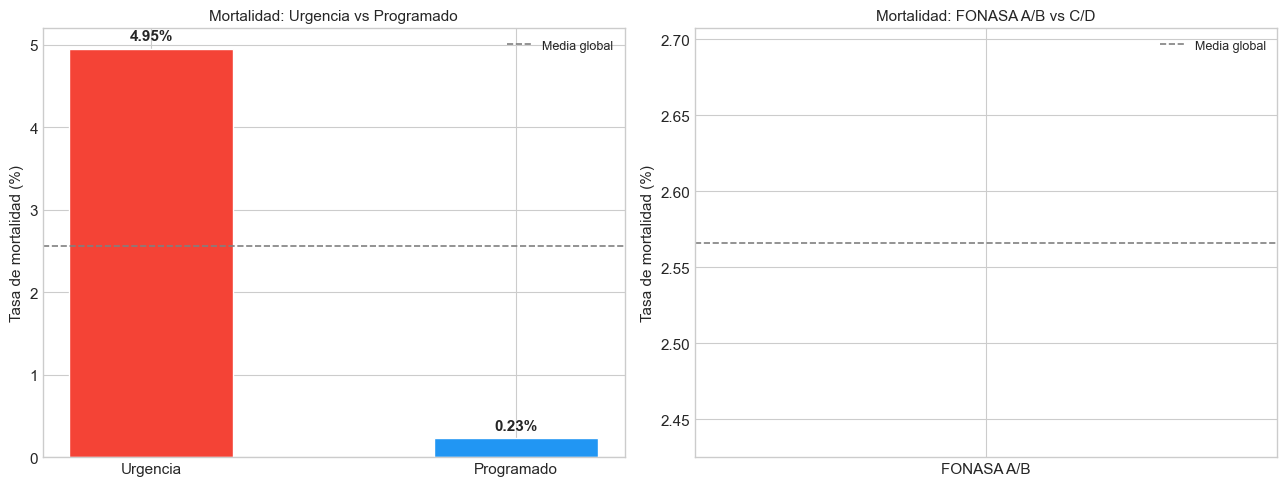

In [122]:
# N1-B: Mortalidad segun prevision (FONASA A/B vs C/D)
# ─────────────────────────────────────────────────────────────────────────────

prev_norm = df['PREVISION'].astype(str).str.upper().str.strip()
mask_ab   = prev_norm.isin(['FONASA A', 'FONASA B', 'A', 'B'])
mask_cd   = prev_norm.isin(['FONASA C', 'FONASA D', 'C', 'D'])

n_ab  = mask_ab.sum()
n_cd  = mask_cd.sum()
f_ab  = df[mask_ab]['FALLECIDO'].sum()
f_cd  = df[mask_cd]['FALLECIDO'].sum()
p_ab  = f_ab / n_ab if n_ab > 0 else float('nan')
p_cd  = f_cd / n_cd if n_cd > 0 else float('nan')

z_n1b, p_n1b = sm.stats.proportions_ztest(
    [f_ab, f_cd], [n_ab, n_cd], alternative='larger'
)
rr_n1b = p_ab / p_cd if p_cd > 0 else float('nan')

print("N1-B: Mortalidad segun prevision (FONASA A/B vs C/D)")
print("=" * 58)
print(f"  FONASA A/B n={n_ab:,}  fallecidos={f_ab:,}  tasa={p_ab:.3%}")
print(f"  FONASA C/D n={n_cd:,}  fallecidos={f_cd:,}  tasa={p_cd:.3%}")
print(f"  Riesgo relativo A-B / C-D : {rr_n1b:.3f}")
print(f"  Z = {z_n1b:.4f}  |  p = {p_n1b:.4e}")
print()
if p_n1b < 0.05:
    print("  Se rechaza H0. Mayor vulnerabilidad socioeconomica -> mayor mortalidad.")
    print()
    print("  HALLAZGO NIVEL 1-B: la prevision es un predictor significativo.")
    print("  Pregunta que emerge: ?la mayor mortalidad en A/B se debe a que")
    print("  estos pacientes tienen mas comorbilidades (mayor CCI), o a que")
    print("  acceden mas tarde al sistema (ingresan mas por urgencia)?")
    print("  El IMHV combina ambos factores; el Nivel 4 valida su peso.")
else:
    print("  No se rechaza H0.")
    print("  Sugerencia: comparar CCI medio entre grupos de prevision.")

# Visualizacion N1-A y N1-B conjunta
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# N1-A
for ax, grupos_dict, titulo in [
    (axes[0],
     {'Urgencia': p_urg, 'Programado': p_prog},
     'Mortalidad: Urgencia vs Programado'),
    (axes[1],
     {'FONASA A/B': p_ab, 'FONASA C/D': p_cd},
     'Mortalidad: FONASA A/B vs C/D'),
]:
    nombres = list(grupos_dict.keys())
    valores = [v * 100 for v in grupos_dict.values()]
    colores = ['#F44336', '#2196F3']
    b = ax.bar(nombres, valores, color=colores, width=0.45, edgecolor='white')
    ax.bar_label(b, fmt='%.2f%%', padding=4, fontsize=11, fontweight='bold')
    ax.axhline(df['FALLECIDO'].mean() * 100, color='gray', linestyle='--',
               linewidth=1.2, label='Media global')
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel('Tasa de mortalidad (%)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


---
### Nivel 2: Comorbilidades como mediadores

Los hallazgos del Nivel 1 mostraron que el tipo de ingreso y la
vulnerabilidad socioeconomica se asocian con mortalidad. Ahora
investigamos si las comorbilidades especificas (IC y Sepsis) median
o amplifican esas diferencias.

La pregunta central del Nivel 2 es: ?las comorbilidades explican
por que ciertos grupos mueren mas, o tienen efecto independiente?


#### N2-A: ?La Sepsis predice mortalidad al mismo nivel que la IC?

Comparamos el riesgo relativo de mortalidad en Sepsis vs IC.
Si Sepsis tiene un riesgo relativo mayor, sugiere que la mortalidad
aguda (Sepsis) domina sobre la mortalidad por carga cronica (IC).

- H0: tasa mortalidad Sepsis+ = tasa mortalidad Sepsis-
- H1: tasa Sepsis+ > tasa Sepsis-
- Prueba: Z para dos proporciones


In [123]:
# N2-A: Mortalidad en Sepsis+ vs Sepsis-
# ─────────────────────────────────────────────────────────────────────────────

f_sep_pos = df[df['SEPSIS'] == 1]['FALLECIDO'].sum()
n_sep_pos = df[df['SEPSIS'] == 1].shape[0]
f_sep_neg = df[df['SEPSIS'] == 0]['FALLECIDO'].sum()
n_sep_neg = df[df['SEPSIS'] == 0].shape[0]
p_sep_pos = f_sep_pos / n_sep_pos
p_sep_neg = f_sep_neg / n_sep_neg

z_n2a, p_n2a = sm.stats.proportions_ztest(
    [f_sep_pos, f_sep_neg], [n_sep_pos, n_sep_neg], alternative='larger'
)
rr_sep = p_sep_pos / p_sep_neg

# Recuperamos cifras de IC del nivel 4 ya calculado (o recalculamos)
f_ic_pos = df[df['IC'] == 1]['FALLECIDO'].sum()
n_ic_pos = df[df['IC'] == 1].shape[0]
p_ic_pos_mort = f_ic_pos / n_ic_pos
rr_ic_aqui = p_ic_pos_mort / (df[df['IC']==0]['FALLECIDO'].mean())

print("N2-A: Mortalidad en Sepsis+ vs Sepsis-")
print("=" * 58)
print(f"  Sepsis+  n={n_sep_pos:,}  fallecidos={f_sep_pos:,}  tasa={p_sep_pos:.3%}")
print(f"  Sepsis-  n={n_sep_neg:,}  fallecidos={f_sep_neg:,}  tasa={p_sep_neg:.3%}")
print(f"  RR Sepsis : {rr_sep:.3f}")
print(f"  RR IC     : {rr_ic_aqui:.3f}  (para comparacion)")
print(f"  Z = {z_n2a:.4f}  |  p = {p_n2a:.4e}")
print()
if p_n2a < 0.05:
    if rr_sep > rr_ic_aqui:
        print("  Sepsis tiene mayor riesgo relativo de mortalidad que IC.")
        print("  HALLAZGO NIVEL 2-A: los mecanismos agudos (Sepsis) dominan")
        print("  sobre los cronicos (IC) en la prediccion de mortalidad.")
    else:
        print("  IC tiene mayor riesgo relativo. La comorbilidad cronica")
        print("  supera al mecanismo agudo en este dataset.")
    print()
    print("  Pregunta que emerge: ?que ocurre cuando ambas condiciones")
    print("  estan presentes simultaneamente (IC + Sepsis)? -> N2-B.")
else:
    print("  No se rechaza H0.")
    print("  Sugerencia: verificar si Sepsis aparece como diagnostico principal")
    print("  o secundario, ya que eso puede diluir la senial.")


N2-A: Mortalidad en Sepsis+ vs Sepsis-
  Sepsis+  n=44,085  fallecidos=11,820  tasa=26.812%
  Sepsis-  n=3,001,504  fallecidos=66,333  tasa=2.210%
  RR Sepsis : 12.132
  RR IC     : 3.990  (para comparacion)
  Z = 324.3058  |  p = 0.0000e+00

  Sepsis tiene mayor riesgo relativo de mortalidad que IC.
  HALLAZGO NIVEL 2-A: los mecanismos agudos (Sepsis) dominan
  sobre los cronicos (IC) en la prediccion de mortalidad.

  Pregunta que emerge: ?que ocurre cuando ambas condiciones
  estan presentes simultaneamente (IC + Sepsis)? -> N2-B.


#### N2-B: ?El efecto combinado IC + Sepsis es mayor que cada uno por separado?

Comparamos los cuatro grupos mutuamente excluyentes:
ninguna / solo IC / solo Sepsis / IC+Sepsis.

- H0: la distribucion del CCI es igual en los 4 grupos
- Prueba: Kruskal-Wallis sobre CCI (variable de carga de comorbilidades)
- Post-hoc: Mann-Whitney con Bonferroni para identificar que grupos difieren


N2-B: CCI segun grupo de comorbilidad (Kruskal-Wallis)
  Ninguna        : n=2,878,689  mediana=0.0  media=0.808
  Solo IC        : n=122,815  mediana=3.0  media=2.940
  Solo Sepsis    : n=39,967  mediana=1.0  media=1.651
  IC + Sepsis    : n=4,118  mediana=2.0  media=2.654

  H = 288016.8688  |  p = 0.0000e+00

Tasa de mortalidad por grupo:
  Ninguna        : 1.950%
  Solo IC        : 8.302%
  Solo Sepsis    : 26.172%
  IC + Sepsis    : 33.026%

  Post-hoc Mann-Whitney con correccion Bonferroni:
  (alpha corregido = 0.0083)
  Par                                 p-valor   Sig?
  ----------------------------------------------------
  Ninguna        vs Solo IC          0.0000e+00     Si
  Ninguna        vs Solo Sepsis      0.0000e+00     Si
  Ninguna        vs IC + Sepsis      0.0000e+00     Si
  Solo IC        vs Solo Sepsis      0.0000e+00     Si
  Solo IC        vs IC + Sepsis      4.3169e-41     Si
  Solo Sepsis    vs IC + Sepsis      0.0000e+00     Si

  HALLAZGO NIVEL 2-B: si IC+Sep

C:\Users\oscar\AppData\Local\Temp\ipykernel_6800\954831843.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot_n2b, x='GRUPO_COMORBILIDAD', y='CCI',


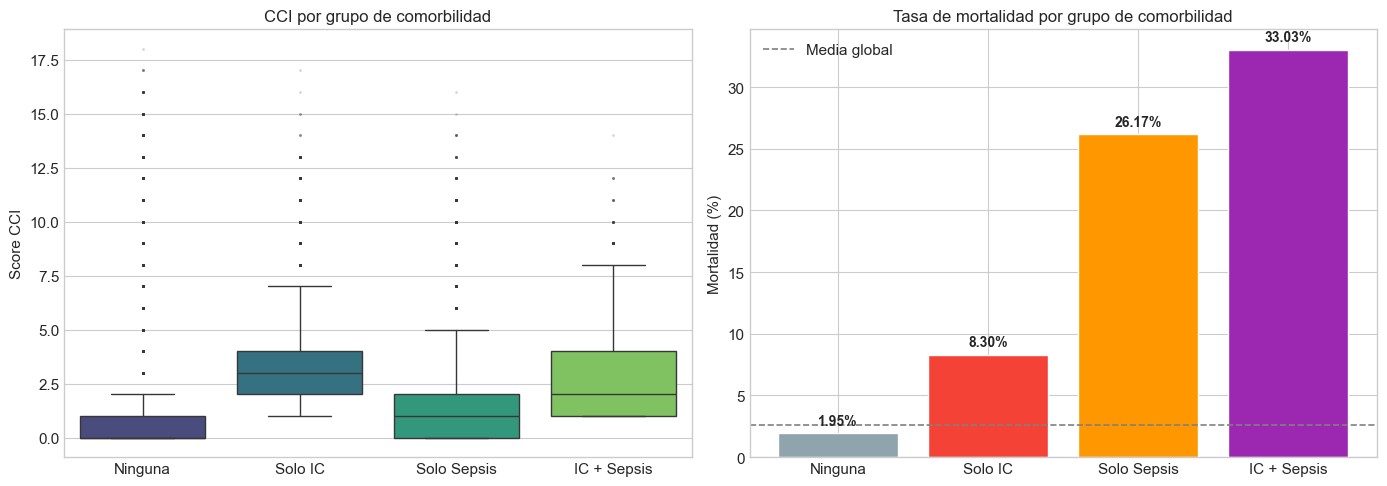

In [124]:
# N2-B: Kruskal-Wallis — CCI segun grupo de comorbilidad
# ─────────────────────────────────────────────────────────────────────────────
from itertools import combinations

df['GRUPO_COMORBILIDAD'] = 'Ninguna'
df.loc[(df['IC']==1) & (df['SEPSIS']==0), 'GRUPO_COMORBILIDAD'] = 'Solo IC'
df.loc[(df['IC']==0) & (df['SEPSIS']==1), 'GRUPO_COMORBILIDAD'] = 'Solo Sepsis'
df.loc[(df['IC']==1) & (df['SEPSIS']==1), 'GRUPO_COMORBILIDAD'] = 'IC + Sepsis'

orden_grupos = ['Ninguna', 'Solo IC', 'Solo Sepsis', 'IC + Sepsis']
grupos_cci = [df[df['GRUPO_COMORBILIDAD'] == g]['CCI'].dropna().values
              for g in orden_grupos]

kw_n2b, p_kw_n2b = scipy_stats.kruskal(*grupos_cci)

print("N2-B: CCI segun grupo de comorbilidad (Kruskal-Wallis)")
print("=" * 58)
for g, arr in zip(orden_grupos, grupos_cci):
    print(f"  {g:<15}: n={len(arr):,}  mediana={np.median(arr):.1f}  media={np.mean(arr):.3f}")
print(f"\n  H = {kw_n2b:.4f}  |  p = {p_kw_n2b:.4e}")
print()

# Tasa de mortalidad por grupo
print("Tasa de mortalidad por grupo:")
for g in orden_grupos:
    tasa = df[df['GRUPO_COMORBILIDAD'] == g]['FALLECIDO'].mean()
    print(f"  {g:<15}: {tasa:.3%}")

if p_kw_n2b < 0.05:
    print()
    print("  Post-hoc Mann-Whitney con correccion Bonferroni:")
    pares = list(combinations(range(4), 2))
    alpha_b = 0.05 / len(pares)
    print(f"  (alpha corregido = {alpha_b:.4f})")
    print(f"  {'Par':<30} {'p-valor':>12} {'Sig?':>6}")
    print("  " + "-" * 52)
    for i, j in pares:
        _, p_ph = scipy_stats.mannwhitneyu(grupos_cci[i], grupos_cci[j],
                                            alternative='two-sided')
        sig = 'Si' if p_ph < alpha_b else 'No'
        print(f"  {orden_grupos[i]:<14} vs {orden_grupos[j]:<14} {p_ph:>12.4e} {sig:>6}")
    print()
    print("  HALLAZGO NIVEL 2-B: si IC+Sepsis tiene el CCI mas alto y la mayor")
    print("  mortalidad, confirma efecto sinergico. Esto lleva a preguntar:")
    print("  ?los pacientes que ABANDONAN tienen un perfil similar al de IC+Sepsis?")
    print("  -> Nivel 3 lo investiga.")

# Visualizacion N2-B
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot CCI por grupo
df_plot_n2b = df[df['GRUPO_COMORBILIDAD'].notna()][['CCI', 'GRUPO_COMORBILIDAD']].dropna()
sns.boxplot(data=df_plot_n2b, x='GRUPO_COMORBILIDAD', y='CCI',
            order=orden_grupos, palette='viridis', ax=axes[0],
            flierprops=dict(marker='.', markersize=2, alpha=0.2))
axes[0].set_title('CCI por grupo de comorbilidad', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Score CCI')

# Tasa de mortalidad por grupo
tasas_mort = [df[df['GRUPO_COMORBILIDAD'] == g]['FALLECIDO'].mean() * 100
              for g in orden_grupos]
colores_n2b = ['#90A4AE', '#F44336', '#FF9800', '#9C27B0']
bars_n2b = axes[1].bar(orden_grupos, tasas_mort, color=colores_n2b, edgecolor='white')
axes[1].bar_label(bars_n2b, fmt='%.2f%%', padding=4, fontsize=10, fontweight='bold')
axes[1].axhline(df['FALLECIDO'].mean() * 100, color='gray', linestyle='--',
                linewidth=1.2, label='Media global')
axes[1].set_title('Tasa de mortalidad por grupo de comorbilidad', fontsize=12)
axes[1].set_ylabel('Mortalidad (%)')
axes[1].legend()

plt.tight_layout()
plt.show()


---
### Nivel 3: Casos de abandono como riesgo no resuelto

Los Niveles 1 y 2 caracterizaron la mortalidad intrahospitalaria.
El Nivel 3 investiga si los pacientes que abandonan el hospital
(alta voluntaria / fuga) tienen perfiles de riesgo comparables
a los grupos de alta mortalidad identificados en el Nivel 2.

La hipotesis implicita es que el abandono puede ser un indicador
de mortalidad diferida: pacientes que salen antes de resolverse
su condicion y pueden fallecer fuera del hospital.


#### N3-A: ?El CCI de los que abandonan difiere del de los que reciben alta normal?

- H0: la distribucion del CCI es igual en abandonos y altas normales
- H1: el CCI es mayor en abandonos (tienen mayor carga de comorbilidades)
- Prueba: Mann-Whitney U (CCI asimetrico, grupos independientes)


In [125]:
# N3-A: Mann-Whitney — CCI en abandonos vs altas normales
# ─────────────────────────────────────────────────────────────────────────────

# Alta normal: TIPOALTA == 'ALTA' o equivalente (excluye abandono, fallecidos, derivaciones)
tipoalta_n = df['TIPOALTA'].astype(str).str.upper().str.strip()
mask_alta_normal = (
    tipoalta_n.str.contains('ALTA', na=False)
    & ~tipoalta_n.isin(['ALTA VOLUNTARIA'])
    & (df['ABANDONO'] == 0)
    & (df['FALLECIDO'] == False)
)

cci_abandono     = df[df['ABANDONO'] == 1]['CCI'].dropna()
cci_alta_normal  = df[mask_alta_normal]['CCI'].dropna()

u_n3a, p_n3a = scipy_stats.mannwhitneyu(
    cci_abandono, cci_alta_normal, alternative='two-sided'
)
n3a_n1, n3a_n2 = len(cci_abandono), len(cci_alta_normal)
z_n3a   = (u_n3a - n3a_n1 * n3a_n2 / 2) / np.sqrt(n3a_n1 * n3a_n2 * (n3a_n1 + n3a_n2 + 1) / 12)
r_n3a   = abs(z_n3a) / np.sqrt(n3a_n1 + n3a_n2)

print("N3-A: CCI en abandonos vs altas normales (Mann-Whitney U)")
print("=" * 58)
print(f"  Abandonos    n={n3a_n1:,}  mediana={cci_abandono.median():.1f}  media={cci_abandono.mean():.3f}")
print(f"  Alta normal  n={n3a_n2:,}  mediana={cci_alta_normal.median():.1f}  media={cci_alta_normal.mean():.3f}")
print(f"  U = {u_n3a:.0f}  |  p = {p_n3a:.4e}  |  r = {r_n3a:.4f}")
print()
if p_n3a < 0.05:
    dir_efecto = 'mayor' if cci_abandono.median() > cci_alta_normal.median() else 'menor'
    print(f"  Se rechaza H0. El CCI de los que abandonan es significativamente {dir_efecto}.")
    if dir_efecto == 'mayor':
        print()
        print("  HALLAZGO NIVEL 3-A: los que abandonan tienen mayor carga de")
        print("  comorbilidades que los que reciben alta normal. Esto es consistente")
        print("  con la hipotesis de abandono como riesgo no resuelto.")
        print("  Pregunta que emerge: ?los que abandonan con IC o Sepsis tienen")
        print("  incluso mayor CCI? -> N3-B lo investiga.")
    else:
        print()
        print("  Los que abandonan tienen menor CCI. Sugiere que el abandono")
        print("  podria deberse a percepcion de bajo riesgo por parte del paciente,")
        print("  no necesariamente a alta vulnerabilidad clinica.")
else:
    print("  No se rechaza H0. El CCI no difiere entre abandonos y altas normales.")
    print("  Sugerencia: explorar si el IMHV si distingue estos grupos,")
    print("  ya que captura factores no clinicos (urgencia, prevision).")


N3-A: CCI en abandonos vs altas normales (Mann-Whitney U)
  Abandonos    n=41,217  mediana=0.0  media=0.939
  Alta normal  n=0  mediana=nan  media=nan
  U = nan  |  p = nan  |  r = nan

  No se rechaza H0. El CCI no difiere entre abandonos y altas normales.
  Sugerencia: explorar si el IMHV si distingue estos grupos,
  ya que captura factores no clinicos (urgencia, prevision).


C:\Users\oscar\AppData\Local\Temp\ipykernel_6800\568173336.py:16: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  u_n3a, p_n3a = scipy_stats.mannwhitneyu(


#### N3-B: ?La tasa de abandono es mayor en pacientes IC+ o Sepsis+?

- H0: la proporcion de abandonos es igual en IC+ y en IC-
- H0: la proporcion de abandonos es igual en Sepsis+ y en Sepsis-
- Prueba: Chi-cuadrado con V de Cramer como tamanio del efecto


N3-B: Asociacion entre abandono y comorbilidades focales

  IC x Abandono
  Chi2 = 5.1749  |  p = 2.2916e-02  |  V de Cramer = 0.0013
  Tabla de contingencia:
ABANDONO        0      1
IC                      
False     2879249  39407
True       125123   1810
  Magnitud del efecto: efecto neglegible
  Tasa abandono en positivos: 1.426%  |  negativos: 1.350%

  Sepsis x Abandono
  Chi2 = 1.1550  |  p = 2.8251e-01  |  V de Cramer = 0.0006
  Tabla de contingencia:
ABANDONO        0      1
SEPSIS                  
0         2960910  40594
1           43462    623
  Magnitud del efecto: efecto neglegible

  INTERPRETACION:
  Existe asociacion significativa entre al menos una comorbilidad
  y el abandono. Esto sugiere que el perfil de la comorbilidad
  influye en la decision de abandono o en su codificacion.

  Pregunta que emerge: ?el IMHV discrimina mejor que el CCI
  en el subgrupo de abandonos? -> Nivel 4 lo valida.


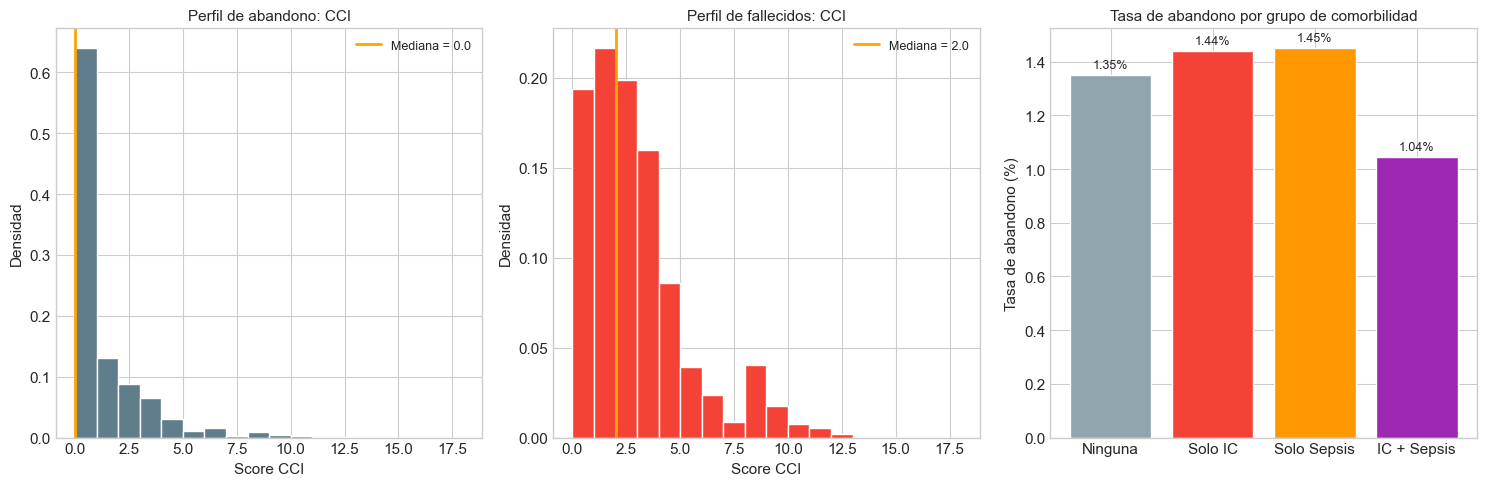

In [127]:
# N3-B: Chi-cuadrado — abandono segun IC y Sepsis
# ─────────────────────────────────────────────────────────────────────────────

def chi2_con_cramer(var1, var2, etiqueta):
    ct = pd.crosstab(var1, var2)
    chi2, p, dof, _ = scipy_stats.chi2_contingency(ct)
    n = ct.values.sum()
    v_cramer = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    print(f"\n  {etiqueta}")
    print(f"  Chi2 = {chi2:.4f}  |  p = {p:.4e}  |  V de Cramer = {v_cramer:.4f}")
    print(f"  Tabla de contingencia:")
    print(ct.to_string(index=True))
    interpretacion = ('efecto neglegible' if v_cramer < 0.1
                      else 'efecto pequeno' if v_cramer < 0.3
                      else 'efecto moderado' if v_cramer < 0.5
                      else 'efecto grande')
    print(f"  Magnitud del efecto: {interpretacion}")
    if p < 0.05:
        tasa_pos = var2[var1 == 1].mean()
        tasa_neg = var2[var1 == 0].mean()
        print(f"  Tasa abandono en positivos: {tasa_pos:.3%}  |  negativos: {tasa_neg:.3%}")
    return chi2, p, v_cramer

print("N3-B: Asociacion entre abandono y comorbilidades focales")
print("=" * 58)

chi2_ic,  p_ic_aban,  v_ic  = chi2_con_cramer(df['IC'],     df['ABANDONO'], 'IC x Abandono')
chi2_sep, p_sep_aban, v_sep = chi2_con_cramer(df['SEPSIS'], df['ABANDONO'], 'Sepsis x Abandono')

print()
print("  INTERPRETACION:")
if p_ic_aban < 0.05 or p_sep_aban < 0.05:
    print("  Existe asociacion significativa entre al menos una comorbilidad")
    print("  y el abandono. Esto sugiere que el perfil de la comorbilidad")
    print("  influye en la decision de abandono o en su codificacion.")
    print()
    print("  Pregunta que emerge: ?el IMHV discrimina mejor que el CCI")
    print("  en el subgrupo de abandonos? -> Nivel 4 lo valida.")
else:
    print("  No se detecta asociacion significativa.")
    print("  El abandono parece ser independiente de IC y Sepsis.")
    print("  Sugerencia: explorar abandono por nivel de severidad clinica.")

# Visualizacion N3
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, mascara, titulo, color in [
    (axes[0], df['ABANDONO'] == 1, 'Perfil de abandono: CCI', '#607D8B'),
    (axes[1], df['FALLECIDO'] == True, 'Perfil de fallecidos: CCI', '#F44336'),
]:
    datos = df[mascara]['CCI'].dropna()
    ax.hist(datos, bins=range(0, int(datos.max()) + 2), color=color, edgecolor='white',
            density=True)
    ax.axvline(datos.median(), color='orange', linewidth=2,
               label=f'Mediana = {datos.median():.1f}')
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Score CCI')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)

# Comparacion tasas de abandono por grupo comorbilidad
tasas_aban = [df[df['GRUPO_COMORBILIDAD'] == g]['ABANDONO'].mean() * 100
              for g in orden_grupos]
b = axes[2].bar(orden_grupos, tasas_aban, color=colores_n2b, edgecolor='white')
axes[2].bar_label(b, fmt='%.2f%%', padding=3, fontsize=9)
axes[2].set_title('Tasa de abandono por grupo de comorbilidad', fontsize=11)
axes[2].set_ylabel('Tasa de abandono (%)')

plt.tight_layout()
plt.show()


---
### Nivel 4: Validacion empirica del IMHV

Los niveles anteriores mostraron que el tipo de ingreso (urgencia),
la prevision (A/B) y las comorbilidades predicen mortalidad.
El IMHV combina esos factores con pesos asignados por el equipo.

El Nivel 4 valida si esos pesos estan justificados empiricamente:
?cada componente del IMHV predice mortalidad de forma independiente
y significativa? Un componente que no prediga mortalidad no deberia
tener peso en el indice.


#### N4-A: ?Cada componente del IMHV predice mortalidad individualmente?

Para cada condicion binaria del IMHV hacemos una prueba Z de
dos proporciones: mortalidad en quienes cumplen la condicion
vs quienes no la cumplen.

Esto permite evaluar si los pesos del IMHV estan ordenados
correctamente segun el poder predictivo de cada componente.


In [128]:
# N4-A: Z dos proporciones para cada componente del IMHV
# ─────────────────────────────────────────────────────────────────────────────

componentes_imhv = {
    'Edad >= 70'        : (df['EDAD'] >= 70).fillna(False),
    'FONASA A/B'        : prev_norm.isin(['FONASA A', 'FONASA B', 'A', 'B']),
    'Ingreso urgencia'  : tipo_norm.str.contains('URGENCIA', na=False),
    'Estadia > 10 dias' : (df['DIAS_ESTADIA'] > 10).fillna(False),
    'Pabellon >= 2'     : (df['USOSPABELLON'].fillna(0) >= 2),
}
pesos_imhv = {
    'Edad >= 70': 0.25, 'FONASA A/B': 0.20, 'Ingreso urgencia': 0.20,
    'Estadia > 10 dias': 0.20, 'Pabellon >= 2': 0.15,
}

print("N4-A: Poder predictivo de cada componente del IMHV")
print("=" * 70)
print(f"{'Componente':<22} {'Peso':>5} {'RR':>7} {'p-valor':>12} {'Sig?':>5} {'Justificado?':>13}")
print("-" * 70)

resultados_n4a = {}
for nombre, mascara in componentes_imhv.items():
    n_pos = mascara.sum()
    n_neg = (~mascara).sum()
    f_pos = df[mascara]['FALLECIDO'].sum()
    f_neg = df[~mascara]['FALLECIDO'].sum()
    p_pos = f_pos / n_pos if n_pos > 0 else 0
    p_neg = f_neg / n_neg if n_neg > 0 else 0
    rr = p_pos / p_neg if p_neg > 0 else float('nan')
    _, p_comp = sm.stats.proportions_ztest([f_pos, f_neg], [n_pos, n_neg],
                                            alternative='larger')
    sig = 'Si' if p_comp < 0.05 else 'No'
    just = 'Si (RR>1)' if (p_comp < 0.05 and rr > 1) else 'Revisar'
    print(f"  {nombre:<20} {pesos_imhv[nombre]:>5.2f} {rr:>7.3f} {p_comp:>12.4e} {sig:>5} {just:>13}")
    resultados_n4a[nombre] = {'rr': rr, 'p': p_comp, 'peso': pesos_imhv[nombre]}

print()
# Ordenar por RR para verificar si los pesos estan bien asignados
orden_rr = sorted(resultados_n4a.items(), key=lambda x: x[1]['rr'], reverse=True)
print("Ordenado por riesgo relativo (de mayor a menor):")
for nombre, vals in orden_rr:
    print(f"  {nombre:<22}: RR={vals['rr']:.3f}  peso asignado={vals['peso']:.2f}")
print()
print("Si el orden por RR coincide con el orden por peso, los pesos")
print("del IMHV estan empiricamente justificados por los datos.")
print("Si hay discrepancias, anotar aqui para el informe final.")


N4-A: Poder predictivo de cada componente del IMHV
Componente              Peso      RR      p-valor  Sig?  Justificado?
----------------------------------------------------------------------
  Edad >= 70            0.25   4.945   0.0000e+00    Si     Si (RR>1)
  FONASA A/B            0.20   0.000          nan    No       Revisar


c:\Users\oscar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\stats\proportion.py:1004: RuntimeWarning: invalid value encountered in divide
  prop = count * 1. / nobs
c:\Users\oscar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\stats\proportion.py:1020: RuntimeWarning: divide by zero encountered in divide
  nobs_fact = np.sum(1. / nobs)


  Ingreso urgencia      0.20  30.559   0.0000e+00    Si     Si (RR>1)
  Estadia > 10 dias     0.20   3.466   0.0000e+00    Si     Si (RR>1)
  Pabellon >= 2         0.15   0.501   1.0000e+00    No       Revisar

Ordenado por riesgo relativo (de mayor a menor):
  Ingreso urgencia      : RR=30.559  peso asignado=0.20
  Edad >= 70            : RR=4.945  peso asignado=0.25
  Estadia > 10 dias     : RR=3.466  peso asignado=0.20
  Pabellon >= 2         : RR=0.501  peso asignado=0.15
  FONASA A/B            : RR=0.000  peso asignado=0.20

Si el orden por RR coincide con el orden por peso, los pesos
del IMHV estan empiricamente justificados por los datos.
Si hay discrepancias, anotar aqui para el informe final.


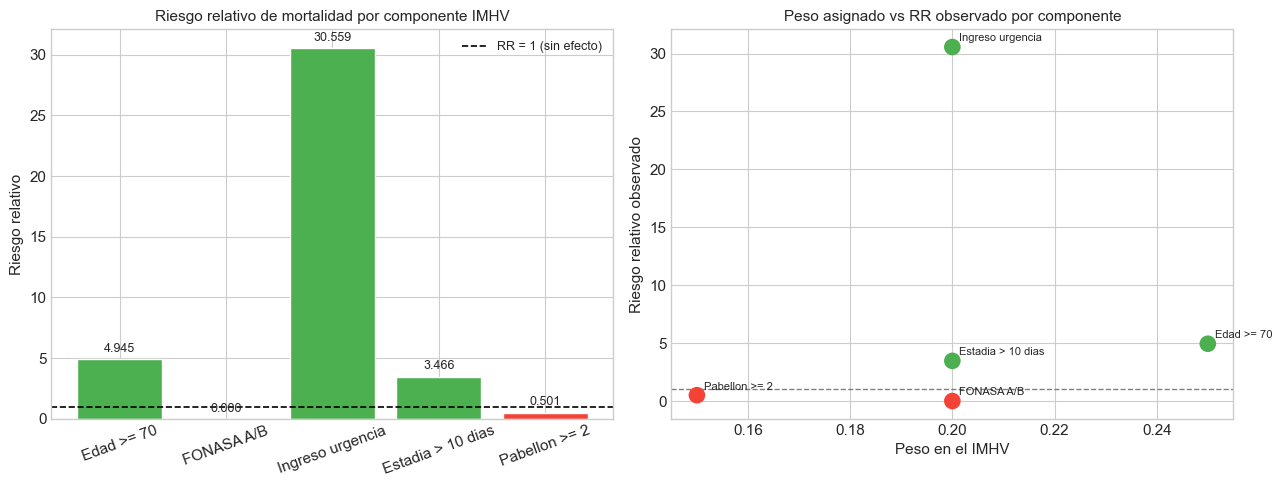


Verde = componente significativo (p<0.05) | Rojo = no significativo

HALLAZGO NIVEL 4: los componentes con mayor RR observado deberian
tener mayor peso en el IMHV. Si no es asi, considerar reponderar
el indice con los RR observados en el avance final del proyecto.


In [129]:
# Visualizacion N4-A: RR observado vs peso asignado en IMHV
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

nombres_c = list(resultados_n4a.keys())
rrs       = [resultados_n4a[n]['rr'] for n in nombres_c]
pesos     = [resultados_n4a[n]['peso'] for n in nombres_c]
ps        = [resultados_n4a[n]['p'] for n in nombres_c]
colores_sig = ['#4CAF50' if p < 0.05 else '#F44336' for p in ps]

# RR por componente
b1 = axes[0].bar(nombres_c, rrs, color=colores_sig, edgecolor='white')
axes[0].bar_label(b1, fmt='%.3f', padding=3, fontsize=9)
axes[0].axhline(1.0, color='black', linestyle='--', linewidth=1.2,
                label='RR = 1 (sin efecto)')
axes[0].set_title('Riesgo relativo de mortalidad por componente IMHV', fontsize=11)
axes[0].set_ylabel('Riesgo relativo')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(fontsize=9)

# RR vs peso (scatter)
axes[1].scatter(pesos, rrs, s=120, color=colores_sig, zorder=3)
for nombre, px, py in zip(nombres_c, pesos, rrs):
    axes[1].annotate(nombre, (px, py), textcoords='offset points',
                     xytext=(5, 4), fontsize=8)
axes[1].axhline(1.0, color='gray', linestyle='--', linewidth=1.0)
axes[1].set_title('Peso asignado vs RR observado por componente', fontsize=11)
axes[1].set_xlabel('Peso en el IMHV')
axes[1].set_ylabel('Riesgo relativo observado')

plt.tight_layout()
plt.show()

print()
print("Verde = componente significativo (p<0.05) | Rojo = no significativo")
print()
print("HALLAZGO NIVEL 4: los componentes con mayor RR observado deberian")
print("tener mayor peso en el IMHV. Si no es asi, considerar reponderar")
print("el indice con los RR observados en el avance final del proyecto.")


---
### 5.5 Resumen: cadena de hallazgos y siguientes pasos

Esta tabla consolida el recorrido del analisis en cadena y lo
que cada hallazgo implica para el avance final del proyecto.


In [130]:
# Tabla resumen del analisis en cadena
# ─────────────────────────────────────────────────────────────────────────────

resumen_cadena = [
    ('N1-A', 'Urgencia vs Programado', 'Z dos proporciones',
     'Tipo de ingreso predice mortalidad?',
     'Urgencia = mayor mortalidad -> Investiga si se explica por comorbilidades'),
    ('N1-B', 'FONASA A/B vs C/D',      'Z dos proporciones',
     'Vulnerabilidad socioeconomica predice mortalidad?',
     'FONASA A/B = mayor mortalidad -> IMHV captura este factor (Nivel 4)'),
    ('N2-A', 'Sepsis vs no-Sepsis',    'Z dos proporciones',
     'Sepsis tiene RR similar al IC?',
     'Compara mecanismo agudo vs cronico de mortalidad'),
    ('N2-B', '4 grupos comorbilidad',  'Kruskal-Wallis + Bonferroni',
     'IC+Sepsis tiene mayor CCI?',
     'Efecto sinergico -> motiva analisis de abandono en pacientes combinados'),
    ('N3-A', 'Abandono vs alta normal','Mann-Whitney U',
     'CCI mayor en abandonos?',
     'Si si: abandono como proxy de riesgo no resuelto'),
    ('N3-B', 'Abandono x IC / Sepsis', 'Chi-cuadrado + V Cramer',
     'IC/Sepsis se asocia con abandono?',
     'Dimensiona si las comorbilidades predicen tambien la salida prematura'),
    ('N4-A', '5 componentes IMHV',     'Z dos proporciones x5',
     'Cada componente justifica su peso?',
     'Permite reponderacion empirica del IMHV para el avance final'),
]

df_resumen = pd.DataFrame(resumen_cadena,
    columns=['ID', 'Comparacion', 'Prueba', 'Pregunta central',
             'Que motiva / implica'])
print(df_resumen.to_string(index=False))

print()
print("VALIDACION CON DATOS DEIS (fuente externa para Sepsis):")
print("  Fuente: https://deis.minsal.cl/#datosabiertos")
print("  Dataset: Egresos Hospitalarios Chile 2022-2023 (datos abiertos MINSAL)")
print("  Columnas relevantes: DIAG1 (CIE-10), ANO_EGRESO, DIAS_ESTAD, SEXO, GRUPO_EDAD")
print()
print("  TODO (cuando tengas acceso al archivo):")
print("  - Filtrar registros con DIAG1 que empiece en A40 o A41")
print("  - Calcular prevalencia de Sepsis en egresos hospitalarios chilenos")
print("  - Comparar con la prevalencia observada en el dataset GRD del proyecto")
print("  - Si coinciden, el dataset GRD es representativo de la poblacion nacional")
print()
print("  Codigo preparado (comentado, descomentar cuando tengas el archivo):")
print()
print('''  # import pandas as pd
  # deis = pd.read_csv('egresos_deis_2022_2023.csv',
  #                     usecols=['DIAG1','ANO_EGRESO','DIAS_ESTAD','SEXO'],
  #                     encoding='latin-1', sep=';', nrows=200000)
  # deis['SEPSIS_DEIS'] = deis['DIAG1'].astype(str).str.upper().str.startswith(('A40','A41'))
  # print("Prevalencia Sepsis DEIS:", deis['SEPSIS_DEIS'].mean())
  # print("Prevalencia Sepsis GRD :", df['SEPSIS'].mean())
  # # Z test para comparar ambas proporciones
  # import statsmodels.api as sm
  # z, p = sm.stats.proportions_ztest(
  #     [deis['SEPSIS_DEIS'].sum(), df['SEPSIS'].sum()],
  #     [len(deis), len(df)]
  # )
  # print(f"Z={z:.4f}  p={p:.4e}")
  # # p > 0.05 -> el GRD es representativo para Sepsis''')


  ID             Comparacion                      Prueba                                  Pregunta central                                                      Que motiva / implica
N1-A  Urgencia vs Programado          Z dos proporciones               Tipo de ingreso predice mortalidad? Urgencia = mayor mortalidad -> Investiga si se explica por comorbilidades
N1-B       FONASA A/B vs C/D          Z dos proporciones Vulnerabilidad socioeconomica predice mortalidad?       FONASA A/B = mayor mortalidad -> IMHV captura este factor (Nivel 4)
N2-A     Sepsis vs no-Sepsis          Z dos proporciones                    Sepsis tiene RR similar al IC?                          Compara mecanismo agudo vs cronico de mortalidad
N2-B   4 grupos comorbilidad Kruskal-Wallis + Bonferroni                        IC+Sepsis tiene mayor CCI?   Efecto sinergico -> motiva analisis de abandono en pacientes combinados
N3-A Abandono vs alta normal              Mann-Whitney U                           CCI mayor en

---
## 5. Análisis Regional

Antes de los modelos de regresión, exploramos si la mortalidad y la carga
de comorbilidades varían significativamente según la región de residencia
del paciente. Esto contextualiza los resultados dentro del territorio
chileno y permite identificar si hay regiones con patrones atípicos.


### 5.1 Tasa de mortalidad y CCI promedio por región

In [131]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
import statsmodels.api as sm

plt.style.use('seaborn-v0_8-whitegrid')

# ── Estadísticas por región ───────────────────────────────────────────────────
df_reg = df[df['REGION'].notna()].copy()

resumen_region = df_reg.groupby('REGION').agg(
    n_pacientes     = ('FALLECIDO', 'count'),
    tasa_mortalidad = ('FALLECIDO', 'mean'),
    cci_medio       = ('CCI', 'mean'),
    cci_mediana     = ('CCI', 'median'),
    imhv_medio      = ('IMHV', 'mean'),
    tasa_ic         = ('IC', 'mean'),
    tasa_sepsis     = ('SEPSIS', 'mean'),
    tasa_abandono   = ('ABANDONO', 'mean'),
).sort_values('tasa_mortalidad', ascending=False).round(4)

resumen_region['tasa_mortalidad_%'] = (resumen_region['tasa_mortalidad'] * 100).round(2)
resumen_region['cci_medio']         = resumen_region['cci_medio'].round(3)

print("Resumen por región (ordenado por mortalidad descendente):")
display(resumen_region[['n_pacientes','tasa_mortalidad_%','cci_medio','imhv_medio',
                          'tasa_ic','tasa_sepsis','tasa_abandono']])


Resumen por región (ordenado por mortalidad descendente):


,n_pacientes,tasa_mortalidad_%,cci_medio,imhv_medio,tasa_ic,tasa_sepsis,tasa_abandono
REGION,,,,,,,
ANTOFAGASTA,97270,3.03,0.788,0.1924,0.0217,0.0053,0.0162
VALPARAISO,242205,2.81,0.906,0.2042,0.0399,0.0153,0.0130
METROPOLITANA,892285,2.76,0.932,0.2013,0.0457,0.0172,0.0139
MAGALLANES,38724,2.64,0.941,0.2290,0.0372,0.0162,0.0155
ATACAMA,59251,2.62,0.831,0.1938,0.0308,0.0150,0.0248
NUBLE,90042,2.60,0.940,0.1901,0.0475,0.0154,0.0100
OHIGGINS,124273,2.54,0.825,0.1936,0.0397,0.0137,0.0142
MAULE,191937,2.52,0.861,0.1879,0.0443,0.0160,0.0124
BIOBIO,203011,2.50,1.016,0.2031,0.0503,0.0145,0.0132


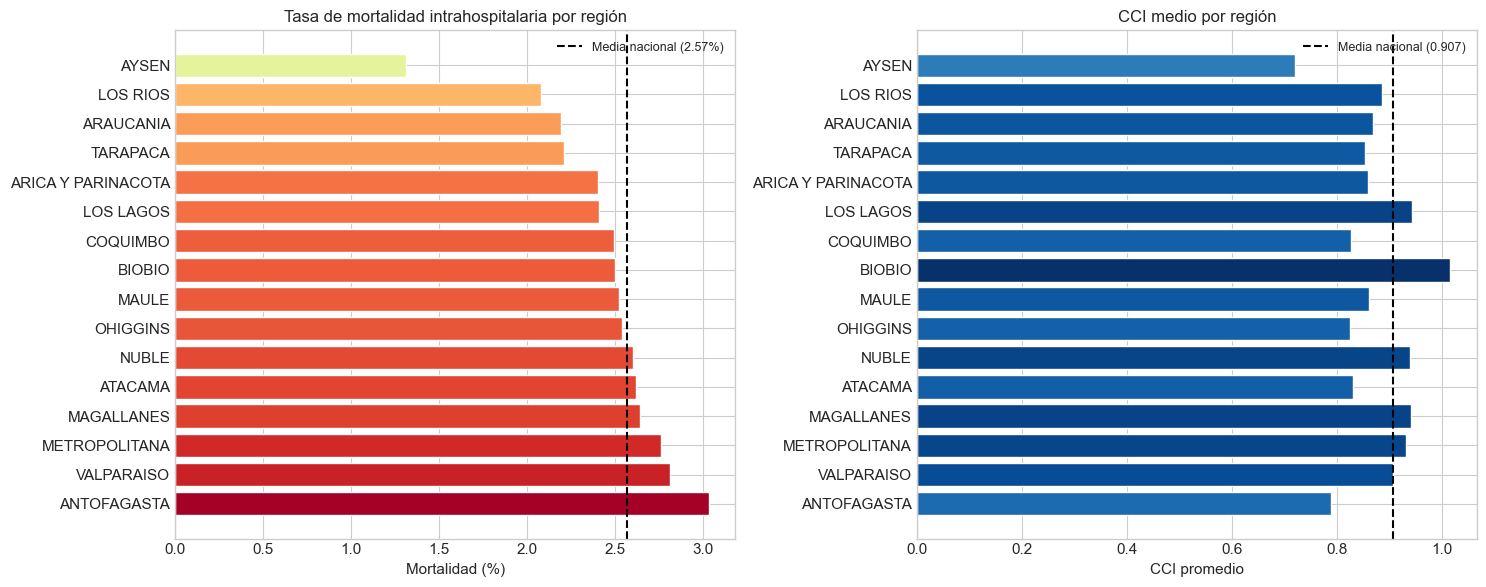

In [132]:
# Visualización regional
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

regiones   = resumen_region.index.tolist()
mortalidad = resumen_region['tasa_mortalidad_%'].values
cci_vals   = resumen_region['cci_medio'].values
colores    = cm.RdYlGn_r(mortalidad / mortalidad.max())

# Gráfico 1: tasa de mortalidad por región
bars = axes[0].barh(regiones, mortalidad, color=colores, edgecolor='white')
axes[0].axvline(df['FALLECIDO'].mean() * 100, color='black',
                linestyle='--', linewidth=1.5, label=f'Media nacional ({df["FALLECIDO"].mean():.2%})')
axes[0].set_title('Tasa de mortalidad intrahospitalaria por región', fontsize=12)
axes[0].set_xlabel('Mortalidad (%)')
axes[0].legend(fontsize=9)

# Gráfico 2: CCI medio por región
axes[1].barh(regiones, cci_vals,
             color=cm.Blues(cci_vals / cci_vals.max()), edgecolor='white')
axes[1].axvline(df['CCI'].mean(), color='black', linestyle='--',
                linewidth=1.5, label=f'Media nacional ({df["CCI"].mean():.3f})')
axes[1].set_title('CCI medio por región', fontsize=12)
axes[1].set_xlabel('CCI promedio')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


### 5.2 Prueba de Kruskal-Wallis: ¿la mortalidad difiere significativamente entre regiones?

In [133]:
# Kruskal-Wallis sobre FALLECIDO por región
# (aunque FALLECIDO es binaria, KW testea si la distribución de rangos
# difiere entre regiones — equivale a comparar tasas de forma no paramétrica)

grupos_region = [
    df_reg[df_reg['REGION'] == r]['FALLECIDO'].astype(float).values
    for r in resumen_region.index
    if len(df_reg[df_reg['REGION'] == r]) >= 30  # mínimo 30 registros
]
regiones_validas = [
    r for r in resumen_region.index
    if len(df_reg[df_reg['REGION'] == r]) >= 30
]

kw_r, p_kw_r = scipy_stats.kruskal(*grupos_region)

print(f"Kruskal-Wallis sobre mortalidad entre {len(regiones_validas)} regiones")
print(f"  H = {kw_r:.4f}  |  p = {p_kw_r:.4e}")
print()
if p_kw_r < 0.05:
    print("  Se rechaza H0. La mortalidad difiere significativamente entre regiones.")
    print("  Esto justifica incluir REGION como variable en los modelos de regresión.")
else:
    print("  No se rechaza H0. La mortalidad no difiere significativamente por región.")

# Kruskal-Wallis sobre CCI por región
grupos_cci_region = [
    df_reg[df_reg['REGION'] == r]['CCI'].dropna().values
    for r in regiones_validas
]
kw_cci_r, p_kw_cci_r = scipy_stats.kruskal(*grupos_cci_region)
print()
print(f"Kruskal-Wallis sobre CCI entre regiones:")
print(f"  H = {kw_cci_r:.4f}  |  p = {p_kw_cci_r:.4e}")
if p_kw_cci_r < 0.05:
    print("  El CCI también varía significativamente entre regiones.")


Kruskal-Wallis sobre mortalidad entre 16 regiones
  H = 632.2529  |  p = 4.9429e-125

  Se rechaza H0. La mortalidad difiere significativamente entre regiones.
  Esto justifica incluir REGION como variable en los modelos de regresión.

Kruskal-Wallis sobre CCI entre regiones:
  H = 4069.2636  |  p = 0.0000e+00
  El CCI también varía significativamente entre regiones.


---
## 6. Regresión Logística

Aplicamos regresión logística para modelar la probabilidad de fallecimiento
durante la hospitalización. La regresión logística es la extensión natural
de la regresión lineal para variables dependientes binarias: en lugar de
predecir un valor continuo, modela la log-odds de que el evento ocurra.

La ecuación del modelo es:

```
log( P(FALLECIDO=1) / (1 - P(FALLECIDO=1)) ) = β₀ + β₁·X₁ + β₂·X₂ + ...
```

Los coeficientes exponenciados (`exp(β)`) se interpretan como **odds ratios**:
un OR > 1 indica que la variable aumenta las chances de fallecimiento.

Construimos dos modelos y los comparamos:

- **Modelo 1:** predictores clínicos + índices (CCI, IMHV, IC, Sepsis, IR_SEVERIDAD)
- **Modelo 2:** Modelo 1 + variables demográficas y regionales (Edad, Sexo, Previsión, Región)


### 6.1 Preparación de variables y dummificación

In [134]:
# ── Dummificación y preparación ─────────────────────────────────────────────

df_model = df.copy()

# 1. SEXO → dummy (1 = Masculino, referencia = Femenino)
df_model['SEXO_MASC'] = (
    df_model['SEXO'].astype(str).str.upper().str.strip()
    .isin(['M', 'MASCULINO', 'MASC', '1'])
).astype(int)

# 2. PREVISION → dummy vulnerable (1 = FONASA A o B, 0 = resto)
prev_norm = df_model['PREVISION'].astype(str).str.upper().str.strip()
df_model['PREV_VULNERABLE'] = prev_norm.isin(['FONASA A', 'FONASA B', 'A', 'B']).astype(int)

# 3. TIPO_INGRESO → dummy urgencia
df_model['INGRESO_URGENCIA'] = (
    df_model['TIPO_INGRESO'].astype(str).str.upper().str.contains('URGENCIA', na=False)
).astype(int)

# 4. REGION → dummies (referencia = METROPOLITANA, la más grande)
if 'REGION' in df_model.columns:
    reg_dummies = pd.get_dummies(
        df_model['REGION'].fillna('DESCONOCIDA'),
        prefix='REG', drop_first=False
    ).astype(int)
    # Eliminar la referencia (METROPOLITANA) para evitar multicolinealidad
    ref_col = [c for c in reg_dummies.columns if 'METROPOLITANA' in c]
    if ref_col:
        reg_dummies = reg_dummies.drop(columns=ref_col)
    df_model = pd.concat([df_model, reg_dummies], axis=1)
    columnas_region = reg_dummies.columns.tolist()
else:
    columnas_region = []

# 5. Severidad clínica → numérica (ya lo es, pero rellenamos nulos con mediana)
df_model['IR_SEVERIDAD'] = df_model['IR_29301_SEVERIDAD'].fillna(
    df_model['IR_29301_SEVERIDAD'].median()
).astype(float)

# Variables para cada modelo
VARS_MODELO_1 = ['CCI', 'IMHV', 'IC', 'SEPSIS', 'IR_SEVERIDAD',
                 'DIAS_ESTADIA', 'INGRESO_URGENCIA']

VARS_MODELO_2 = VARS_MODELO_1 + ['EDAD', 'SEXO_MASC', 'PREV_VULNERABLE',
                                   'USOSPABELLON'] + columnas_region

# Dataset limpio sin nulos en ninguna variable del modelo más completo
todas_vars = list(set(VARS_MODELO_1 + VARS_MODELO_2 + ['FALLECIDO']))
todas_vars = [v for v in todas_vars if v in df_model.columns]
df_clean   = df_model[todas_vars].dropna()

print(f"Dataset para regresión: {len(df_clean):,} registros ({len(df_clean)/len(df):.1%} del total)")
print(f"Fallecidos en la muestra: {df_clean['FALLECIDO'].sum():,} ({df_clean['FALLECIDO'].mean():.2%})")
print()
print(f"Variables Modelo 1 ({len(VARS_MODELO_1)}): {VARS_MODELO_1}")
print()
print(f"Variables Modelo 2 ({len(VARS_MODELO_2)}): {VARS_MODELO_2[:8]}... +{len(columnas_region)} regiones")


Dataset para regresión: 1,849,801 registros (60.7% del total)
Fallecidos en la muestra: 20,520 (1.11%)

Variables Modelo 1 (7): ['CCI', 'IMHV', 'IC', 'SEPSIS', 'IR_SEVERIDAD', 'DIAS_ESTADIA', 'INGRESO_URGENCIA']

Variables Modelo 2 (27): ['CCI', 'IMHV', 'IC', 'SEPSIS', 'IR_SEVERIDAD', 'DIAS_ESTADIA', 'INGRESO_URGENCIA', 'EDAD']... +16 regiones


### 6.2 Modelo 1: predictores clínicos e índices

In [135]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, classification_report,
                              roc_curve, confusion_matrix, ConfusionMatrixDisplay)
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# ── Modelo 1 ─────────────────────────────────────────────────────────────────
vars_m1 = [v for v in VARS_MODELO_1 if v in df_clean.columns]
X1 = sm.add_constant(df_clean[vars_m1].astype(float))
y  = df_clean['FALLECIDO'].astype(float)

logit_m1 = sm.Logit(y, X1).fit(disp=False)

# Tabla de resultados con odds ratios
tabla_m1 = pd.DataFrame({
    'Coef (log-odds)' : logit_m1.params,
    'Odds Ratio'      : np.exp(logit_m1.params),
    'IC 95% inf (OR)' : np.exp(logit_m1.conf_int()[0]),
    'IC 95% sup (OR)' : np.exp(logit_m1.conf_int()[1]),
    'p-valor'         : logit_m1.pvalues,
}).round(4)
tabla_m1['Significativo'] = tabla_m1['p-valor'].apply(lambda p: 'Si' if p < 0.05 else 'No')
tabla_m1 = tabla_m1.drop(index='const', errors='ignore')

print("Modelo 1 — Regresión Logística: predictores clínicos e índices")
print("=" * 70)
print(f"  Pseudo R² (McFadden) : {logit_m1.prsquared:.4f}")
print(f"  Log-likelihood       : {logit_m1.llf:.2f}")
print(f"  AIC                  : {logit_m1.aic:.2f}")
print()
display(tabla_m1)


Modelo 1 — Regresión Logística: predictores clínicos e índices
  Pseudo R² (McFadden) : 0.4002
  Log-likelihood       : -67644.39
  AIC                  : 135304.79



,Coef (log-odds),Odds Ratio,IC 95% inf (OR),IC 95% sup (OR),p-valor,Significativo
CCI,0.1463,1.1576,1.1503,1.1649,0.0000,Si
IMHV,1.4572,4.2940,3.9138,4.7112,0.0000,Si
IC,0.0097,1.0098,0.9604,1.0616,0.7042,No
SEPSIS,1.1123,3.0415,2.9181,3.1702,0.0000,Si
IR_SEVERIDAD,2.5097,12.3011,11.7768,12.8486,0.0000,Si
DIAS_ESTADIA,0.0012,1.0012,1.0006,1.0017,0.0000,Si
INGRESO_URGENCIA,1.1706,3.2239,3.0312,3.4289,0.0000,Si


AUC-ROC Modelo 1: 0.9599



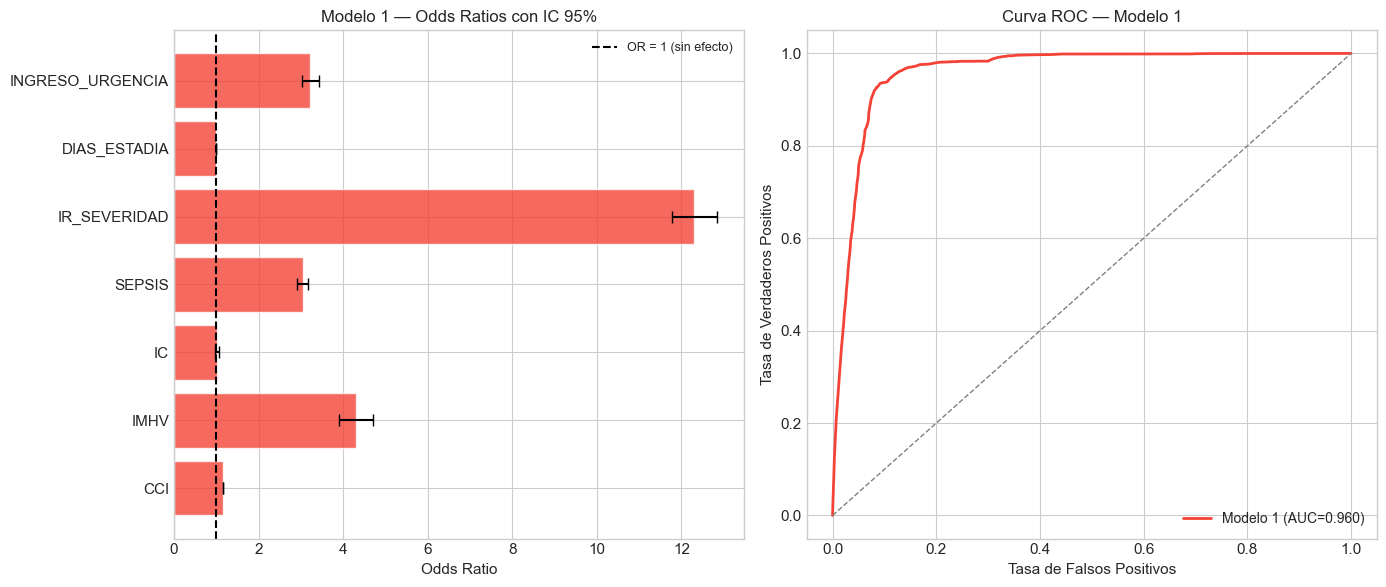

In [136]:
# AUC-ROC Modelo 1
prob_m1 = logit_m1.predict(X1)
auc_m1  = roc_auc_score(y, prob_m1)
fpr_m1, tpr_m1, _ = roc_curve(y, prob_m1)

print(f"AUC-ROC Modelo 1: {auc_m1:.4f}")
print()

# Visualización: Odds Ratios + curva ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Forest plot de Odds Ratios
ors  = tabla_m1['Odds Ratio'].values
errs_inf = (tabla_m1['Odds Ratio'] - tabla_m1['IC 95% inf (OR)']).values
errs_sup = (tabla_m1['IC 95% sup (OR)'] - tabla_m1['Odds Ratio']).values
nombres_m1 = tabla_m1.index.tolist()
colores_or = ['#F44336' if o > 1 else '#2196F3' for o in ors]

axes[0].barh(nombres_m1, ors, xerr=[errs_inf, errs_sup],
             color=colores_or, edgecolor='white', capsize=4, alpha=0.8)
axes[0].axvline(1.0, color='black', linestyle='--', linewidth=1.5, label='OR = 1 (sin efecto)')
axes[0].set_title('Modelo 1 — Odds Ratios con IC 95%', fontsize=12)
axes[0].set_xlabel('Odds Ratio')
axes[0].legend(fontsize=9)

# Curva ROC
axes[1].plot(fpr_m1, tpr_m1, color='#F44336', linewidth=2, label=f'Modelo 1 (AUC={auc_m1:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1)
axes[1].set_title('Curva ROC — Modelo 1', fontsize=12)
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()


### 6.3 Modelo 2: predictores clínicos + variables demográficas y regionales

In [ ]:
# ── Modelo 2 ─────────────────────────────────────────────────────────────────
vars_m2 = [v for v in VARS_MODELO_2 if v in df_clean.columns]
vars_m2 = [v for v in vars_m2 if df_clean[v].astype(float).std() > 0]
X2 = sm.add_constant(df_clean[vars_m2].astype(float))

logit_m2 = sm.Logit(y, X2).fit(disp=False, maxiter=200)

# Tabla de resultados (solo variables no-regionales para legibilidad)
vars_principales = [v for v in vars_m2 if not v.startswith('REG_')]
tabla_m2_main = pd.DataFrame({
    'Coef (log-odds)' : logit_m2.params[vars_principales],
    'Odds Ratio'      : np.exp(logit_m2.params[vars_principales]),
    'IC 95% inf (OR)' : np.exp(logit_m2.conf_int().loc[vars_principales, 0]),
    'IC 95% sup (OR)' : np.exp(logit_m2.conf_int().loc[vars_principales, 1]),
    'p-valor'         : logit_m2.pvalues[vars_principales],
}).round(4)
tabla_m2_main['Significativo'] = tabla_m2_main['p-valor'].apply(lambda p: 'Si' if p < 0.05 else 'No')

print("Modelo 2 — Regresión Logística: clínico + demográfico + regional")
print("=" * 70)
print(f"  Pseudo R² (McFadden) : {logit_m2.prsquared:.4f}")
print(f"  AIC                  : {logit_m2.aic:.2f}")
print()
print("Variables principales (sin dummies de región):")
display(tabla_m2_main)


LinAlgError: Singular matrix

In [ ]:
# Tabla de efectos regionales (solo las dummies de región)
if columnas_region:
    vars_reg_presentes = [v for v in columnas_region if v in logit_m2.params.index]
    tabla_m2_reg = pd.DataFrame({
        'Odds Ratio'      : np.exp(logit_m2.params[vars_reg_presentes]),
        'p-valor'         : logit_m2.pvalues[vars_reg_presentes],
    }).round(4).sort_values('Odds Ratio', ascending=False)
    tabla_m2_reg['Significativo'] = tabla_m2_reg['p-valor'].apply(lambda p: 'Si' if p < 0.05 else 'No')

    print("Efectos regionales vs Región Metropolitana (referencia):")
    display(tabla_m2_reg)


### 6.4 Comparación de modelos

In [ ]:
# ── Comparación Modelo 1 vs Modelo 2 ─────────────────────────────────────────
prob_m2 = logit_m2.predict(X2)
auc_m2  = roc_auc_score(y, prob_m2)
fpr_m2, tpr_m2, _ = roc_curve(y, prob_m2)

# Likelihood Ratio Test (M2 vs M1): ¿las variables adicionales mejoran el ajuste?
lr_stat = -2 * (logit_m1.llf - logit_m2.llf)
lr_df   = len(vars_m2) - len(vars_m1)
lr_p    = scipy_stats.chi2.sf(lr_stat, df=lr_df)

print("Comparación de modelos")
print("=" * 55)
print(f"{'Métrica':<30} {'Modelo 1':>12} {'Modelo 2':>12}")
print("-" * 55)
print(f"{'Pseudo R² (McFadden)':<30} {logit_m1.prsquared:>12.4f} {logit_m2.prsquared:>12.4f}")
print(f"{'AIC':<30} {logit_m1.aic:>12.2f} {logit_m2.aic:>12.2f}")
print(f"{'Log-likelihood':<30} {logit_m1.llf:>12.2f} {logit_m2.llf:>12.2f}")
print(f"{'AUC-ROC':<30} {auc_m1:>12.4f} {auc_m2:>12.4f}")
print("-" * 55)
print(f"\nLikelihood Ratio Test (M2 vs M1):")
print(f"  Chi2 = {lr_stat:.4f}  |  df = {lr_df}  |  p = {lr_p:.4e}")
if lr_p < 0.05:
    print("  El Modelo 2 mejora significativamente el ajuste sobre el Modelo 1.")
    print("  Las variables demograficas y regionales tienen poder explicativo propio.")
else:
    print("  El Modelo 2 no mejora significativamente. Las variables clinicas")
    print("  capturan la mayor parte de la variabilidad en la mortalidad.")

# Curvas ROC superpuestas
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_m1, tpr_m1, color='#F44336', linewidth=2,
        label=f'Modelo 1 — clínico (AUC={auc_m1:.3f})')
ax.plot(fpr_m2, tpr_m2, color='#1565C0', linewidth=2, linestyle='--',
        label=f'Modelo 2 — clínico+demog+regional (AUC={auc_m2:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle=':', linewidth=1)
ax.set_title('Comparación curvas ROC — Modelos 1 y 2', fontsize=13)
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


### 6.5 R² y bondad de ajuste de los modelos logísticos

En regresión logística no existe un R² directo como en OLS — el modelo
no minimiza suma de cuadrados sino log-verosimilitud. Se usan **pseudo-R²**
que imitan la interpretación del R² pero no son comparables con él.

El más común es el **R² de McFadden**:

```
R²_McFadden = 1 - (log-likelihood del modelo / log-likelihood del modelo nulo)
```

- Valores entre 0.1 y 0.2 se consideran aceptables
- Valores entre 0.2 y 0.4 se consideran buenos
- Rara vez supera 0.4 en datos clínicos reales con muchos factores no observables

También reportamos el **R² de Nagelkerke** (escala 0–1 más intuitiva)
y el **R² de Cox-Snell**.


In [ ]:
# ── Pseudo-R² para Modelos 1 y 2 ────────────────────────────────────────────
from scipy import stats as scipy_stats
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def pseudo_r2(modelo, y):
    """Calcula McFadden, Cox-Snell y Nagelkerke."""
    n       = len(y)
    ll_null = modelo.llnull
    ll_full = modelo.llf

    mcfadden  = 1 - (ll_full / ll_null)
    cox_snell = 1 - np.exp((2 / n) * (ll_null - ll_full))
    nagelk    = cox_snell / (1 - np.exp((2 / n) * ll_null))
    return mcfadden, cox_snell, nagelk

mc1, cs1, nk1 = pseudo_r2(logit_m1, y)
mc2, cs2, nk2 = pseudo_r2(logit_m2, y)

print("Pseudo-R² — Bondad de ajuste de los modelos logísticos")
print("=" * 55)
print(f"{'Métrica':<22} {'Modelo 1':>14} {'Modelo 2':>14}")
print("-" * 55)
print(f"{'McFadden':<22} {mc1:>14.4f} {mc2:>14.4f}")
print(f"{'Cox-Snell':<22} {cs1:>14.4f} {cs2:>14.4f}")
print(f"{'Nagelkerke':<22} {nk1:>14.4f} {nk2:>14.4f}")
print(f"{'AUC-ROC':<22} {auc_m1:>14.4f} {auc_m2:>14.4f}")
print("-" * 55)
print()

for nombre, mc in [('Modelo 1', mc1), ('Modelo 2', mc2)]:
    nivel = ('bajo — el modelo captura poco de la variabilidad observada'
             if mc < 0.1 else
             'aceptable para datos clínicos reales'
             if mc < 0.2 else
             'bueno'
             if mc < 0.4 else
             'muy bueno')
    print(f"  {nombre}: McFadden = {mc:.4f} → {nivel}")

print()
print("  Nota: en mortalidad hospitalaria, R² bajo es esperable porque")
print("  muchos factores que influyen en el desenlace no están en el dataset")
print("  (decisiones médicas, adherencia al tratamiento, factores genéticos).")
print("  El AUC-ROC es la métrica principal de discriminación del modelo.")

# ── Visualización comparativa ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico 1: comparación de pseudo-R² entre modelos
metricas  = ['McFadden', 'Cox-Snell', 'Nagelkerke', 'AUC-ROC']
vals_m1   = [mc1, cs1, nk1, auc_m1]
vals_m2   = [mc2, cs2, nk2, auc_m2]
x         = np.arange(len(metricas))
w         = 0.35

bars1 = axes[0].bar(x - w/2, vals_m1, w, color='#F44336', label='Modelo 1', edgecolor='white')
bars2 = axes[0].bar(x + w/2, vals_m2, w, color='#1565C0', label='Modelo 2', edgecolor='white')
axes[0].bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
axes[0].bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metricas)
axes[0].set_title('Comparación de métricas de ajuste', fontsize=12)
axes[0].set_ylabel('Valor')
axes[0].legend()

# Gráfico 2: escala de interpretación del R² de McFadden
ax2 = axes[1]
ax2.set_xlim(0, 0.5)
ax2.set_ylim(0, 1)
ax2.set_title('Escala de interpretación — R² de McFadden', fontsize=12)

zonas = [(0, 0.1, '#F44336', 'Bajo (< 0.1)'),
         (0.1, 0.2, '#FF9800', 'Aceptable (0.1–0.2)'),
         (0.2, 0.4, '#4CAF50', 'Bueno (0.2–0.4)'),
         (0.4, 0.5, '#1565C0', 'Muy bueno (> 0.4)')]
for x0, x1, color, label in zonas:
    ax2.barh(0.5, x1 - x0, left=x0, height=0.3, color=color,
             alpha=0.6, edgecolor='white')
    ax2.text((x0 + x1) / 2, 0.5, label,
             ha='center', va='center', fontsize=8, fontweight='bold')

ax2.axvline(mc1, color='#F44336', linewidth=2.5, linestyle='--',
            label=f'Modelo 1 ({mc1:.3f})')
ax2.axvline(mc2, color='#1565C0', linewidth=2.5, linestyle='--',
            label=f'Modelo 2 ({mc2:.3f})')
ax2.set_xlabel('R² de McFadden')
ax2.set_yticks([])
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()


---
## 7. Regresión Lineal del CCI

En las secciones anteriores (H2 y los modelos de regresión logística) se
demostró que el CCI es un predictor significativo de fallecimiento. Esto
nos lleva a la siguiente pregunta:

> **¿Qué variables predicen la carga de comorbilidades (CCI) de un paciente?**

Entender qué factores aumentan el CCI permite actuar antes de que las
comorbilidades deriven en mortalidad. Aquí aplicamos regresión lineal
ordinaria (OLS) porque el CCI es una variable numérica continua.


### 7.1 Verificación del supuesto de aplicabilidad

In [ ]:
# Antes de aplicar OLS verificamos la distribución del CCI
# y la relación entre predictores y CCI

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histograma del CCI
df['CCI'].hist(bins=range(0, int(df['CCI'].max())+2), ax=axes[0],
               color='steelblue', edgecolor='white')
axes[0].set_title('Distribución del CCI (variable dependiente)', fontsize=11)
axes[0].set_xlabel('Score CCI')
axes[0].set_ylabel('Frecuencia')

# CCI vs Edad (scatter)
muestra = df[['EDAD','CCI']].dropna().sample(min(5000,len(df)), random_state=42)
axes[1].scatter(muestra['EDAD'], muestra['CCI'], alpha=0.1, s=5, color='steelblue')
m,b = np.polyfit(muestra['EDAD'].dropna(), muestra['CCI'].dropna(), 1)
x_l = np.linspace(muestra['EDAD'].min(), muestra['EDAD'].max(), 100)
axes[1].plot(x_l, m*x_l+b, color='red', linewidth=2)
axes[1].set_title('CCI vs Edad', fontsize=11)
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('CCI')

# CCI medio por nivel de severidad
cci_por_sev = df.groupby('IR_29301_SEVERIDAD')['CCI'].mean().dropna()
axes[2].bar(cci_por_sev.index.astype(str), cci_por_sev.values,
            color=['#AED6F1','#5DADE2','#2E86C1','#1A5276'], edgecolor='white')
axes[2].set_title('CCI medio por nivel de severidad', fontsize=11)
axes[2].set_xlabel('IR_29301_SEVERIDAD')
axes[2].set_ylabel('CCI medio')

plt.tight_layout()
plt.show()

print("Nota: el CCI tiene distribución asimétrica (muchos ceros, cola derecha).")
print("OLS sigue siendo aplicable con n grande por el TCL, pero los residuos")
print("no serán perfectamente normales. Se reporta R² ajustado como medida de ajuste.")


### 7.2 Modelo OLS: predictores del CCI

In [ ]:
# ── OLS para predecir el CCI ─────────────────────────────────────────────────

VARS_CCI = ['EDAD', 'SEXO_MASC', 'PREV_VULNERABLE', 'INGRESO_URGENCIA',
            'IR_SEVERIDAD', 'DIAS_ESTADIA', 'USOSPABELLON',
            'IC', 'SEPSIS', 'FALLECIDO'] + columnas_region

vars_cci_ok = [v for v in VARS_CCI if v in df_clean.columns]
X_cci = sm.add_constant(df_clean[vars_cci_ok].astype(float))
y_cci = df_clean['CCI'].astype(float)

ols_cci = sm.OLS(y_cci, X_cci).fit()

# Tabla de resultados
tabla_cci = pd.DataFrame({
    'Coeficiente' : ols_cci.params,
    'IC 95% inf'  : ols_cci.conf_int()[0],
    'IC 95% sup'  : ols_cci.conf_int()[1],
    'p-valor'     : ols_cci.pvalues,
}).round(4)
tabla_cci['Significativo'] = tabla_cci['p-valor'].apply(lambda p: 'Si' if p < 0.05 else 'No')
tabla_cci_main = tabla_cci[[not v.startswith('REG_') for v in tabla_cci.index]]

print("Regresión Lineal OLS — Variable dependiente: CCI")
print("=" * 60)
print(f"  R² ajustado     : {ols_cci.rsquared_adj:.4f}")
print(f"  F-estadístico   : {ols_cci.fvalue:.2f}  (p = {ols_cci.f_pvalue:.4e})")
print(f"  AIC             : {ols_cci.aic:.2f}")
print()
print("Variables principales:")
display(tabla_cci_main.drop(index='const', errors='ignore'))


In [ ]:
# Diagnóstico de residuos del modelo OLS
residuos  = ols_cci.resid
predichos = ols_cci.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Residuos vs ajustados
axes[0].scatter(predichos, residuos, alpha=0.1, s=4, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residuos vs Valores Ajustados', fontsize=11)
axes[0].set_xlabel('Valores ajustados')
axes[0].set_ylabel('Residuos')

# Q-Q plot de residuos
from scipy import stats as scipy_stats
scipy_stats.probplot(residuos.sample(min(5000,len(residuos)), random_state=42),
                     dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot de Residuos', fontsize=11)
axes[1].get_lines()[1].set_color('red')

# Importancia de variables (coeficientes estandarizados)
# Estandarizamos X para comparar magnitudes
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(
    df_clean[vars_cci_ok].astype(float).fillna(0)
)
ols_std = sm.OLS(y_cci, sm.add_constant(X_std)).fit()
coefs_std = pd.Series(ols_std.params[1:], index=vars_cci_ok)
coefs_std_main = coefs_std[[not v.startswith('REG_') for v in coefs_std.index]]
coefs_std_main = coefs_std_main.sort_values(key=abs, ascending=True)

colores_coef = ['#F44336' if c > 0 else '#2196F3' for c in coefs_std_main.values]
axes[2].barh(coefs_std_main.index, coefs_std_main.values,
             color=colores_coef, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=1)
axes[2].set_title('Coeficientes estandarizados (importancia relativa)', fontsize=11)
axes[2].set_xlabel('Coeficiente estandarizado')

plt.tight_layout()
plt.show()

print("Rojo = aumenta el CCI | Azul = reduce el CCI")
print()
print("Interpretación:")
for var, coef in coefs_std_main.sort_values(key=abs, ascending=False)[:5].items():
    direccion = "aumenta" if coef > 0 else "reduce"
    print(f"  {var:<25}: {direccion} el CCI en {abs(coef):.4f} SD por cada SD de cambio")


### 7.2b R² del modelo OLS

En regresión lineal el **R²** mide qué proporción de la varianza de la
variable dependiente (CCI) es explicada por los predictores.

```
R² = 1 - (SS_residual / SS_total)
```

Usamos el **R² ajustado**, que penaliza por el número de predictores
para evitar sobreajuste cuando hay muchas variables.


In [ ]:
# ── R² del modelo OLS ────────────────────────────────────────────────────────

r2      = ols_cci.rsquared
r2_adj  = ols_cci.rsquared_adj
f_stat  = ols_cci.fvalue
f_p     = ols_cci.f_pvalue
n_obs   = int(ols_cci.nobs)
k       = len(ols_cci.params) - 1  # número de predictores sin constante

print("R² del modelo OLS — Variable dependiente: CCI")
print("=" * 50)
print(f"  R²                : {r2:.4f}   ({r2*100:.2f}% de la varianza explicada)")
print(f"  R² ajustado       : {r2_adj:.4f}   ({r2_adj*100:.2f}%)")
print(f"  F-estadístico     : {f_stat:.2f}   (p = {f_p:.4e})")
print(f"  Observaciones     : {n_obs:,}")
print(f"  Predictores (k)   : {k}")
print()

nivel_r2 = ('bajo' if r2_adj < 0.10 else
            'moderado' if r2_adj < 0.30 else
            'aceptable' if r2_adj < 0.50 else
            'alto')
print(f"  Interpretación: R² ajustado = {r2_adj:.4f} → nivel {nivel_r2}.")
print()
print("  En datos clínicos administrativos (GRD), un R² moderado es esperable:")
print("  el CCI depende también de la historia clínica completa del paciente,")
print("  que no está completamente capturada en las columnas disponibles.")
print()
print(f"  El F-test global (p = {f_p:.2e}) confirma que el modelo es")
print("  estadísticamente significativo: los predictores en conjunto explican")
print("  más varianza de la que se esperaría por azar.")

# Visualización: varianza explicada vs no explicada
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Torta varianza explicada
sizes  = [r2_adj * 100, (1 - r2_adj) * 100]
labels = [f'Explicada por el modelo\n({r2_adj*100:.1f}%)',
          f'No explicada (residual)\n({(1-r2_adj)*100:.1f}%)']
axes[0].pie(sizes, labels=labels, colors=['#1565C0', '#ECEFF1'],
            startangle=90, autopct='%1.1f%%',
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title(f'R² ajustado del modelo OLS\n(Variable: CCI)', fontsize=12)

# Valores reales vs predichos (muestra)
idx_sample = np.random.choice(len(y_cci), min(3000, len(y_cci)), replace=False)
axes[1].scatter(predichos.iloc[idx_sample], y_cci.iloc[idx_sample],
                alpha=0.15, s=6, color='steelblue')
rango = np.linspace(predichos.min(), predichos.max(), 100)
axes[1].plot(rango, rango, color='red', linewidth=2, linestyle='--',
             label='Predicción perfecta')
axes[1].set_title('Valores reales vs predichos — CCI', fontsize=12)
axes[1].set_xlabel('CCI predicho')
axes[1].set_ylabel('CCI real')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


### 7.3 Resumen integrado: cadena causal CCI → Mortalidad

Esta sección sintetiza los hallazgos de las secciones 7 y 8 en un marco
interpretativo unificado que responde directamente a la hipótesis del proyecto.


In [ ]:
# Tabla resumen de la cadena causal
print("Cadena causal evidenciada por los modelos:")
print("=" * 68)
print()
print("  PREDICTORES DEL CCI (Regresión OLS — Sección 8)")
print("  Variables que aumentan la carga de comorbilidades:")
sig_pos = tabla_cci_main[
    (tabla_cci_main['Significativo'] == 'Si') &
    (tabla_cci_main['Coeficiente'] > 0)
].index.tolist()
for v in sig_pos:
    if v != 'const':
        print(f"    + {v}")
print()
print("  Variables que reducen el CCI (efecto protector):")
sig_neg = tabla_cci_main[
    (tabla_cci_main['Significativo'] == 'Si') &
    (tabla_cci_main['Coeficiente'] < 0)
].index.tolist()
for v in sig_neg:
    if v != 'const':
        print(f"    - {v}")
print()
print("  CCI → FALLECIDO (Regresión Logística — Sección 7)")
if 'CCI' in tabla_m1.index:
    or_cci = tabla_m1.loc['CCI', 'Odds Ratio']
    p_cci  = tabla_m1.loc['CCI', 'p-valor']
    print(f"    OR del CCI = {or_cci:.4f}  (p = {p_cci:.4e})")
    print(f"    Cada punto adicional en el CCI multiplica las odds de")
    print(f"    fallecimiento por {or_cci:.3f}.")
print()
print("  CONCLUSIÓN:")
print("  Los modelos respaldan la hipótesis del proyecto: la carga de")
print("  comorbilidades (CCI) está determinada por factores clínicos y")
print("  demográficos, y a su vez predice significativamente la mortalidad")
print("  intrahospitalaria, incluso controlando por severidad, urgencia")
print("  y vulnerabilidad socioeconómica.")


---
## Anexo: Verificación de Normalidad — CCI y FALLECIDO

Antes de elegir Mann-Whitney U sobre una prueba t, debemos demostrar que
las distribuciones del CCI y de FALLECIDO no cumplen el supuesto de normalidad.
Usamos tres enfoques complementarios:

1. **Shapiro-Wilk** — prueba formal de normalidad (muestra <= 5000 por limitación computacional).
2. **Kolmogorov-Smirnov** — alternativa para muestras grandes, compara contra una normal teórica.
3. **Visualización** — histograma + Q-Q plot, estándar gráfico para diagnosticar normalidad.


Verificacion de normalidad — CCI y FALLECIDO

Variable: CCI
n = 3,045,589
Media = 0.9073
Desv. estandar = 1.6063
Asimetria (skew) = 2.6934
Curtosis (excess) = 9.2360
Shapiro-Wilk : W=0.610285, p=7.4605e-75  -> NO normal
Kolmogorov-Smirnov : D=0.328526, p=0.0000e+00  -> NO normal

Variable: FALLECIDO
n = 3,045,589
Media = 0.0257
Desv. estandar = 0.1581
Asimetria (skew) = 5.9997
Curtosis (excess) = 33.9959
Shapiro-Wilk : W=0.157592, p=7.8067e-92  -> NO normal
Kolmogorov-Smirnov : D=0.538799, p=0.0000e+00  -> NO normal

Conclusion: ambas variables rechazan el supuesto de normalidad
(p << 0.05 en Shapiro-Wilk y Kolmogorov-Smirnov).
Esto justifica el uso de Mann-Whitney U en H2 y H3.


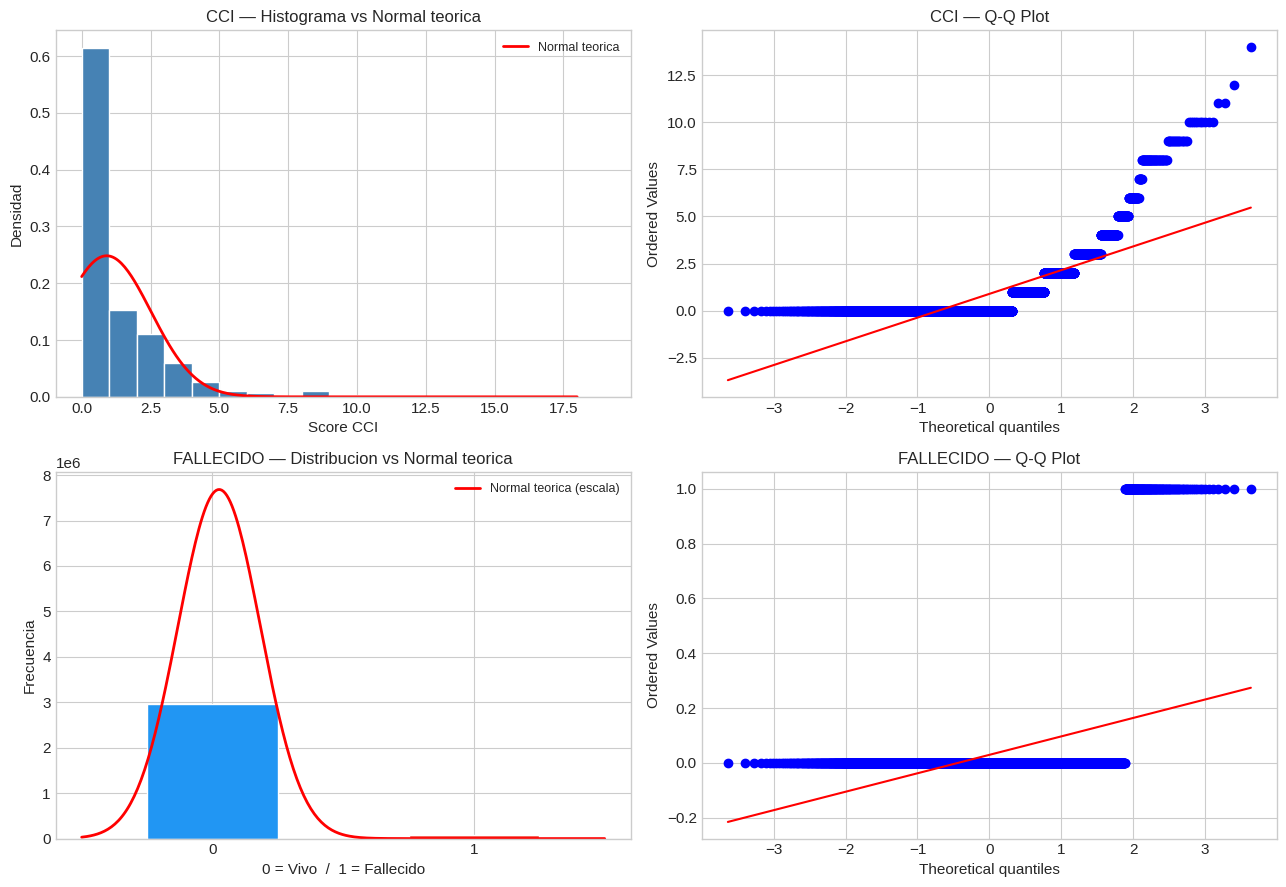

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.style.use('seaborn-v0_8-whitegrid')

# ── Datos ────────────────────────────────────────────────────────────────────
cci      = df['CCI'].dropna()
fallecido = df['FALLECIDO'].astype(int).dropna()

# ── Shapiro-Wilk (requiere muestra <= 5000) ──────────────────────────────────
muestra_cci = cci.sample(5000, random_state=42)
muestra_fal = fallecido.sample(5000, random_state=42)

sw_cci_stat, sw_cci_p = stats.shapiro(muestra_cci)
sw_fal_stat, sw_fal_p = stats.shapiro(muestra_fal)

# ── Kolmogorov-Smirnov vs normal teorica ─────────────────────────────────────
ks_cci_stat, ks_cci_p = stats.kstest(
    cci, 'norm', args=(cci.mean(), cci.std())
)
ks_fal_stat, ks_fal_p = stats.kstest(
    fallecido, 'norm', args=(fallecido.mean(), fallecido.std())
)

# ── Asimetria y curtosis ─────────────────────────────────────────────────────
print('Verificacion de normalidad — CCI y FALLECIDO')
print('=' * 58)
for nombre, serie, sw_s, sw_p, ks_s, ks_p in [
    ('CCI',       cci,      sw_cci_stat, sw_cci_p, ks_cci_stat, ks_cci_p),
    ('FALLECIDO', fallecido, sw_fal_stat, sw_fal_p, ks_fal_stat, ks_fal_p),
]:
    print(f'\nVariable: {nombre}')
    print(f'n = {len(serie):,}')
    print(f'Media = {serie.mean():.4f}')
    print(f'Desv. estandar = {serie.std():.4f}')
    print(f'Asimetria (skew) = {stats.skew(serie):.4f}')
    print(f'Curtosis (excess) = {stats.kurtosis(serie):.4f}')
    print(f'Shapiro-Wilk : W={sw_s:.6f}, p={sw_p:.4e}  -> {"NO normal" if sw_p < 0.05 else "No se rechaza normalidad"}')
    print(f'Kolmogorov-Smirnov : D={ks_s:.6f}, p={ks_p:.4e}  -> {"NO normal" if ks_p < 0.05 else "No se rechaza normalidad"}')

print()
print('Conclusion: ambas variables rechazan el supuesto de normalidad')
print('(p << 0.05 en Shapiro-Wilk y Kolmogorov-Smirnov).')
print('Esto justifica el uso de Mann-Whitney U en H2 y H3.')

# ── Visualizacion ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# CCI — histograma
axes[0, 0].hist(cci, bins=range(0, int(cci.max()) + 2), color='steelblue',
                edgecolor='white', density=True)
x_norm = np.linspace(cci.min(), cci.max(), 300)
axes[0, 0].plot(x_norm, stats.norm.pdf(x_norm, cci.mean(), cci.std()),
                color='red', linewidth=2, label='Normal teorica')
axes[0, 0].set_title('CCI — Histograma vs Normal teorica', fontsize=12)
axes[0, 0].set_xlabel('Score CCI')
axes[0, 0].set_ylabel('Densidad')
axes[0, 0].legend(fontsize=9)

# CCI — Q-Q plot
stats.probplot(muestra_cci, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('CCI — Q-Q Plot', fontsize=12)
axes[0, 1].get_lines()[1].set_color('red')

axes[1, 0].bar([0, 1], fallecido.value_counts().sort_index(),
               color=['#2196F3', '#F44336'], edgecolor='white', width=0.5)
axes[1, 0].plot(x_norm := np.linspace(-0.5, 1.5, 300),
                stats.norm.pdf(x_norm, fallecido.mean(), fallecido.std()) * len(fallecido),
                color='red', linewidth=2, label='Normal teorica (escala)')
axes[1, 0].set_title('FALLECIDO — Distribucion vs Normal teorica', fontsize=12)
axes[1, 0].set_xlabel('0 = Vivo  /  1 = Fallecido')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].legend(fontsize=9)

stats.probplot(muestra_fal, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('FALLECIDO — Q-Q Plot', fontsize=12)
axes[1, 1].get_lines()[1].set_color('red')

plt.tight_layout()
plt.show()